# Modélisation de la fonction de masse des amas
On implémente ici plusieurs versions de la fonction de masse des amas $\frac{dn}{dM}(z)$ ($Mpc^{-3} dex^{-1}$), c'est à dire la densité volumique d'amas de galaxies de masse comprises dans l'intervalle $[M - dM ; M + dM]$ pour un certain redshift z. 

## Intro

In [1]:
# Import setup script first
#import setup_colossus

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import importlib
from scipy.interpolate import UnivariateSpline
from scipy import integrate

In [3]:
#Set colossus data directory to avoid network drive issues
#os.environ['COLOSSUS_DATA_DIR'] = r'C:\Users\ED282972\AppData\Local\colossus'

In [4]:
import halo_and_cluster_MF as hcmf
import useful_functions as uf

In [5]:
# Permet de recharger le module hcmf et uf
importlib.reload(hcmf) ; importlib.reload(uf) 

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

In [6]:
# Set the style for the plots
plt.rcParams.update({
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20
})

In [7]:
cosmo = Planck18

In [8]:
colors = ["blue", "cyan", "green", "darkorange", "orangered","lightcoral"]
cmap_blue2red = LinearSegmentedColormap.from_list("blue2red", colors)

# Fonction de masse "théorique"

In [9]:
log10_M_Msun = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres pour Murray, Robotham and Power (MRP) sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
M_Msun = 10**log10_M_Msun
log10_M_Msun = log10_M_Msun.tolist()

## Bocquet et al. 2016

In [10]:
# CMF théorique Bocquet et al. 2016
z_Bocquet2016 = 0.1  # Redshift
CMF_Bocquet2016 = hcmf.CMF_Bocquet_2016(10**np.array(log10_M_Msun),z_Bocquet2016)
# Pour la suite tester avec plus de z !!!

## Murray, Robotham and Power 
Voir Murray, Robotham, Power 2013 / Murray et al. 2021 / Driver et al. 2022

Les valeurs suivantes et définitions de fonction de masse des amas (CMF) sont tirées de Driver et al. 2022.

!!! PROBLEME : Les coefficients de cette CMF cont calibrées à partir de M200c !!!

Autre problème : les coefficients ne sont définis qu'uniquement pour z = 0.1 (et aussi z = 0)

### Implémentation

In [11]:
# On prend différents quelques lots de paramètres issus de Driver et al .2021 (on prend ceux issus d'un fit sur plusieurs relevés)
# Les paramètres sont de la forme : (log10_Mmedian_Msun,log10_phimedian,alpha,beta)

# Params GSR (GAMA5 + SDSS5 + REFLEX II) : ce sont les paramètres finalament retenus dans Driver et al. 2021
params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes 
bounds_params_GSR = [(14.13-0.40,14.13+0.43),(-3.96-0.82,-3.96+0.55),(-1.68-0.24,-1.68+0.21),(0.63-0.11,0.63+0.25)]

# Params SR (SDSS5 + REFLEX II)
params_SR = [14.44,-4.52,-1.85,0.79] # valeurs moyennes 
bounds_params_SR = [(14.44-0.38,14.44+0.25),(-4.52-0.58,-4.52+0.66),(-1.85-0.18,-1.85+0.21),(0.79-0.18,0.79+0.23)]

# Params GR (GAMA5 + REFLEX II)
params_GR = [13.72,-3.44,-1.29,0.55] # valeurs moyennes
bounds_params_GR = [(13.72-0.43,13.72+0.64),(-3.44-0.93,-3.44+0.26),(-1.29-0.41,-1.29+0.32),(0.55-0.08,0.55+0.26)]

# Params GS (GAMA5 + SDSS5)
params_GS = [14.35,-4.38,-1.96,0.60] # valeurs moyennes
bounds_params_GS = [(14.35-0.60,14.35+0.36),(-4.38-0.73,-4.38+0.93),(-1.96-0.18,-1.96+0.37),(0.60-0.10,0.60+0.15)]

In [12]:
# On paramètres les CMF (Cluster Mass Function)

# IMPORTANT : ces paramètres sont obtenues pour un  z = 0.1

#GSR
CMF_GSR_func = hcmf.CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])


#SR
CMF_SR_func = hcmf.CMF_MRP(params_SR[0],params_SR[1],params_SR[2],params_SR[3])

#GR
CMF_GR_func = hcmf.CMF_MRP(params_GR[0],params_GR[1],params_GR[2],params_GR[3])

#GS
CMF_GS_func = hcmf.CMF_MRP(params_GS[0],params_GS[1],params_GS[2],params_GS[3])

In [13]:
# Propagation des erreurs sur les CMF à l'aide d'une méthode d'optimisation (on pourrait aussi essayer de récupérer les covatiances des paramètres (regarder le arxiv de Driver et al. 2022 ?) et aplliquer la formule de propagation des erreurs)

CMF_test = hcmf.CMF_MRP_2(13.0) ; CMF_test_opposite = hcmf.CMF_MRP_2_opposite(13.0)

# Use a loop over the parameter sets to reduce code repetition
Borne_min_CMF = {'GSR': [], 'SR': [], 'GR': [], 'GS': []}
Borne_max_CMF = {'GSR': [], 'SR': [], 'GR': [], 'GS': []}

param_sets = {
    'GSR': (params_GSR, bounds_params_GSR),
    'SR': (params_SR, bounds_params_SR),
    'GR': (params_GR, bounds_params_GR),
    'GS': (params_GS, bounds_params_GS)
}

for x in log10_M_Msun:
    CMF_current = hcmf.CMF_MRP_2(x)
    CMF_current_opposite = hcmf.CMF_MRP_2_opposite(x)
    for key in ['GSR', 'SR', 'GR', 'GS']:
        params, bounds = param_sets[key]
        result_min = minimize(fun=CMF_current, x0=params, bounds=bounds, method='COBYLA')
        result_max = minimize(fun=CMF_current_opposite, x0=params, bounds=bounds, method='COBYLA')
        Borne_min_CMF[key].append(result_min.fun)
        Borne_max_CMF[key].append(np.abs(result_max.fun))

Borne_min_CMF_GSR = Borne_min_CMF['GSR'] ; Borne_max_CMF_GSR = Borne_max_CMF['GSR']
Borne_min_CMF_SR  = Borne_min_CMF['SR'] ; Borne_max_CMF_SR  = Borne_max_CMF['SR']
Borne_min_CMF_GR  = Borne_min_CMF['GR'] ; Borne_max_CMF_GR  = Borne_max_CMF['GR']
Borne_min_CMF_GS  = Borne_min_CMF['GS'] ; Borne_max_CMF_GS  = Borne_max_CMF['GS']

    

In [14]:
CMF_GSR = CMF_GSR_func(log10_M_Msun)
CMF_SR = CMF_SR_func(log10_M_Msun)
CMF_GR = CMF_GR_func(log10_M_Msun)
CMF_GS = CMF_GS_func(log10_M_Msun)


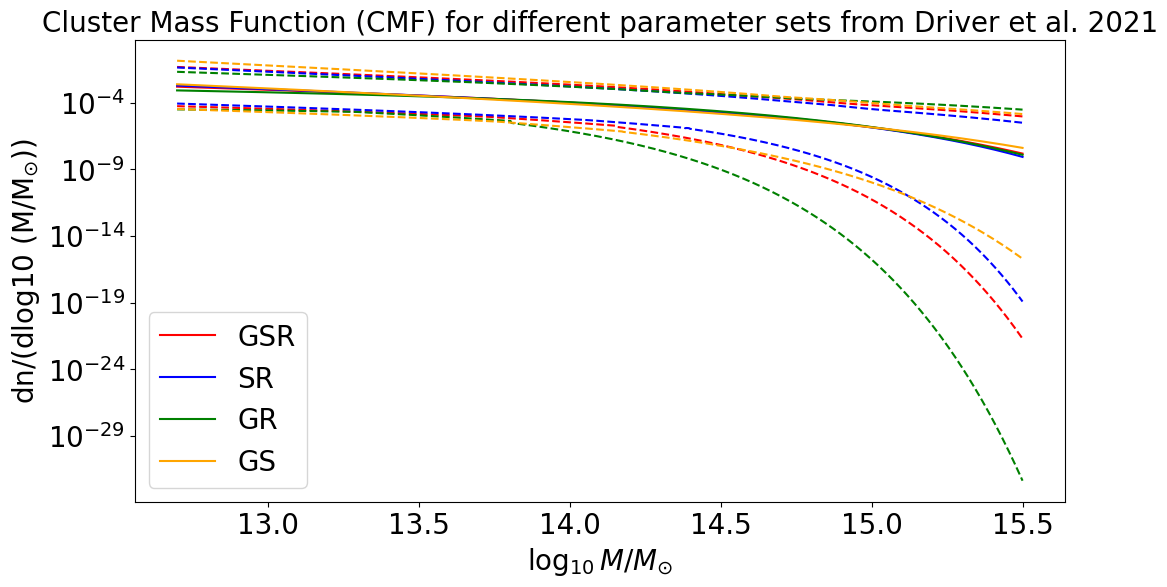

In [15]:
fig = plt.figure(figsize=(12, 6))

cmf_dict = {
    'GSR': {'cmf': CMF_GSR, 'min': Borne_min_CMF_GSR, 'max': Borne_max_CMF_GSR, 'color': 'red'},
    'SR':  {'cmf': CMF_SR,  'min': Borne_min_CMF_SR,  'max': Borne_max_CMF_SR,  'color': 'blue'},
    'GR':  {'cmf': CMF_GR,  'min': Borne_min_CMF_GR,  'max': Borne_max_CMF_GR,  'color': 'green'},
    'GS':  {'cmf': CMF_GS,  'min': Borne_min_CMF_GS,  'max': Borne_max_CMF_GS,  'color': 'orange'}
}

for label, vals in cmf_dict.items():
    plt.plot(log10_M_Msun, vals['cmf'], label=label, color=vals['color'])
    plt.plot(log10_M_Msun, vals['min'], color=vals['color'], linestyle='dashed')
    plt.plot(log10_M_Msun, vals['max'], color=vals['color'], linestyle='dashed')

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')
plt.yscale('log')
plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')
plt.legend()


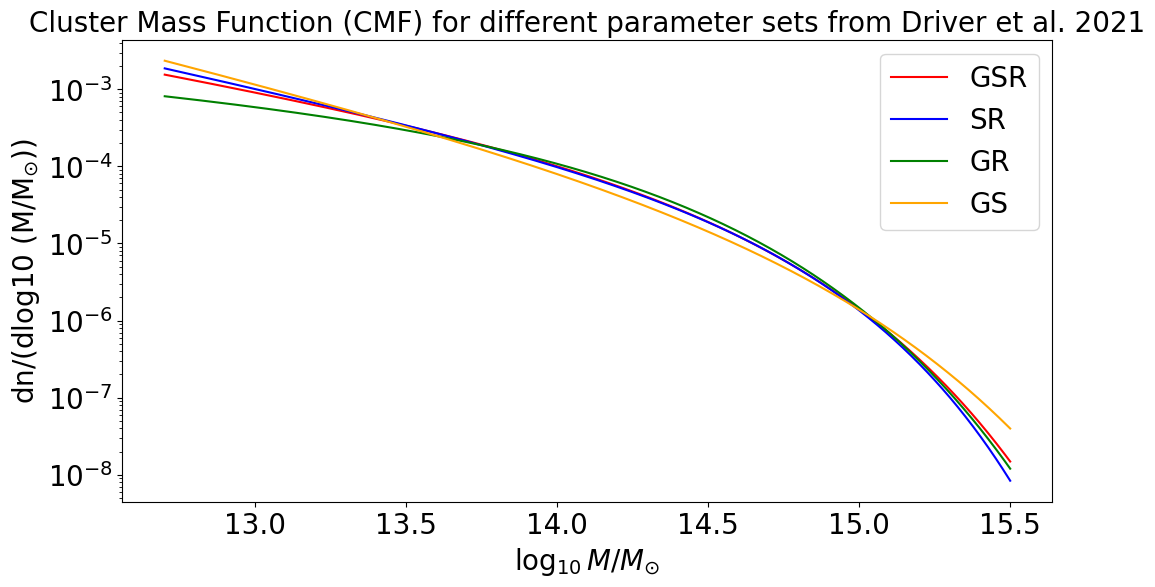

In [16]:
fig = plt.figure(figsize=(12, 6))

cmf_curves = [
    (log10_M_Msun, CMF_GSR, 'GSR', 'red'),
    (log10_M_Msun, CMF_SR,  'SR',  'blue'),
    (log10_M_Msun, CMF_GR,  'GR',  'green'),
    (log10_M_Msun, CMF_GS,  'GS',  'orange')
]

for x, y, label, color in cmf_curves:
    plt.plot(x, y, label=label, color=color)

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')
plt.yscale('log')
plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')
plt.legend()

## Calcul volumes relevés +  nombre d'amas

In [17]:
# ATTENTION : calcul ci desoous PAS VALABLE car la mean density correspond à celle à z = 0.1 → On néglige cependant POUR l'INSTANT l'effet d'évolution de la CMF avec z 

# Nombre théorique d'amas dans le volume couvert par divers catalogues : pour l'instant DESI Legacy Imaging Surveys (Wen et Han 2024) ; SCUSS (Gao et al. 2019)
bornes_z = [0,0.65] # Bornes de redshift pour lesquelles on calcule le nombre d'amas (DESI Legacy va jusqu'à z = 1.5)

bornes_log10_M_Msun = [12.7,15.5] # Bornes de masses pour lesquelles la fonction MRP est valable 

## Densité volumique moyenne de la CMF théorique selon les différents lots de paramètres

mean_density_GSR = uf.CMF_to_mean_density(CMF_GSR_func,bornes_log10_M_Msun)
mean_density_SR = uf.CMF_to_mean_density(CMF_SR_func,bornes_log10_M_Msun)
mean_density_GR = uf.CMF_to_mean_density(CMF_GR_func,bornes_log10_M_Msun)
mean_density_GS = uf.CMF_to_mean_density(CMF_GS_func,bornes_log10_M_Msun)


## DESI Legacy Imaging Surveys

angular_area_DESI_deg2 = 24000 # Surface couverte par DESI Legacy Imaging Surveys en degrés carrés
volume_DESI_LEGACY = uf.Volume_survey(angular_area_DESI_deg2,bornes_z) # Volume en Mpc^3 de la zone couverte par DESI Legacy Imaging Surveys (oon coupe en fait à 0.65 alors que ce relevé va jusqu'à 1.5, et on utilise la distance de diamètre angualaire pour la profondeur)
# GSR / DESI
N_GSR_DESI = mean_density_GSR * volume_DESI_LEGACY # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_DESI = ',round(N_GSR_DESI/1e6,3),'* 1e6 amas')
# SR / DESI
N_SR_DESI = mean_density_SR * volume_DESI_LEGACY 
print('N_SR_DESI = ',round(N_SR_DESI/1e6,3),'* 1e6 amas')
# GR / DESI
N_GR_DESI = mean_density_GR * volume_DESI_LEGACY
print('N_GR_DESI = ',round(N_GR_DESI/1e6,3),'* 1e6 amas')
# GS / DESI
N_GS_DESI = mean_density_GS * volume_DESI_LEGACY
print('N_GS_DESI = ',round(N_GS_DESI/1e6,3),'* 1e6 amas\n')



## SCUSS/SDSS/unWISE
bornes_z_SCUSS = [0.05,0.65]
angular_area_SCUSS_deg2 = 3700 # Surface couverte par SCUSS/SDSS/unWISE en degrés carrés
volume_SCUSS = uf.Volume_survey(angular_area_SCUSS_deg2,bornes_z_SCUSS)
# GSR / SCUSS
N_GSR_SCUSS = mean_density_GSR * volume_SCUSS # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_SCUSS = ',round(N_GSR_SCUSS/1e6,3),'* 1e6 amas')
# SR / eRASS1
N_SR_SCUSS = mean_density_SR * volume_SCUSS 
print('N_SR_SCUSS = ',round(N_SR_SCUSS/1e6,3),'* 1e6 amas')
# GR / SCUSS
N_GR_SCUSS = mean_density_GR * volume_SCUSS
print('N_GR_SCUSSI = ',round(N_GR_SCUSS/1e6,3),'* 1e6 amas')
# GS / SCUSS
N_GS_SCUSS = mean_density_GS * volume_SCUSS
print('N_GS_SCUSS = ',round(N_GS_SCUSS/1e6,3),'* 1e6 amas\n')


## eRASS1
bornes_z_eRASS1 = [0.03,1.32] 
angular_area_eRASS1_deg2 = 13116 # Surface couverte par eRASS1/SDSS/unWISE en degrés carrés
volume_eRASS1 = uf.Volume_survey(angular_area_eRASS1_deg2,bornes_z_eRASS1)
# GSR / eRASS1
N_GSR_eRASS1 = mean_density_GSR * volume_eRASS1 # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_eRASS1 = ',round(N_GSR_eRASS1/1e6,3),'* 1e6 amas')
# SR / eRASS1
N_SR_eRASS1 = mean_density_SR * volume_eRASS1 
print('N_SR_eRASS1 = ',round(N_SR_eRASS1/1e6,3),'* 1e6 amas')
# GR / eRASS1
N_GR_eRASS1 = mean_density_GR * volume_eRASS1
print('N_GR_eRASS1 = ',round(N_GR_eRASS1/1e6,3),'* 1e6 amas')
# GS / eRASS1
N_GS_eRASS1 = mean_density_GS * volume_eRASS1
print('N_GS_eRASS1 = ',round(N_GS_eRASS1/1e6,3),'* 1e6 amas')


N_GSR_DESI =  27.215 * 1e6 amas
N_SR_DESI =  29.846 * 1e6 amas
N_GR_DESI =  19.3 * 1e6 amas
N_GS_DESI =  32.938 * 1e6 amas

N_GSR_SCUSS =  4.193 * 1e6 amas
N_SR_SCUSS =  4.598 * 1e6 amas
N_GR_SCUSSI =  2.973 * 1e6 amas
N_GS_SCUSS =  5.074 * 1e6 amas

N_GSR_eRASS1 =  72.755 * 1e6 amas
N_SR_eRASS1 =  79.788 * 1e6 amas
N_GR_eRASS1 =  51.597 * 1e6 amas
N_GS_eRASS1 =  88.055 * 1e6 amas


# Comparaison avec les catalogues

## DESI Legacy Imaging surveys

In [18]:
path_DESI = '../SCUSS_DESI/DESI_Legacy_Wen_2024.fit'
table_DESI = uf.fits_to_dataframe(path_DESI)

In [19]:
table_DESI

,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,zCl,f_zCl,zmag,...,logMs,r500,lam500,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno
0,0.00046,-37.47628,1,,J000000.1-372835,0.00046,-37.47628,0.1364,0,15.377,...,11.49,0.766,25.79,1.17,14,0.0,0.0,1,WHY18,1
1,0.00135,-56.58835,2,WH-,J000000.3-563518,0.00135,-56.58835,0.1957,0,15.712,...,11.70,0.625,23.24,1.06,7,0.0,0.0,1,,2
2,0.00172,-39.32369,3,,J000000.4-391925,0.00172,-39.32369,0.3580,0,17.713,...,11.41,0.526,15.90,0.73,7,0.0,0.0,1,Y21,3
3,0.00201,2.31980,4,,J000000.5+021911,0.00201,2.31980,0.4282,1,18.043,...,11.55,0.612,23.40,1.07,13,0.0,0.0,1,redMaPPer,4
4,0.00260,-59.01297,5,WH-,J000000.6-590047,0.00260,-59.01297,0.1380,0,14.993,...,11.69,0.606,15.71,0.73,7,0.0,0.0,1,,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581174,359.99667,4.99211,1581175,WH-,J235959.2+045932,359.99667,4.99211,0.5948,0,19.184,...,11.37,0.420,10.99,0.51,6,0.0,0.0,2,,1581175
1581175,359.99680,21.78514,1581176,,J235959.2+214707,359.99680,21.78514,0.4050,1,17.259,...,11.78,0.658,31.73,1.43,9,0.0,0.0,2,WHL,1581176
1581176,359.99817,10.04951,1581177,,J235959.6+100258,359.99817,10.04951,0.7919,0,18.904,...,11.88,0.621,33.23,1.50,8,0.0,0.0,2,CFSFDP,1581177
1581177,359.99847,-6.34469,1581178,WH-,J235959.6-062041,359.99847,-6.34469,1.0333,0,20.952,...,11.18,0.439,13.12,0.61,6,0.0,0.0,2,,1581178


In [20]:
table_DESI.columns

Index(['_RAJ2000', '_DEJ2000', 'ID', 'n_Name', 'Name', 'RAJ2000', 'DEJ2000',
       'zCl', 'f_zCl', 'zmag', 'W1mag', 'logMs', 'r500', 'lam500', 'M500',
       'Ngal', 'Gamma', 'e_Gamma', 'imag_', 'Cat', 'recno'],
      dtype='object')

In [21]:
# Nombre d'amas compris entre les bornes de z utilisés pour le calcul du nombre d'amas à partir de la CMF théorique
N_amas_DESI = len(table_DESI[(table_DESI['zCl'] >= bornes_z[0]) & (table_DESI['zCl'] <= bornes_z[1])])
print('N_amas_DESI = ',N_amas_DESI)

N_amas_DESI =  821225


In [22]:
# A FAIRE → DISTRIBUTION AMAS LUMINOSITE + COULEUR REDSHIFT ...

In [23]:
M500_DESI = np.log10(np.array(table_DESI['M500'])*1e14)
M500_DESI = M500_DESI[(M500_DESI > 12.7) & (M500_DESI < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

Text(0.5, 1.0, 'Histogramme des masses des amas dans DESI Legacy Imaging Surveys')

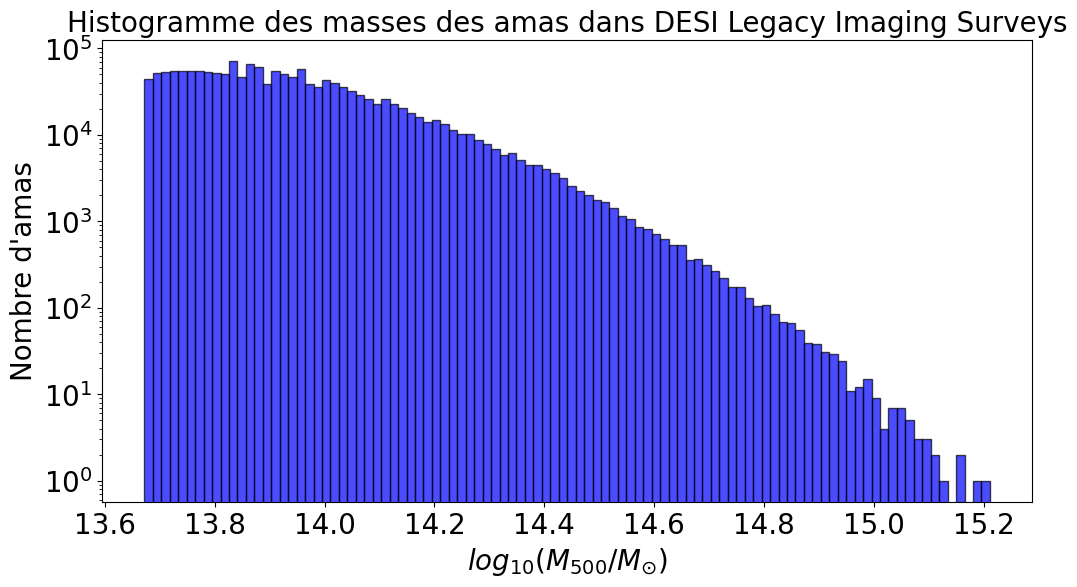

In [24]:
plt.figure(figsize=(12, 6))
plt.hist(M500_DESI, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans DESI Legacy Imaging Surveys')

In [25]:
# Calculate histogram density using our utility function
bin_centers, counts, bin_width_DESI, n_DESI_Legacy = uf.compute_histogram_density(
    data=M500_DESI,
    bins=100,
    volume=volume_DESI_LEGACY)

print("Bin width:", bin_width_DESI)


Bin width: 0.015392896950011448


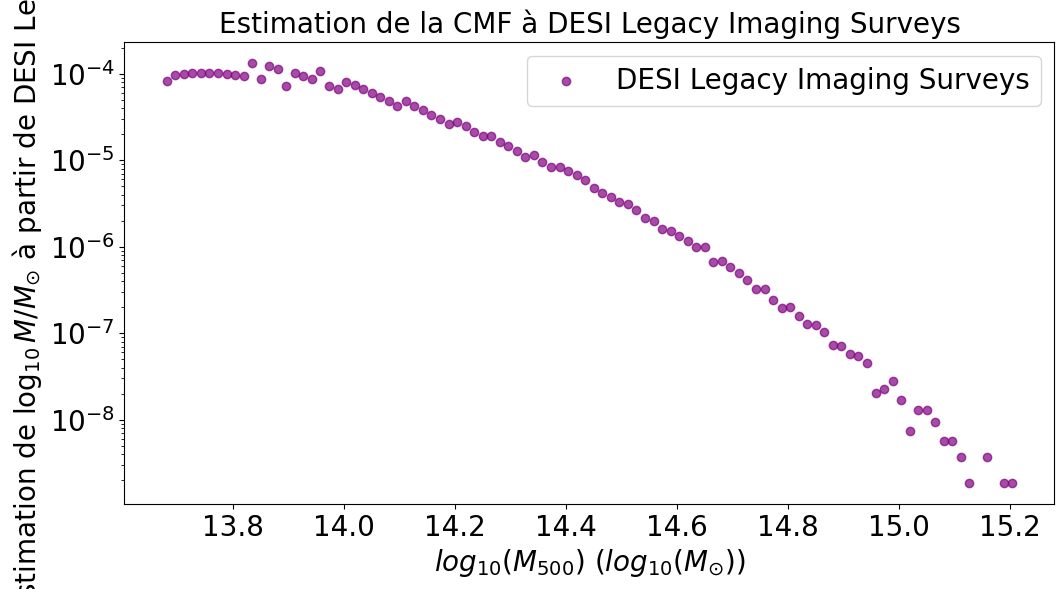

In [26]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $\log_{10} M / M_{\odot}$ à partir de DESI Legacy')
plt.yscale('log')
plt.title('Estimation de la CMF à DESI Legacy Imaging Surveys')
plt.legend()

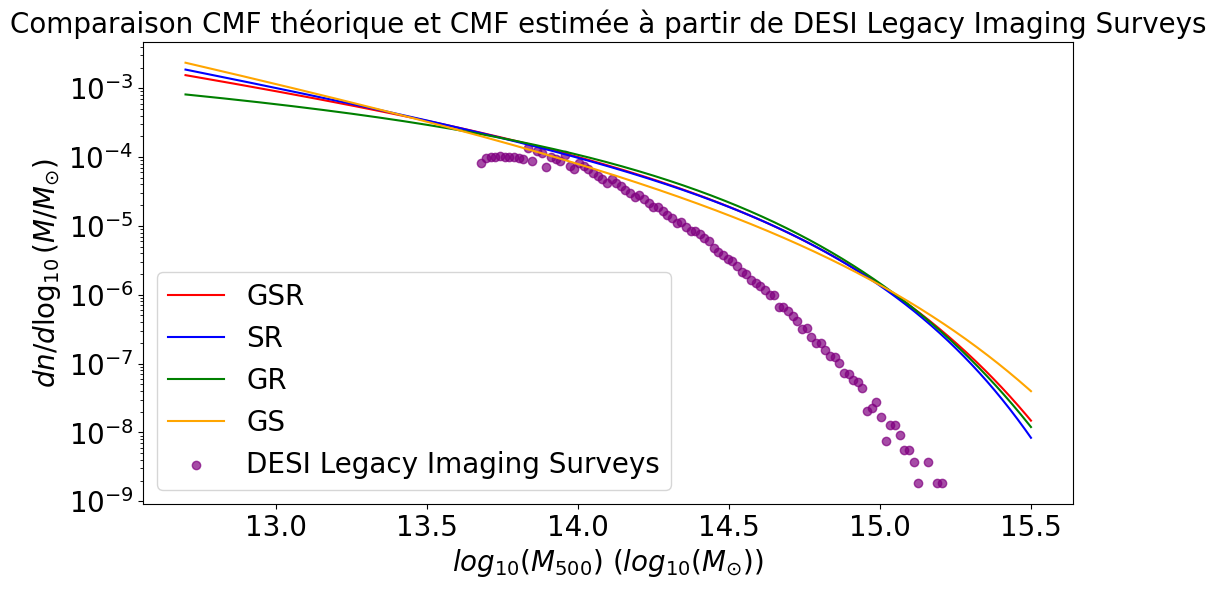

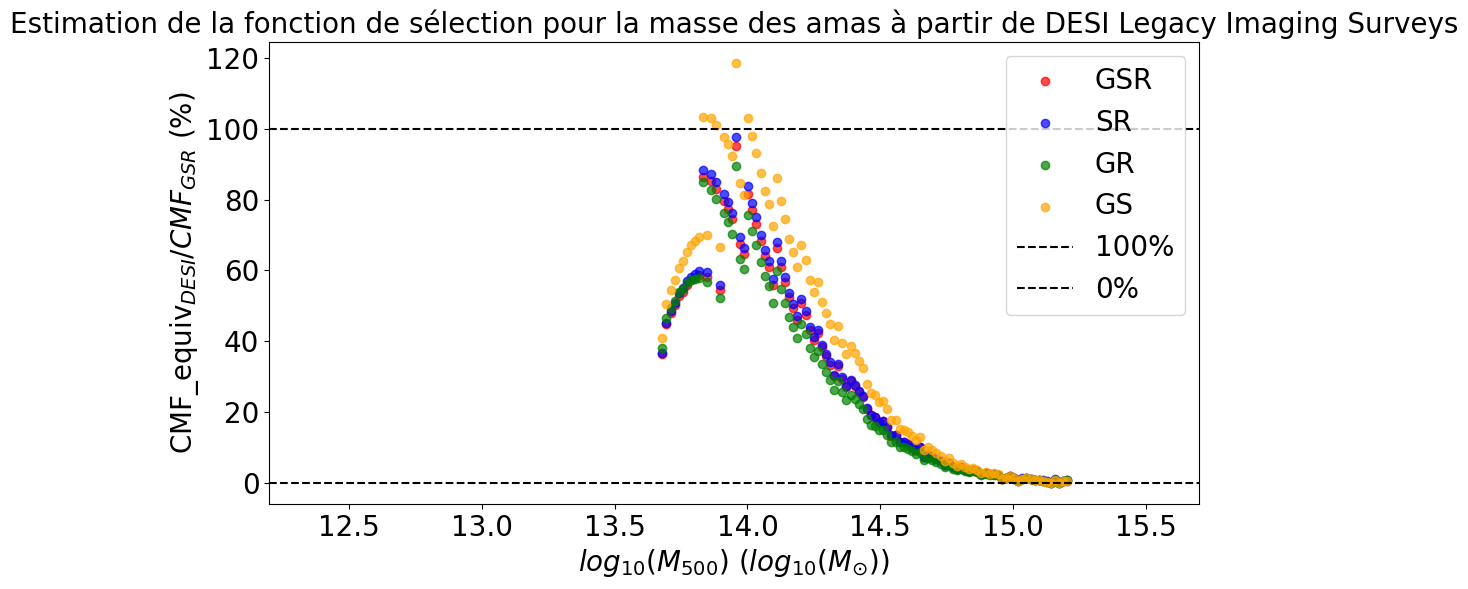

In [27]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} (M / M_{\odot})$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')

plt.legend()

#---------------------------------------------------------------------------------------------
# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_DESI_Legacy/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_DESI_Legacy/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_DESI_Legacy/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_DESI_Legacy/CMF_GS_func(bin_centers)


plt.figure(figsize=(12, 6))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')
plt.xlim(12.2, 15.7)

plt.hlines(100, 12.2, 15.7, color='black', linestyle='dashed', label='100%')
plt.hlines(0, 12.2, 15.7, color='black', linestyle='dashed', label='0%')


plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{DESI} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de DESI Legacy Imaging Surveys')

plt.legend()


plt.legend()

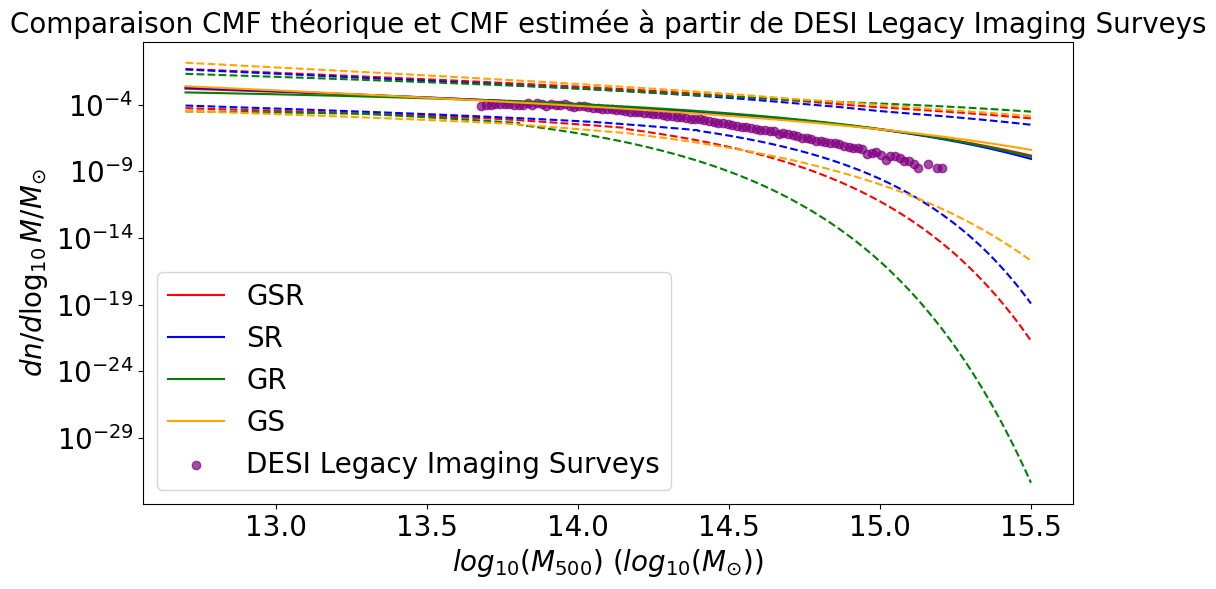

In [28]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()

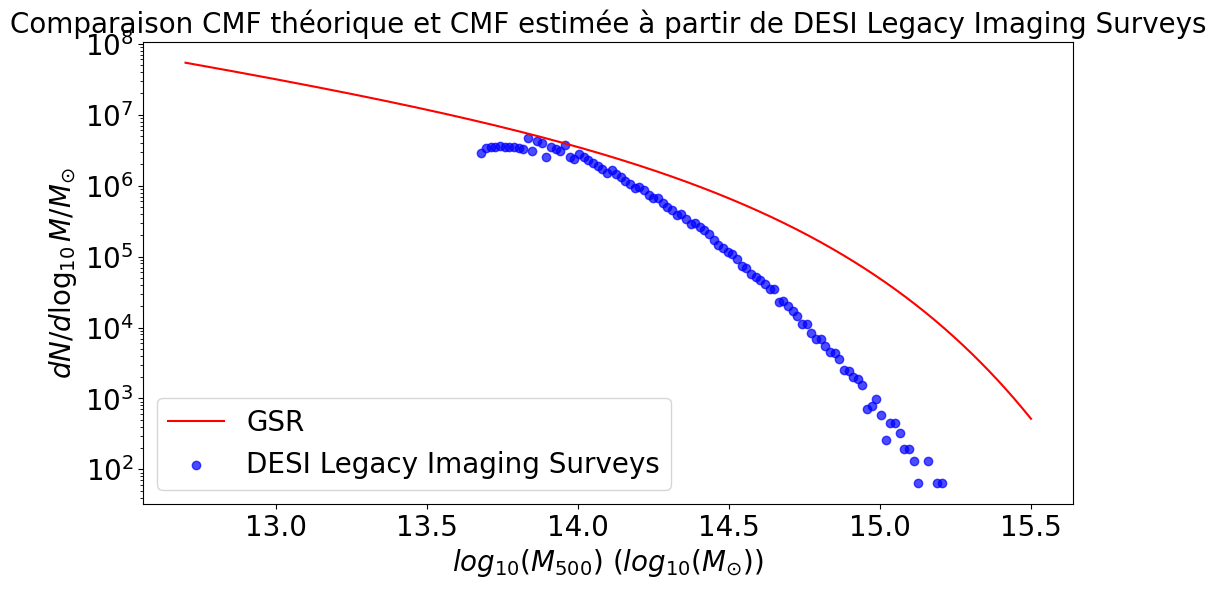

In [29]:
# dex ^-1

fig = plt.figure(figsize=(12, 6))
plt.plot(log10_M_Msun, CMF_GSR*volume_DESI_LEGACY, label='GSR', color='red')
plt.scatter(bin_centers, counts/bin_width_DESI, color='blue', label='DESI Legacy Imaging Surveys', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dN / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()


## SCUSS

In [30]:
#SCUSS
path_SCUSS = '../SCUSS_DESI/SCUSS_Gao_2020.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_SCUSS = uf.fits_to_dataframe(path_SCUSS)

zSCUSS_list = []
for idx, row in table_SCUSS.iterrows():
    if row[f'zsp'] == 0:
        zSCUSS_list.append(row[f'zph'])
    else:
        zSCUSS_list.append(row[f'zsp'])
table_SCUSS['z'] = zSCUSS_list

In [31]:
# On découpe la table en différents bins de z contenant le même nombre d'amas
nb_bins_z = 3
table_SCUSS['z_bin'], bornes_z_SCUSS = pd.qcut(table_SCUSS['z'], q=nb_bins_z, retbins=True, labels=False)
print('Bornes de z pour les bins SCUSS : ', bornes_z_SCUSS)

# Create subtables for each bin
subtables_z_SCUSS = []
for i in range(nb_bins_z):
    subtable = table_SCUSS[table_SCUSS['z_bin'] == i]
    print(f'bin {i}: z from {round(bornes_z_SCUSS[i],3)} to {round(bornes_z_SCUSS[i+1],3)}, count={len(subtable)}')
    subtables_z_SCUSS.append(subtable)

Bornes de z pour les bins SCUSS :  [0.0503     0.28770333 0.39967667 0.6299    ]
bin 0: z from 0.05 to 0.288, count=6537
bin 1: z from 0.288 to 0.4, count=6536
bin 2: z from 0.4 to 0.63, count=6537


In [32]:
table_SCUSS.columns

Index(['_RAJ2000', '_DEJ2000', 'Name', 'RAJ2000', 'DEJ2000', 'zph', 'zsp',
       'zphmedian', 'N1Mpc', 'L1Mpc', 'Richness', 'M500', 'recno', 'z',
       'z_bin'],
      dtype='object')

### Fonction de masse

#### Récupération / Calculs valeurs

In [33]:
M500_SCUSS = np.log10(np.array(table_SCUSS['M500'])*1e14)
M500_SCUSS = M500_SCUSS[(M500_SCUSS > 12.7) & (M500_SCUSS < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

In [34]:
# Calculate histogram density using our utility function
bin_centers, counts, bin_width_SCUSS, n_SCUSS = uf.compute_histogram_density(
    data=M500_SCUSS,
    bins=100,
    volume=volume_SCUSS
)

print("Bin width:", bin_width_SCUSS)

Bin width: 0.024221519325980267


In [35]:
# Estimation de la fonction de sélection pour la masse des amas

estimation_selection_function_masse_GSR = n_SCUSS/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_SCUSS/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_SCUSS/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_SCUSS/CMF_GS_func(bin_centers)

estimation_selection_function_masse_bocquet2016 = n_SCUSS/hcmf.CMF_Bocquet_2016(10**bin_centers,z_Bocquet2016)

#### Tracés

Text(0.5, 1.0, 'Histogramme des masses des amas dans SCUSS')

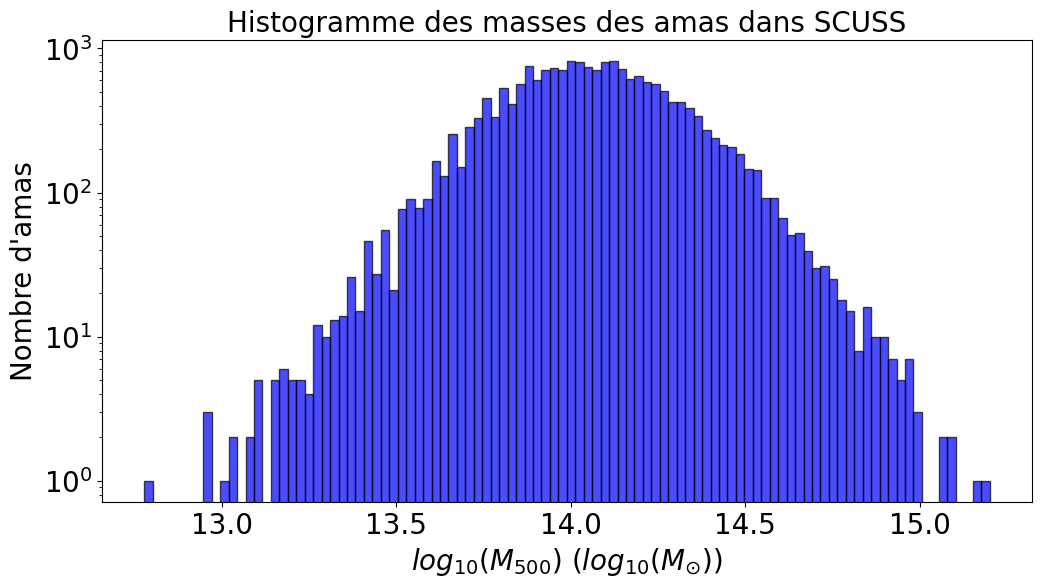

In [36]:
plt.figure(figsize=(12, 6))
plt.hist(M500_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans SCUSS')

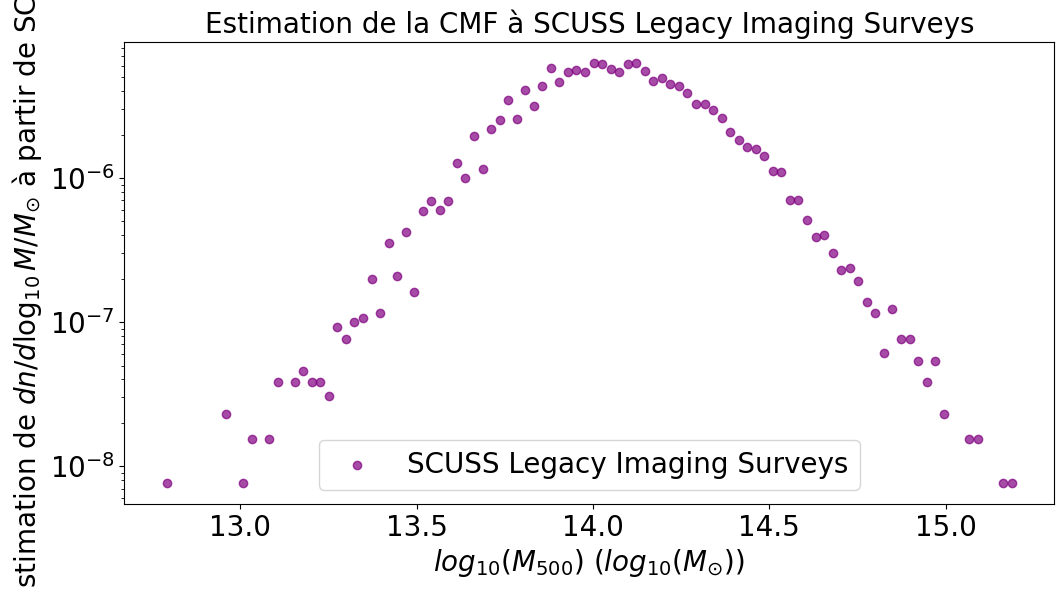

In [37]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $dn / d\log_{10} M / M_{\odot}$ à partir de SCUSS')
plt.yscale('log')
plt.title('Estimation de la CMF à SCUSS Legacy Imaging Surveys')
plt.legend()

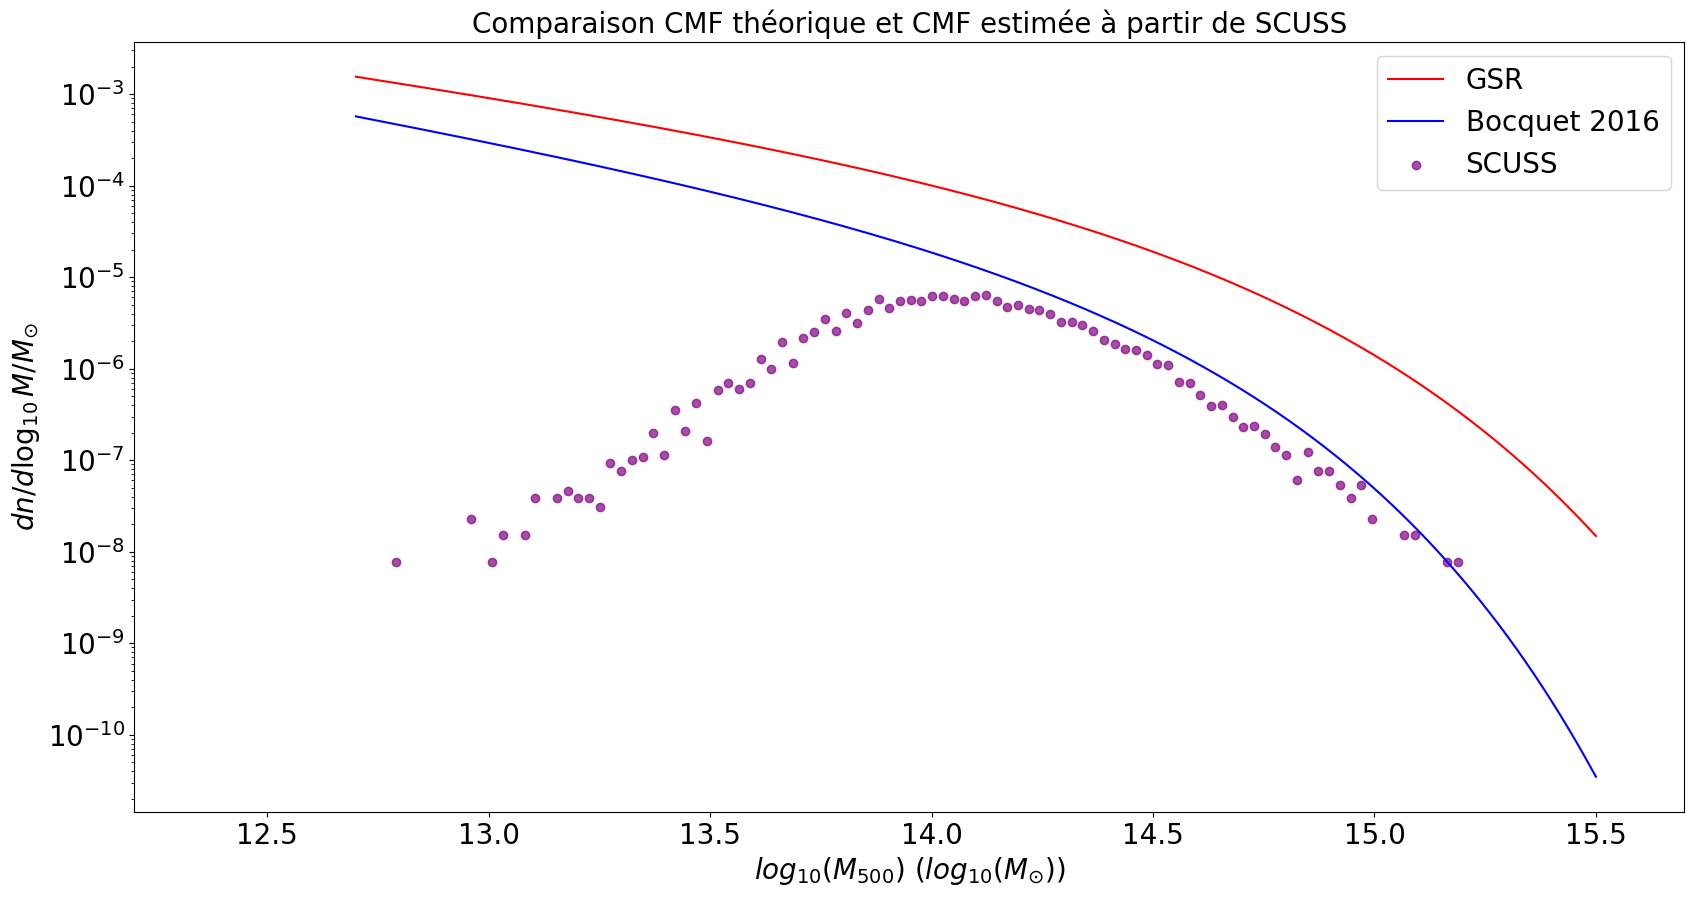

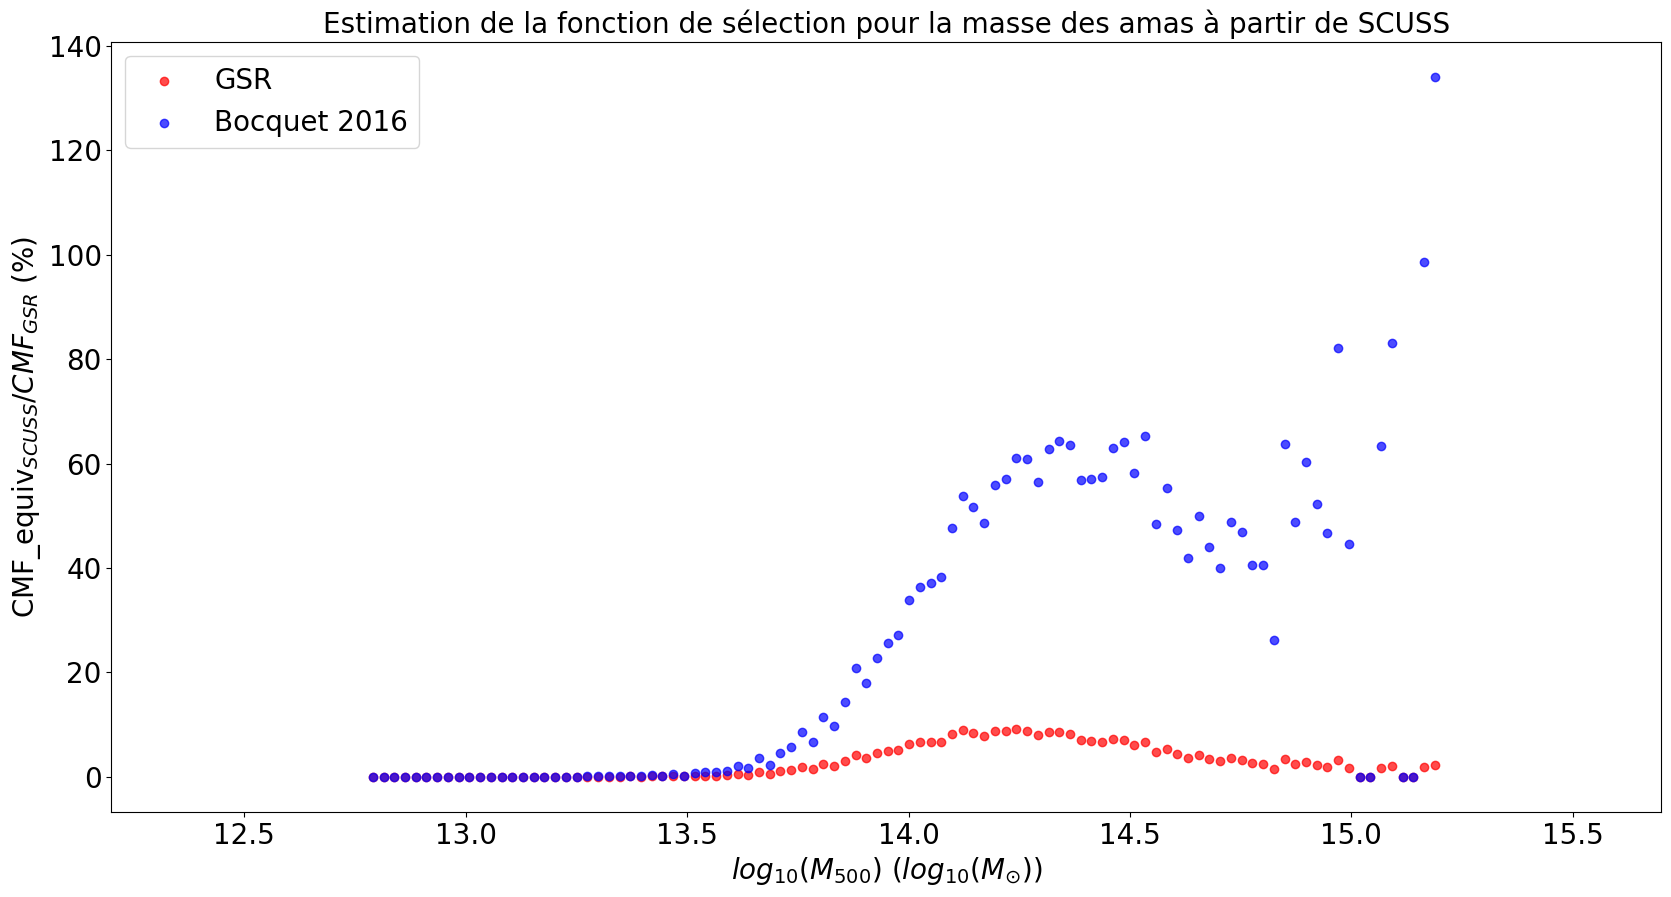

In [38]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

#-------------------------------------
fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red') # MRP GSR
#plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
#plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
#plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.plot(log10_M_Msun, CMF_Bocquet2016, label='Bocquet 2016', color='blue') # Bocquet 2016


plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)
plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')

plt.legend()

#-------------------------------------

plt.figure(figsize=(20, 10))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
#plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
#plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
#plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')

plt.scatter(bin_centers, estimation_selection_function_masse_bocquet2016 * 100, color='blue', alpha=0.7,label='Bocquet 2016')

plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{SCUSS} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de SCUSS')

plt.legend()

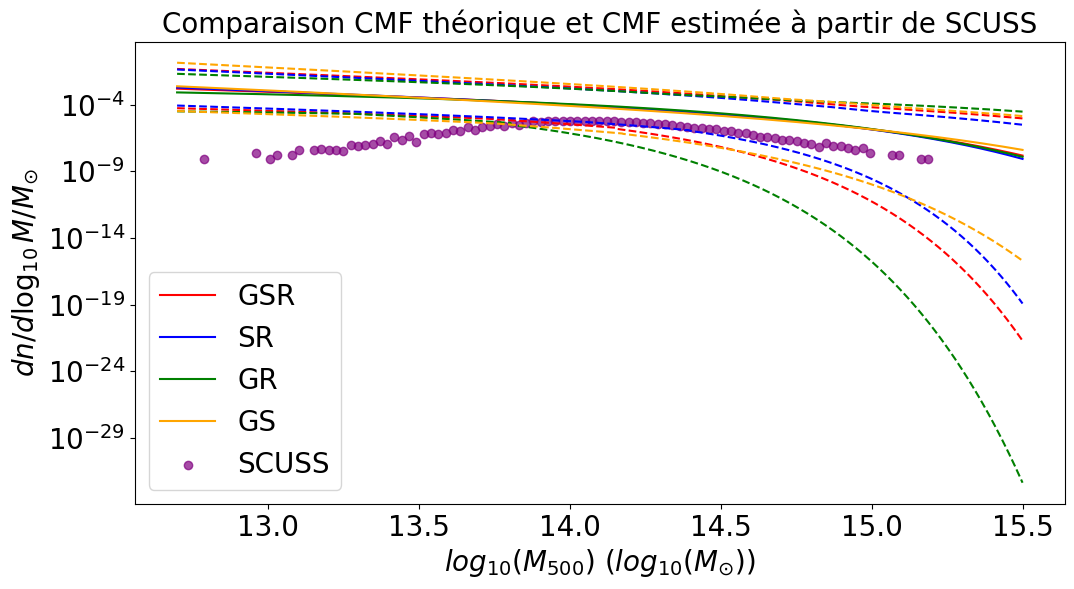

In [39]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')
plt.legend()

### Fonction de "richesse"

#### Récupération / Calculs valeurs

In [40]:
RL_SCUSS = table_SCUSS['Richness'] # On récupère les données sur la richesse des amas

In [41]:
table_SCUSS

,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,zphmedian,N1Mpc,L1Mpc,Richness,M500,recno,z,z_bin
0,0.00035,13.02347,0,0.00035,13.02347,0.3769,0.00000,0.38710,24,7.00224,22.90440,1.26,1,0.37690,1
1,0.00635,2.95542,1,0.00635,2.95542,0.4571,0.42290,0.43890,17,6.56276,23.13604,1.27,2,0.42290,2
2,0.00958,5.28826,2,0.00958,5.28826,0.1734,0.16936,0.17750,58,14.09044,35.83500,2.04,3,0.16936,0
3,0.01474,31.78564,3,0.01474,31.78564,0.0824,0.00000,0.10490,64,12.95997,25.62747,1.42,4,0.08240,0
4,0.01476,8.94881,4,0.01476,8.94881,0.2609,0.00000,0.27620,26,8.83946,24.11363,1.33,5,0.26090,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19605,359.97270,13.33689,19605,359.97270,13.33689,0.2360,0.24498,0.23050,24,6.31375,14.90396,0.79,19606,0.24498,0
19606,359.98382,3.48642,19606,359.98382,3.48642,0.5132,0.00000,0.51320,20,8.83291,40.95954,2.35,19607,0.51320,2
19607,359.98503,-3.43589,19607,359.98503,-3.43589,0.3251,0.00000,0.32065,26,8.59997,26.87073,1.49,19608,0.32510,1
19608,359.98757,8.56171,19608,359.98757,8.56171,0.3556,0.00000,0.37079,14,3.79424,9.74870,0.50,19609,0.35560,1


In [42]:
indexes_SCUSS = np.arange(0,len(table_SCUSS))

In [43]:
indexes_SCUSS

array([    0,     1,     2, ..., 19607, 19608, 19609], shape=(19610,))

In [44]:
bin_centers_RL, counts_RL, bin_width_SCUSS_RL, n_SCUSS_RL = uf.compute_histogram_density(RL_SCUSS, bins=100, volume=volume_SCUSS)
print("Bin width RL :", bin_width_SCUSS_RL)

Bin width RL : 2.3848826


In [45]:
# Calculs des CRF (Cluster Richness Function) théoriques
array_RL_SCUSS = np.linspace(np.min(RL_SCUSS), np.max(RL_SCUSS), 1000) # RL

CRF_MRP_GSR_func = hcmf.CRF_MRP(params_GSR) # "CRF" pour Cluster Richness Function → MRP car tirée de la CMF MRP 
CRF_MRP_SR_func = hcmf.CRF_MRP(params_SR)
CRF_MRP_GR_func = hcmf.CRF_MRP(params_GR)
CRF_MRP_GS_func = hcmf.CRF_MRP(params_GS)

CRF_MRP_GSR_result = CRF_MRP_GSR_func(array_RL_SCUSS)
CRF_MRP_GSR = CRF_MRP_GSR_result[0]
CMF_GSR_from_RL_SCUSS_min = CRF_MRP_GSR_result[1]
CMF_GSR_from_RL_SCUSS_max = CRF_MRP_GSR_result[2]

bin_centers_log10_M_Msun_from_RL_SCUSS = uf.RL_to_log10_M_Msun(bin_centers_RL)[0]
CRF_MRP_GSR_result_bin_centers = CRF_MRP_GSR_func(bin_centers_log10_M_Msun_from_RL_SCUSS)
CRF_MRP_GSR_bin_centers = CRF_MRP_GSR_result_bin_centers[0]
CMF_GSR_from_RL_SCUSS_min_bin_centers = CRF_MRP_GSR_result_bin_centers[1]
CMF_GSR_from_RL_SCUSS_max_bin_centers = CRF_MRP_GSR_result_bin_centers[2]

# Estimation de la fonction de sélection pour la richesse des amas
estimation_selection_function_RL_SCUSS_GSR = n_SCUSS_RL/CRF_MRP_GSR_bin_centers


#### Tracés

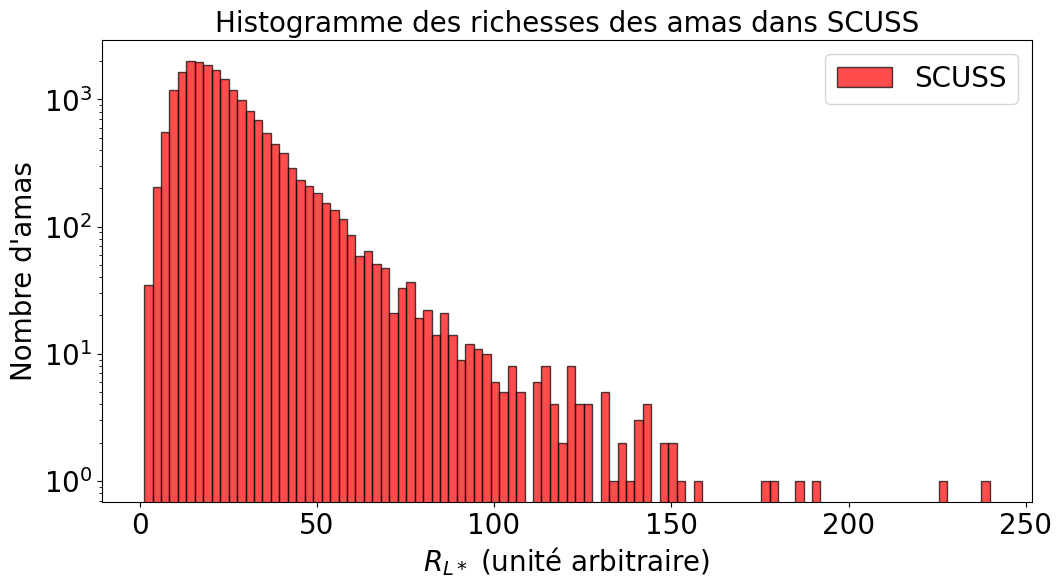

In [46]:
plt.figure(figsize=(12, 6))
plt.hist(RL_SCUSS, bins=100, color='red', edgecolor='black', alpha=0.7,label='SCUSS')
plt.xlabel(r'$R_{L*}$ (unité arbitraire)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des richesses des amas dans SCUSS')
plt.legend()


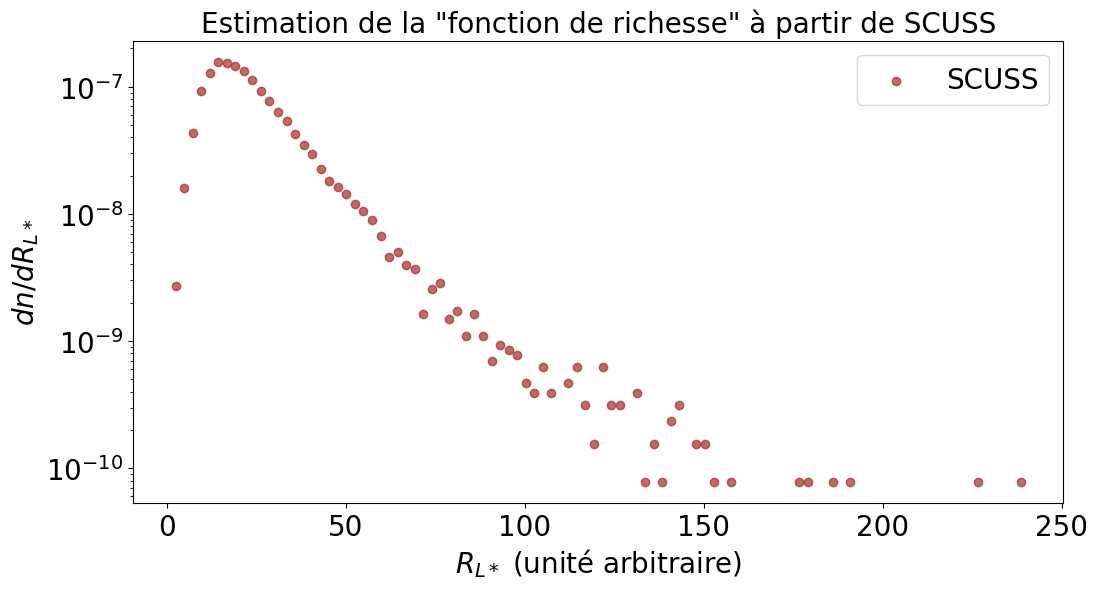

In [47]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_RL, n_SCUSS_RL, color='brown', label='SCUSS', alpha=0.7) 
plt.xlabel(r'$R_{L*}$ (unité arbitraire)')
plt.ylabel(r'$dn / dR_{L*}$')
plt.yscale('log')
plt.title(r'Estimation de la "fonction de richesse" à partir de SCUSS')
plt.legend()

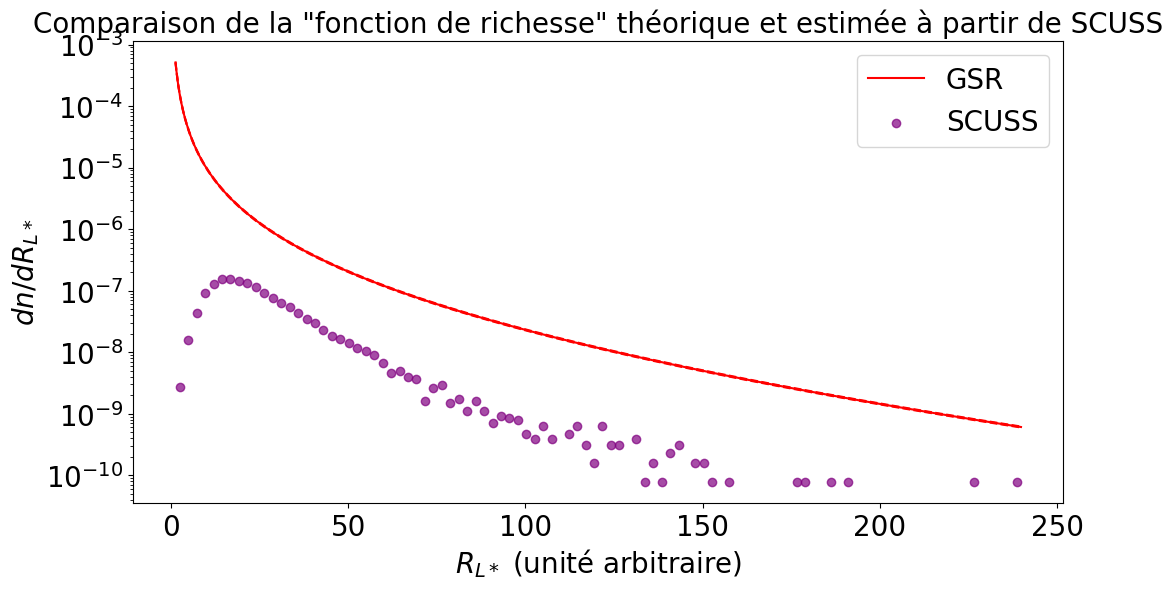

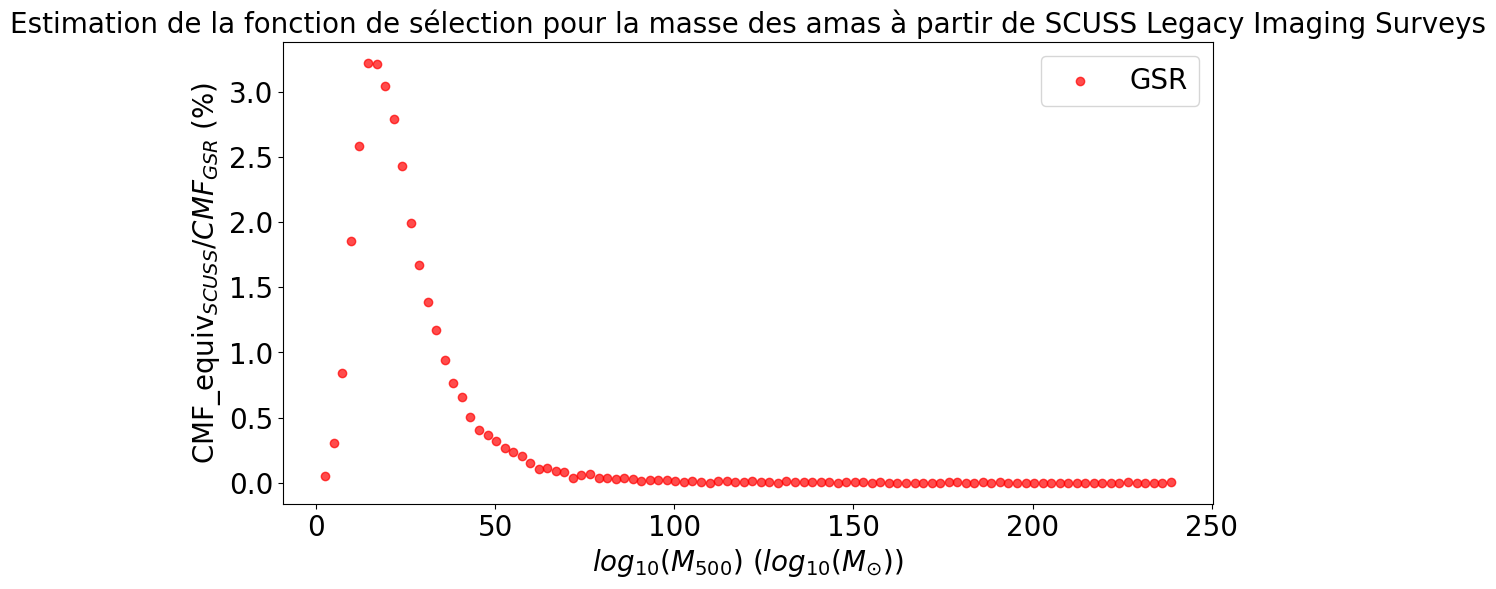

In [48]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(12, 6))

plt.plot(array_RL_SCUSS, CRF_MRP_GSR, label='GSR', color='red')
plt.plot(array_RL_SCUSS, CMF_GSR_from_RL_SCUSS_min, color='red',linestyle='dashed')
plt.plot(array_RL_SCUSS, CMF_GSR_from_RL_SCUSS_max, color='red',linestyle='dashed')

plt.scatter(bin_centers_RL, n_SCUSS_RL, color='purple', label='SCUSS', alpha=0.7)

plt.xlabel(r'$R_{L*}$ (unité arbitraire)',fontsize=20)
plt.ylabel(r'$dn / dR_{L*}$',fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.yscale('log')
plt.title(r'Comparaison de la "fonction de richesse" théorique et estimée à partir de SCUSS',fontsize=20)

plt.legend(fontsize=20)

#-------------------------------------

plt.figure(figsize=(12, 6))

plt.scatter(bin_centers_RL, estimation_selection_function_RL_SCUSS_GSR * 100, color='red', alpha=0.7,label='GSR')
'''plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')'''

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{SCUSS} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de SCUSS Legacy Imaging Surveys')

plt.legend()

### Fonction de luminosité

#### Choix L* ou Lsun

In [49]:
# Choix de l'unité de luminosité : 'Lsun' ou 'L*' ? 
L = 'L*'

#### L1Mpc - Luminosité absolue en bande r

#### Récupération / Calculs valeurs

In [50]:
# Données SCUSS : L1Mpc :

# Lsun :
# On ajoute une colonne log10(L/Lsun) à la table SCUSS (tirée de la relation de Blanton et al. 2003)

log10_L1Mpc_Lsun_SCUSS = uf.L_star_L_sun_for_SCUSS(table_SCUSS)
table_SCUSS['log10_L1Mpc_Lsun'] = log10_L1Mpc_Lsun_SCUSS
L1Mpc_Lsun_SCUSS = 10**(table_SCUSS['log10_L1Mpc_Lsun'])
table_SCUSS['L1Mpc_Lsun'] = L1Mpc_Lsun_SCUSS

for i, subtable in enumerate(subtables_z_SCUSS):
    sub_log10_L1Mpc_Lsun_SCUSS = uf.L_star_L_sun_for_SCUSS(subtable)
    subtable['log10_L1Mpc_Lsun'] = sub_log10_L1Mpc_Lsun_SCUSS
    sub_L1Mpc_Lsun_SCUSS = 10**(sub_log10_L1Mpc_Lsun_SCUSS)
    subtable['L1Mpc_Lsun'] = sub_L1Mpc_Lsun_SCUSS
    subtables_z_SCUSS[i] = subtable


# L* :
L1MPC_SCUSS = table_SCUSS['L1Mpc'] # Gao et al. 2019, section 3.3 : "L1Mpc is the total r-band luminosity of cluster members within a distance of 1 Mpc from the BCG"
log10_L1MPC_SCUSS = np.log10(L1MPC_SCUSS) # Calcul possible car L1Mpc est adimensionné (exprimé en unités de L*, lumisnoisté de référence d'une galaxie)

C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\2268169918.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtable['log10_L1Mpc_Lsun'] = sub_log10_L1Mpc_Lsun_SCUSS
C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\2268169918.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtable['L1Mpc_Lsun'] = sub_L1Mpc_Lsun_SCUSS
C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\2268169918.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

In [51]:
if L == 'L*':
    bin_centers_L1Mpc, counts_L1Mpc, bin_width_SCUSS_L1Mpc, n_SCUSS_L1Mpc = uf.compute_histogram_density(L1MPC_SCUSS, bins=100, volume=volume_SCUSS)
    print("Bin width L1Mpc:", bin_width_SCUSS_L1Mpc)

    bin_centers_L1Mpc_log10, counts_L1Mpc_log10, bin_width_SCUSS_L1Mpc_log10, n_SCUSS_L1Mpc_log10 = uf.compute_histogram_density(log10_L1MPC_SCUSS, bins=100, volume=volume_SCUSS)
    print("Bin width log10(L1Mpc):", bin_width_SCUSS_L1Mpc_log10)
    
    bins_mean_z = [] # Je vais y placer les valeurs moyennes de z pour chaque bin de luminosité, afin de pouvoir les positionner sur l'axe des redshifts dans le graphe 3D
    for i in range(len(bin_centers_L1Mpc)):
        current_table_SCUSS = table_SCUSS[
            (table_SCUSS['L1Mpc'] >= (bin_centers_L1Mpc[i]-(1/2)*bin_width_SCUSS_L1Mpc)) &
            (table_SCUSS['L1Mpc'] < (bin_centers_L1Mpc[i]+(1/2)*bin_width_SCUSS_L1Mpc))
        ]
        current_mean_z = current_table_SCUSS['z'].mean()
        bins_mean_z.append(current_mean_z)

        # Théorie fonction de luminosité
        array_L1Mpc_SCUSS = np.linspace(np.min(L1MPC_SCUSS), np.max(L1MPC_SCUSS), 100) # L1Mpc
        array_log10_L1Mpc_SCUSS = np.log10(array_L1Mpc_SCUSS) 
        array_z = np.array([0.1,0.2,0.3,0.4,0.5,0.6]) # On va faire plusieurs tracés en fonction de plusieurs redshifts
        array_z_3D = np.linspace(bornes_z[0], bornes_z[1], 1000) # Pour le graphe 3D

        # Calcul de (dn /dlog10(L1Mpc))(log10(L1Mpc)) 
        # 2D
        CLF_log10_MRP_GSR_func = hcmf.CLF_log10_MRP(params_GSR,array_z)
        CLF_log10_MRP_GSR_result = CLF_log10_MRP_GSR_func(array_log10_L1Mpc_SCUSS)
        CLF_log10_MRP_GSR = CLF_log10_MRP_GSR_result[0]
        CLF_log10_MRP_GSR_from_min = CLF_log10_MRP_GSR_result[1] # on calcule popur la valeur minimale de log10(L1Mpc) autorisée par la dispersion de la relation de scaling
        CLF_log10_MRP_GSR_from_max = CLF_log10_MRP_GSR_result[2] # idem mais pour la valeur max

        #3D
        CLF_log10_MRP_GSR_func_3D = hcmf.CLF_log10_MRP(params_GSR,array_z_3D)
        CLF_log10_MRP_GSR_result_3D = CLF_log10_MRP_GSR_func_3D(array_log10_L1Mpc_SCUSS)
        CLF_log10_MRP_GSR_3D = CLF_log10_MRP_GSR_result_3D[0]



        

elif L == 'Lsun':
    bin_centers_L1Mpc, counts_L1Mpc, bin_width_SCUSS_L1Mpc, n_SCUSS_L1Mpc = uf.compute_histogram_density(L1Mpc_Lsun_SCUSS, bins=100, volume=volume_SCUSS)
    print("Bin width L1Mpc:", bin_width_SCUSS_L1Mpc)

    bin_centers_L1Mpc_log10, counts_L1Mpc_log10, bin_width_SCUSS_L1Mpc_log10, n_SCUSS_L1Mpc_log10 = uf.compute_histogram_density(log10_L1Mpc_Lsun_SCUSS, bins=100, volume=volume_SCUSS)
    print("Bin width log10(L1Mpc):", bin_width_SCUSS_L1Mpc_log10)

    bins_mean_z = [] # Je vais y placer les valeurs moyennes de z pour chaque bin de luminosité, afin de pouvoir les positionner sur l'axe des redshifts dans le graphe 3D
    for i in range(len(bin_centers_L1Mpc)):
        current_table_SCUSS = table_SCUSS[
            (table_SCUSS['L1Mpc_Lsun'] >= (bin_centers_L1Mpc[i]-(1/2)*bin_width_SCUSS_L1Mpc)) &
            (table_SCUSS['L1Mpc_Lsun'] < (bin_centers_L1Mpc[i]+(1/2)*bin_width_SCUSS_L1Mpc))
        ]
        current_mean_z = current_table_SCUSS['z'].mean()
        bins_mean_z.append(current_mean_z)

        # Théorie fonction de luminosité
        array_L1Mpc_SCUSS = np.linspace(np.min(L1Mpc_Lsun_SCUSS), np.max(L1Mpc_Lsun_SCUSS), 100) # L1Mpc # modif pour Lsun
        array_log10_L1Mpc_SCUSS = np.log10(array_L1Mpc_SCUSS) 
        array_z = np.array([0.1,0.2,0.3,0.4,0.5,0.6]) # On va faire plusieurs tracés en fonction de plusieurs redshifts
        array_z_3D = np.linspace(bornes_z[0], bornes_z[1], 1000) # Pour le graphe 3D

        # Calcul de (dn /dlog10(L1Mpc))(log10(L1Mpc)) 
        # 2D
        CLF_log10_MRP_GSR_func = hcmf.CLsunF_log10_MRP(params_GSR,array_z) # modif pour Lsun
        CLF_log10_MRP_GSR_result = CLF_log10_MRP_GSR_func(array_log10_L1Mpc_SCUSS)
        CLF_log10_MRP_GSR = CLF_log10_MRP_GSR_result[0]
        CLF_log10_MRP_GSR_from_min = CLF_log10_MRP_GSR_result[1] 
        CLF_log10_MRP_GSR_from_max = CLF_log10_MRP_GSR_result[2] 

        #3D
        CLF_log10_MRP_GSR_func_3D = hcmf.CLsunF_log10_MRP(params_GSR,array_z_3D) # modif pour Lsun
        CLF_log10_MRP_GSR_result_3D = CLF_log10_MRP_GSR_func_3D(array_log10_L1Mpc_SCUSS)
        CLF_log10_MRP_GSR_3D = CLF_log10_MRP_GSR_result_3D[0]

Bin width L1Mpc: 0.3860154
Bin width log10(L1Mpc): 0.014715418121722834


#### Tracés

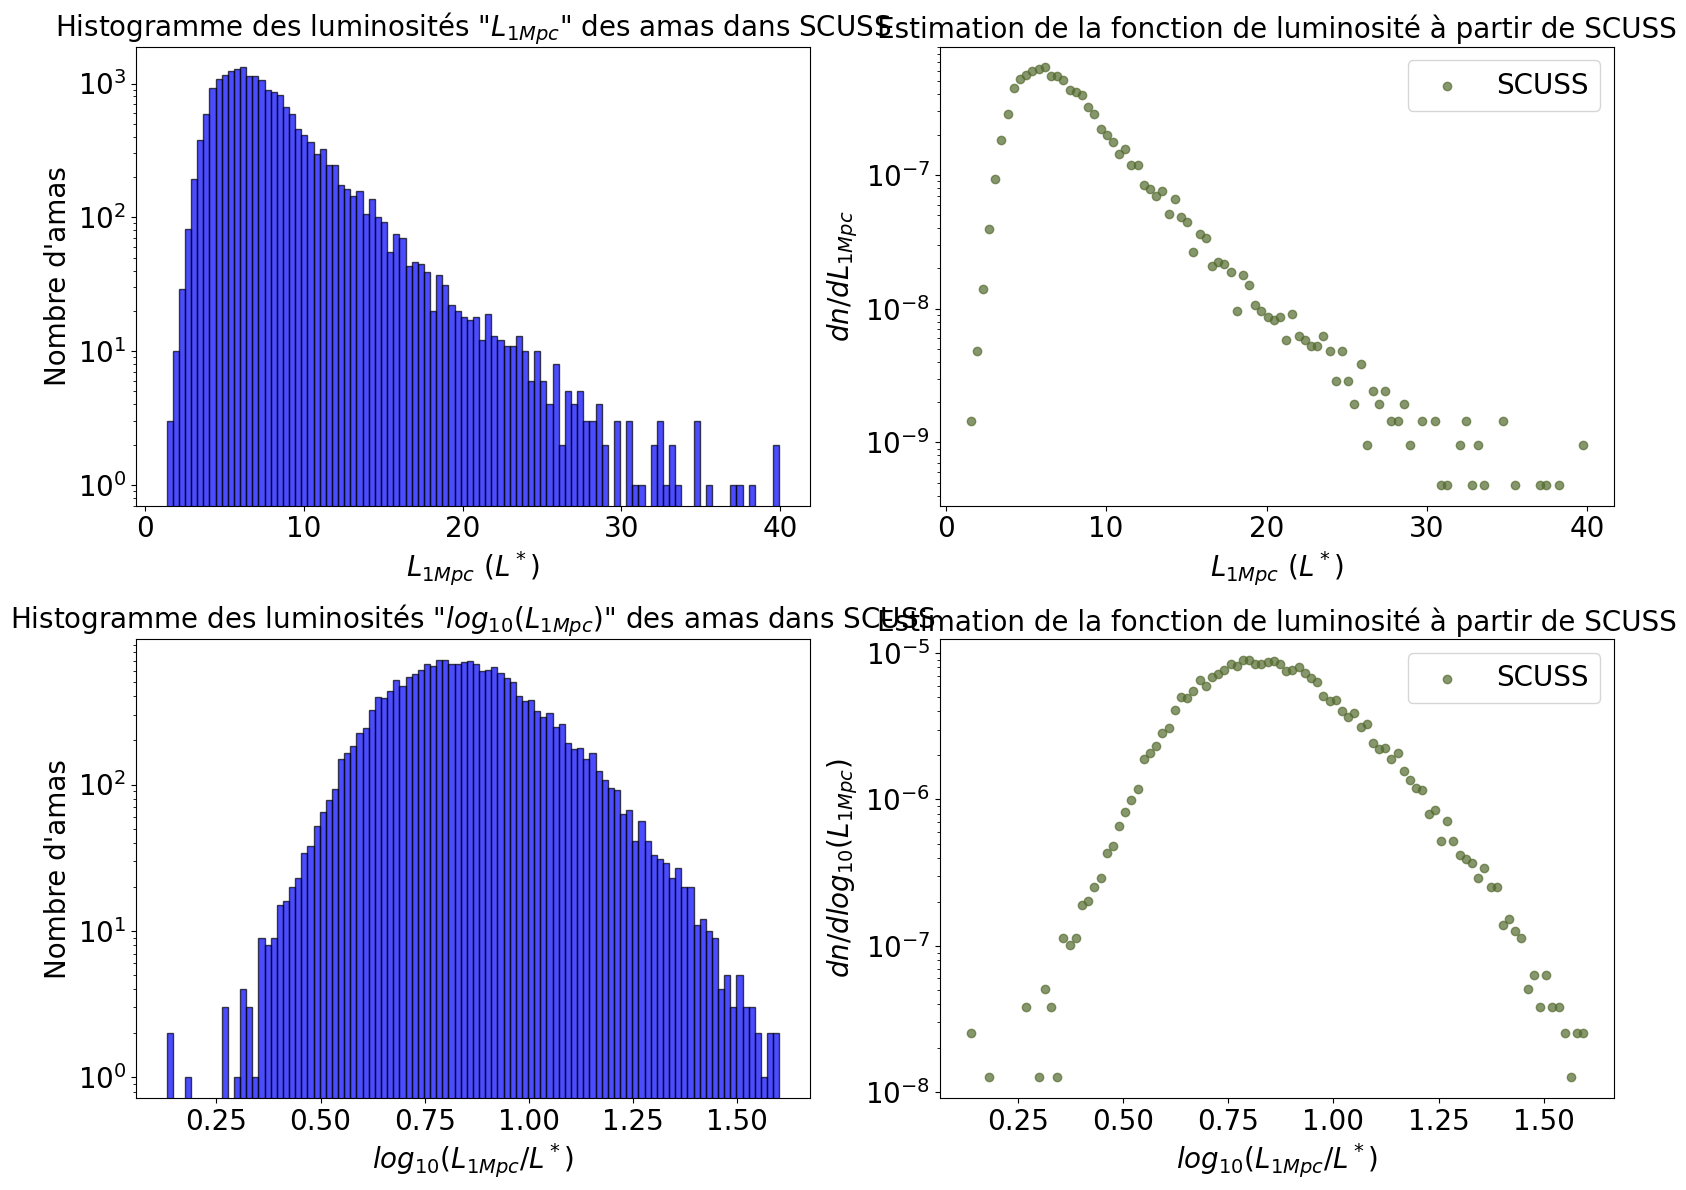

In [52]:
# L1Mpc and log10(L1Mpc) plots as 2x2 subplots

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Histogram L1Mpc
axs[0, 0].hist(L1MPC_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
if L == 'L*':
    axs[0, 0].set_xlabel(r'$L_{1Mpc}$ ($L^*$)')
elif L == 'Lsun':
    axs[0, 0].set_xlabel(r'$L_{1Mpc}$ ($L_{\odot}$)')
axs[0, 0].set_ylabel('Nombre d\'amas')
axs[0, 0].set_yscale('log')
axs[0, 0].set_title(r'Histogramme des luminosités "$L_{1Mpc}$" des amas dans SCUSS')

# Top right: dn/dL1Mpc scatter
axs[0, 1].scatter(bin_centers_L1Mpc, n_SCUSS_L1Mpc, color='darkolivegreen', label='SCUSS', alpha=0.7)
if L == 'L*':
    axs[0, 1].set_xlabel(r'$L_{1Mpc}$ ($L^*$)')
elif L == 'Lsun':
    axs[0, 1].set_xlabel(r'$L_{1Mpc}$ ($L_{\odot}$)')
axs[0, 1].set_ylabel(r'$dn / dL_{1Mpc}$')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title(r'Estimation de la fonction de luminosité à partir de SCUSS')
axs[0, 1].legend()

# Bottom left: Histogram log10(L1Mpc)
axs[1, 0].hist(log10_L1MPC_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
if L == 'L*':
    axs[1, 0].set_xlabel(r'$log_{10}(L_{1Mpc}/L^*)$')
elif L == 'Lsun':
    axs[1, 0].set_xlabel(r'$log_{10}(L_{1Mpc}/L_{\odot})$')
axs[1, 0].set_ylabel('Nombre d\'amas')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title(r'Histogramme des luminosités "$log_{10}(L_{1Mpc})$" des amas dans SCUSS')

# Bottom right: dn/dlog10(L1Mpc) scatter
axs[1, 1].scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='darkolivegreen', label='SCUSS', alpha=0.7)
if L == 'L*':
    axs[1, 1].set_xlabel(r'$log_{10}(L_{1Mpc}/L^*)$')
elif L == 'Lsun':
    axs[1, 1].set_xlabel(r'$log_{10}(L_{1Mpc}/L_{\odot})$')
axs[1, 1].set_ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title(r'Estimation de la fonction de luminosité à partir de SCUSS')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


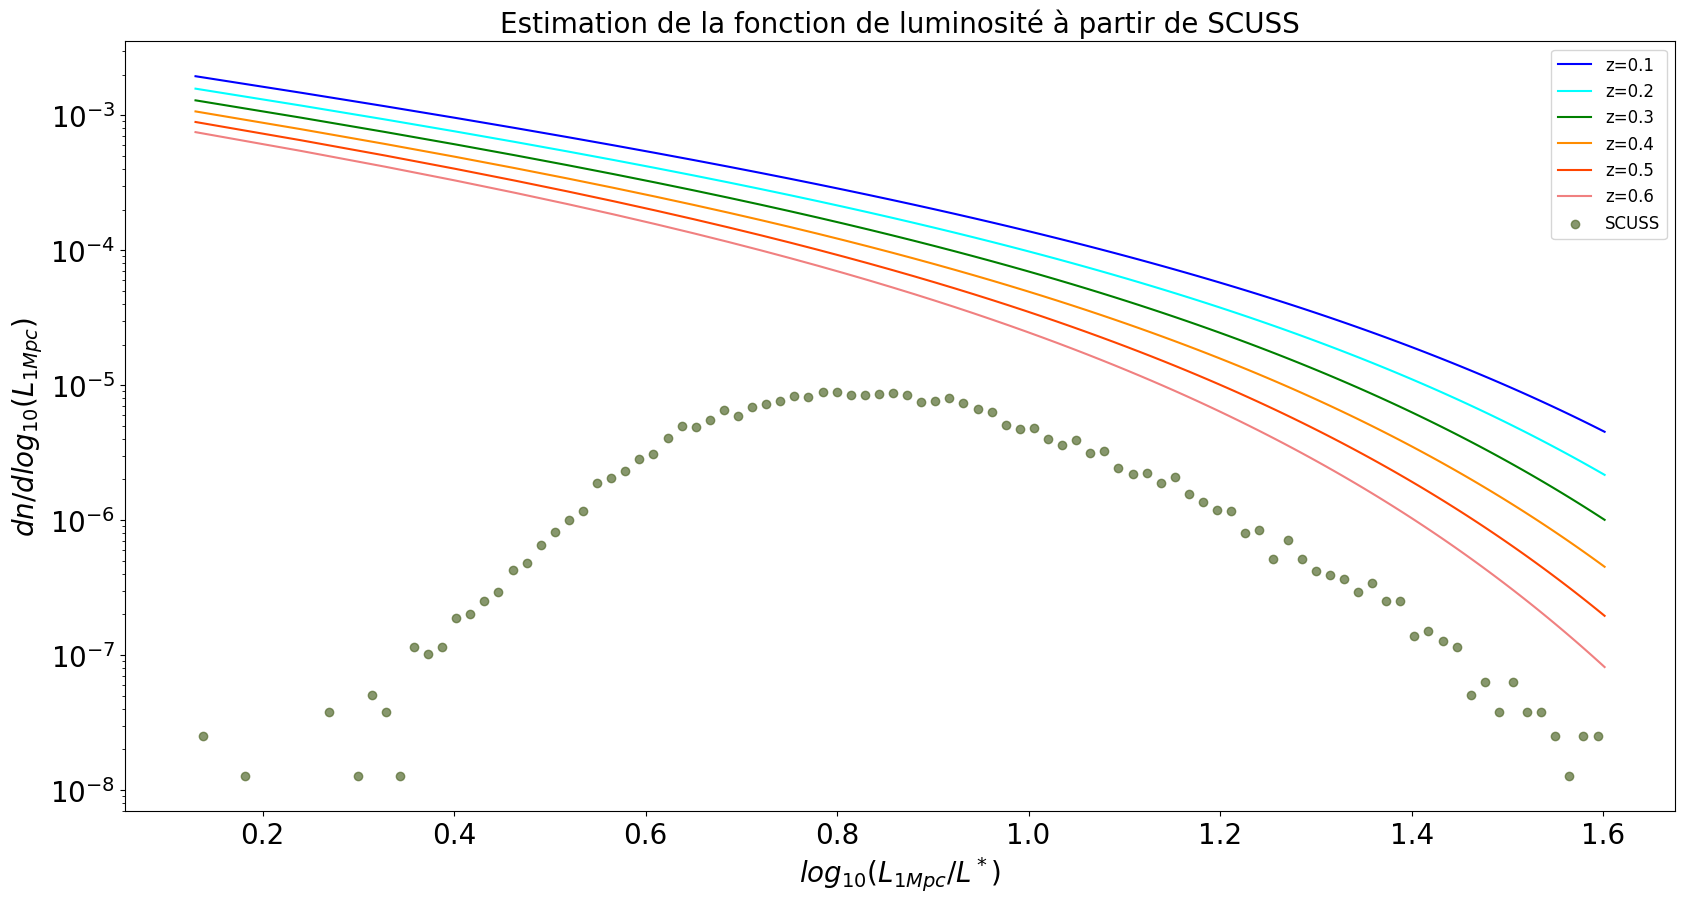

In [53]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(20,10))

for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i / (len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='darkolivegreen', label='SCUSS', alpha=0.7)

if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc}/L^*)$')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc}/L_{\odot})$')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)

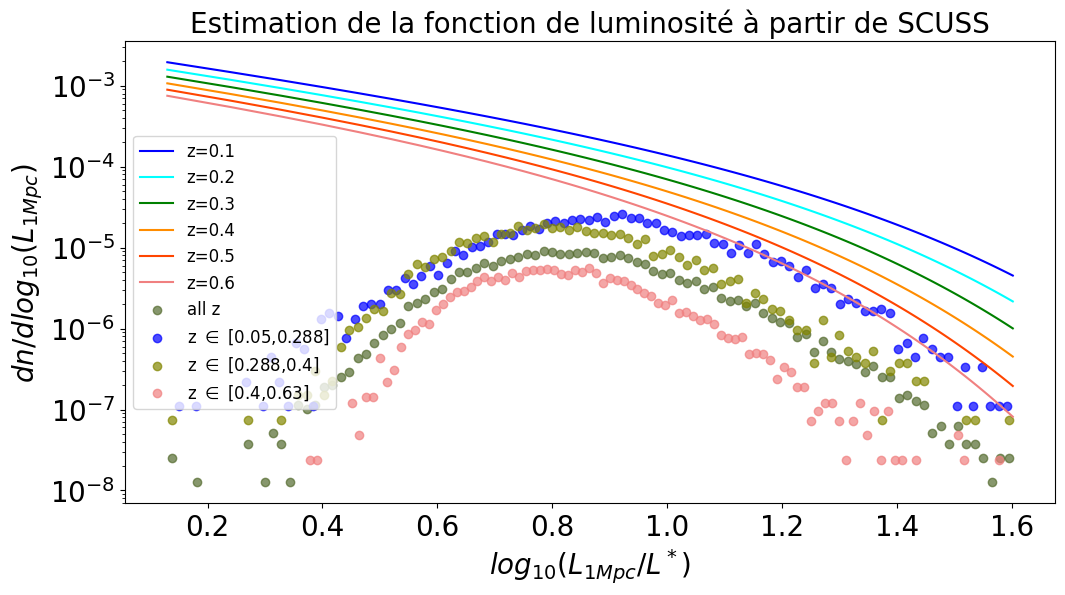

In [54]:
# On fait comme précedemment, mais en s'intéressant aux différents bins de redshift
fig2 = plt.figure(figsize=(12, 6))
#théorie
for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i / (len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='darkolivegreen', label='all z', alpha=0.7)
#données

for i,subtable in enumerate(subtables_z_SCUSS):
    if L == 'L*':
        L1MPC_subtable = subtable['L1Mpc']
        log10_L1MPC_subtable = np.log10(L1MPC_subtable)
    elif L == 'Lsun':
        log10_L1MPC_subtable = subtable['log10_L1Mpc_Lsun']
        
    volume_subtable = uf.Volume_survey(angular_area_SCUSS_deg2,[bornes_z_SCUSS[i],bornes_z_SCUSS[i+1]])

    bin_centers_log10_L1Mpc_subtable, counts_log10_L1Mpc_subtable, bin_width_SCUSS_L1Mpc_log10_subtable, n_SCUSS_log10_L1Mpc_subtable = uf.compute_histogram_density(log10_L1MPC_subtable,
                                                                                                                                                                  bins=100,
                                                                                                                                                                  volume=volume_subtable) 
                                                                                                                                                                  #On considère le voulme compris entre les bornes de redshift
    
    plt.scatter(bin_centers_log10_L1Mpc_subtable,
                n_SCUSS_log10_L1Mpc_subtable,
                label=fr'z $\in$ [{round(bornes_z_SCUSS[i],3)},{round(bornes_z_SCUSS[i+1],3)}]', 
                color=cmap_blue2red(i / (len(subtables_z_SCUSS) - 1)),
                alpha=0.7,
                )
if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc}/L^*)$')
elif L == 'Lsun':
    plt.xlabel(r'log_{10}(L_{1Mpc}/L_{\odot})')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)

#faire idem en Lapp

Pour le code ci-dessous, ajouter la commande magic "%matplotlib widget" pour rendre le graphe 3D interactif : attention cela fonctionnera pour tout les plots, on doit l'enlever de la cellule et restart le kernel pour revenir à la normale.\
(ne semble pas bien marcher sur Cursor)

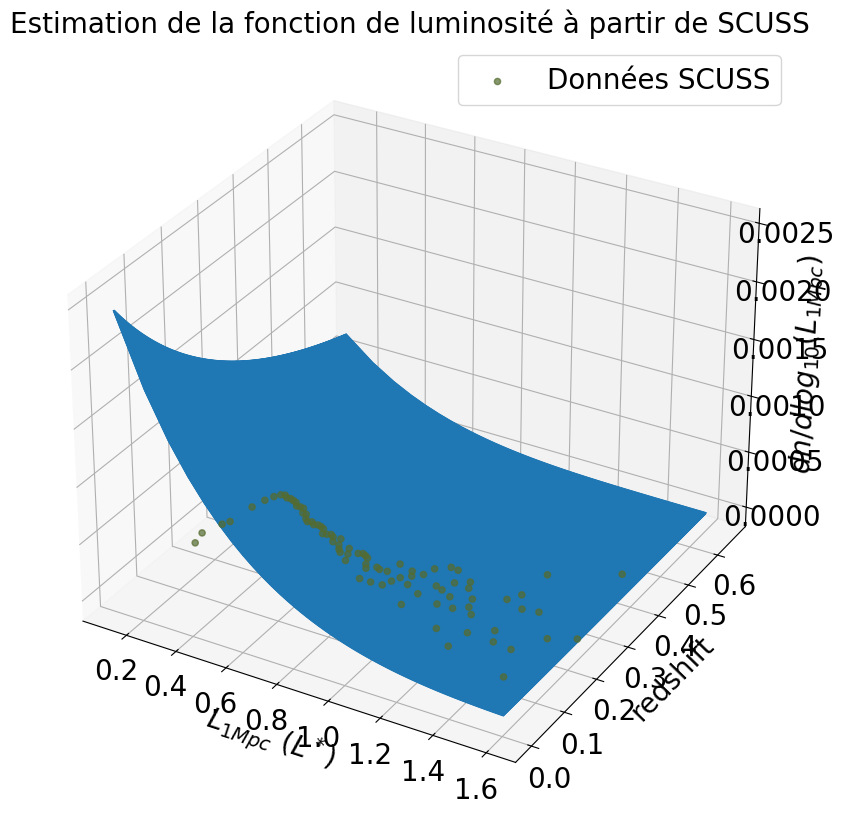

In [55]:
# Idem en 3D
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

for i, z in enumerate(array_z_3D): # On plot dn/dL1Mpc pour chaque redshift
    ax.plot(
        array_log10_L1Mpc_SCUSS,
        array_z_3D[i], # Pour le ième redshift de array_z_3D
        CLF_log10_MRP_GSR_3D[i], # idem
        color='tab:blue'
        #label="Courbes de la fonction de luminosité théorique tirée de la CMF MRP"
    )

ax.scatter(bin_centers_L1Mpc_log10, bins_mean_z, n_SCUSS_L1Mpc_log10, color='darkolivegreen', alpha=0.7, label='Données SCUSS') # !!! bins_mean_z → moyenne en z du bin

#ax.scatter(array_log10_L1Mpc_SCUSS, array_z_3D, CLF_log10_MRP_GSR_3D, cmap='viridis', marker='o')  # c=C pour colorer selon dn/d(log10(M/Msun))
# ajouter les points des données ; réduire l'axe des z à 100
'''
ax.set_zscale('log')
ax.set_zlim(1e-9, 1e-2)  # Adjust these values to fit your data'''

if L == 'L*':
    ax.set_xlabel(r'$L_{1Mpc}$ ($L^*$)')
elif L == 'Lsun':
    ax.set_xlabel(r'$L_{1Mpc}$ ($L_{\odot}$)')
ax.set_ylabel('redshift')
ax.set_zlabel(r'$dn / dlog_{10}(L_{1Mpc})$')
ax.legend()
plt.title('Estimation de la fonction de luminosité à partir de SCUSS')
plt.show()

In [56]:
table_SCUSS


,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,zph,zsp,zphmedian,N1Mpc,L1Mpc,Richness,M500,recno,z,z_bin,log10_L1Mpc_Lsun,L1Mpc_Lsun
0,0.00035,13.02347,0,0.00035,13.02347,0.3769,0.00000,0.38710,24,7.00224,22.90440,1.26,1,0.37690,1,11.053542,1.131208e+11
1,0.00635,2.95542,1,0.00635,2.95542,0.4571,0.42290,0.43890,17,6.56276,23.13604,1.27,2,0.42290,2,11.046736,1.113617e+11
2,0.00958,5.28826,2,0.00958,5.28826,0.1734,0.16936,0.17750,58,14.09044,35.83500,2.04,3,0.16936,0,11.260931,1.823607e+11
3,0.01474,31.78564,3,0.01474,31.78564,0.0824,0.00000,0.10490,64,12.95997,25.62747,1.42,4,0.08240,0,11.184261,1.528486e+11
4,0.01476,8.94881,4,0.01476,8.94881,0.2609,0.00000,0.27620,26,8.83946,24.11363,1.33,5,0.26090,0,11.100907,1.261558e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19605,359.97270,13.33689,19605,359.97270,13.33689,0.2360,0.24498,0.23050,24,6.31375,14.90396,0.79,19606,0.24498,0,10.947382,8.858942e+10
19606,359.98382,3.48642,19606,359.98382,3.48642,0.5132,0.00000,0.51320,20,8.83291,40.95954,2.35,19607,0.51320,2,11.217652,1.650640e+11
19607,359.98503,-3.43589,19607,359.98503,-3.43589,0.3251,0.00000,0.32065,26,8.59997,26.87073,1.49,19608,0.32510,1,11.118767,1.314520e+11
19608,359.98757,8.56171,19608,359.98757,8.56171,0.3556,0.00000,0.37079,14,3.79424,9.74870,0.50,19609,0.35560,1,10.777547,5.991657e+10


#### Luminosité apparente

##### Calculs

In [57]:
# Add apparent luminosity column to main table
if L == 'L*':
    table_SCUSS = uf.add_apparent_luminosity(
        df=table_SCUSS,
        Labs_col='L1Mpc',
        z_col='z',
        cosmo=cosmo,
        new_col='Lapp'
    )
elif L == 'Lsun':
    table_SCUSS = uf.add_apparent_luminosity(
    df=table_SCUSS,
    Labs_col='L1Mpc_Lsun',
    z_col='z',
    cosmo=cosmo,
    new_col='Lapp'
)


# Calculate log10 of apparent luminosity
log10_Lapp_SCUSS = np.log10(table_SCUSS['Lapp'])

# Add apparent luminosity to each subtable
if L == 'L*':
    subtables_z_SCUSS = [
        uf.add_apparent_luminosity(
            df=subtable,
            Labs_col='L1Mpc',
            z_col='z',
            cosmo=cosmo,
            new_col='Lapp'
        )
        for subtable in subtables_z_SCUSS
    ]
elif L == 'Lsun':
    subtables_z_SCUSS = [
        uf.add_apparent_luminosity(
            df=subtable,
            Labs_col='L1Mpc_Lsun',
            z_col='z',
            cosmo=cosmo,
            new_col='Lapp'
        )
        for subtable in subtables_z_SCUSS
    ]

bin_centers_Lapp_log10, counts_Lapp_log10, bin_width_SCUSS_Lapp_log10, n_SCUSS_Lapp_log10 = uf.compute_histogram_density(log10_Lapp_SCUSS, bins=100, volume=volume_SCUSS)
print("Bin width L1Mpc:", bin_width_SCUSS_Lapp_log10)

Bin width L1Mpc: 0.0312821264112344


##### Tracés

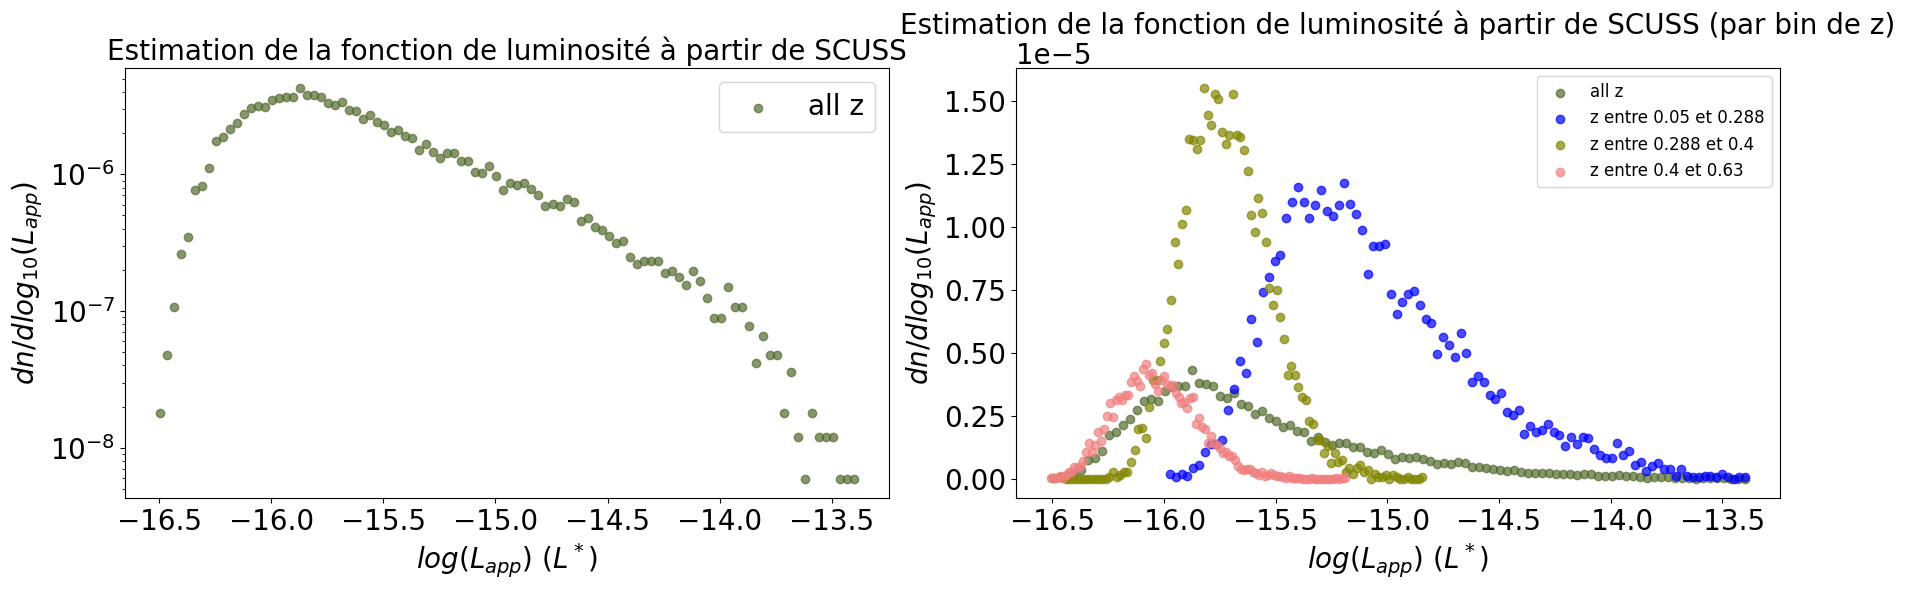

In [58]:
'''# log10(Lapp)
plt.figure(figsize=(12, 6))
plt.hist(log10_Lapp_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{app})$ ($L^*$)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title(r'Histogramme des luminosités apparentes "$log_{10}(L_{app})$" des amas dans SCUSS')'''

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: All z
ax = axes[0]
ax.scatter(bin_centers_Lapp_log10, n_SCUSS_Lapp_log10, color='darkolivegreen', alpha=0.7)
#ax.set_ylim(0.5*1e-8,1e-5) # Bizarremment sans ça le plot n'affiche pas tout les points
if L == 'L*':
    ax.set_xlabel(r'$log(L_{app})$ ($L^*$)')
    ax.set_yscale('log')
elif L == 'Lsun':
    ax.set_xlabel(r'$log(L_{app)}$ ($L_{\odot}$)')
ax.set_ylabel(r'$dn / dlog_{10}(L_{app})$')
ax.set_title(r'Estimation de la fonction de luminosité à partir de SCUSS')
ax.legend(['all z'])

# Subplot 2: Par bin de z
ax2 = axes[1]
ax2.scatter(bin_centers_Lapp_log10, n_SCUSS_Lapp_log10, color='darkolivegreen', label='all z', alpha=0.7)
for i, subtable in enumerate(subtables_z_SCUSS):
    Lapp_subtable = subtable['Lapp']
    log10_Lapp_subtable = np.log10(Lapp_subtable)  
    volume_subtable = uf.Volume_survey(angular_area_SCUSS_deg2, [bornes_z_SCUSS[i], bornes_z_SCUSS[i+1]])
    bin_centers_log10_Lapp_subtable, counts_log10_Lapp_subtable, bin_width_SCUSS_Lapp_log10, n_SCUSS_log10_Lapp_subtable = uf.compute_histogram_density(
        log10_Lapp_subtable, bins=100, volume=volume_subtable
    )
    ax2.scatter(
        bin_centers_log10_Lapp_subtable,
        n_SCUSS_log10_Lapp_subtable,
        label=f'z entre {round(bornes_z_SCUSS[i],3)} et {round(bornes_z_SCUSS[i+1],3)}',
        color=cmap_blue2red(i / (len(subtables_z_SCUSS) - 1)),
        alpha=0.7,
    )
if L == 'L*':
    ax2.set_xlabel(r'$log(L_{app})$ ($L^*$)')
elif L == 'Lsun':
    ax2.set_xlabel(r'$log(L_{app})$ ($L_{\odot}$)')
    ax2.set_yscale('log')
ax2.set_ylabel(r'$dn / dlog_{10}(L_{app})$')
#ax2.set_ylim(0.5*1e-8,1e-5) # Bizarremment sans ça le plot n'affiche pas tout les points
ax2.set_title(r'Estimation de la fonction de luminosité à partir de SCUSS (par bin de z)')
ax2.legend(fontsize=12)

plt.tight_layout()

### Coupure L_app

#### Récupération / Calculs valeurs

In [59]:
# A partir de dn/dlog10(Lapp) ci-dessus, on en déduit une coupure minimale de détection de cette survey en Lapp
log10_Lapp_min = -15 ; L_app_min = 10**log10_Lapp_min # A CHOISIR : ATTENTION NE PAS CONFONDRE SI L_sun ou L*
log10_Lapp_min_2 = -14.5 ; L_app_min_2 = 10**log10_Lapp_min_2 # A CHOISIR : ATTENTION NE PAS CONFONDRE SI L_sun ou L*


# Maintenant on va calculer la coupure en redshift associé à celle en luminosité apparente pour chaque bin de log10(L1mpc)
arg_inv_lum_dist = 10 * np.sqrt((10**bin_centers_L1Mpc_log10) / (L_app_min)) # Homogène à une distance lumineuse en pc
arg_inv_lum_dist_2 = 10 * np.sqrt((10**bin_centers_L1Mpc_log10) / (L_app_min_2)) 
inverse_DL = uf.inverse_luminosity_distance([0.05,10,200000]) # Fonction inverse de la distance lumineuse ; !!! Attention le choix du range de z est important ! → le faire assez large
# pour que que la fonction puisse fournir un résultat (et non un nan) même pour des valuers de distances lumineuses élevées
# coupure en redshift associée à la coupure en luminosité apparente
z_max = inverse_DL(arg_inv_lum_dist) ; z_max = np.where(z_max > 0.65, 0.65, z_max) # On met à e = 0.65 car c'est le maximum de détection du relevé SCUSS/SDSS/unWISE de Gao et al. 2020
z_max_2 = inverse_DL(arg_inv_lum_dist_2) ; z_max_2 = np.where(z_max_2 > 0.65, 0.65, z_max_2)


z_max_old = uf.inverse_luminosity_distance_old(arg_inv_lum_dist) ; z_max_old = np.where(z_max_old > 0.65, 0.65, z_max_old)

bornes_z_cut_SCUSS = [0.05, z_max] 
volume_SCUSS_cut = uf.Volume_survey_array(angular_area_SCUSS_deg2,bornes_z_cut_SCUSS)

bornes_z_cut_SCUSS_2 = [0.05, z_max_2]
volume_SCUSS_cut_2 = uf.Volume_survey_array(angular_area_SCUSS_deg2,bornes_z_cut_SCUSS_2)

# On recalcule la densité maintenant par bin de L1Mpc maintenant qu'on dispose du volume d'observation pour chaque bin
n_SCUSS_L1Mpc_log10_cut = []
for i in range(len(bin_centers_L1Mpc_log10)):
    current_n_SCUSS_L1Mpc_log10 = (counts_L1Mpc_log10[i]/bin_width_SCUSS_L1Mpc_log10)/volume_SCUSS_cut[i]
    n_SCUSS_L1Mpc_log10_cut.append(current_n_SCUSS_L1Mpc_log10)

#### Tracés

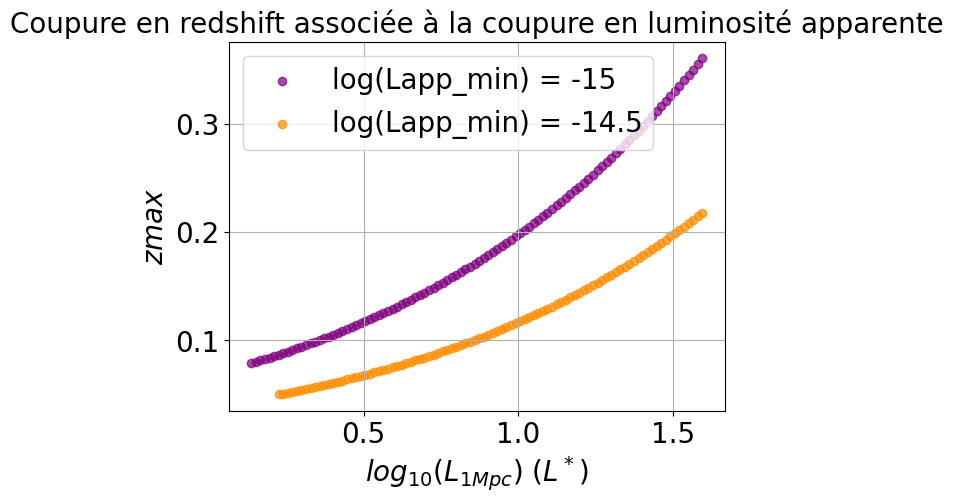

In [60]:
plt.scatter(bin_centers_L1Mpc_log10, z_max, color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
#plt.scatter(bin_centers_L1Mpc_log10, z_max_old, color='brown',label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, z_max_2, color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}', alpha=0.7)
if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'$z{max}$')
plt.title(f'Coupure en redshift associée à la coupure en luminosité apparente')
plt.grid(True)
plt.legend()


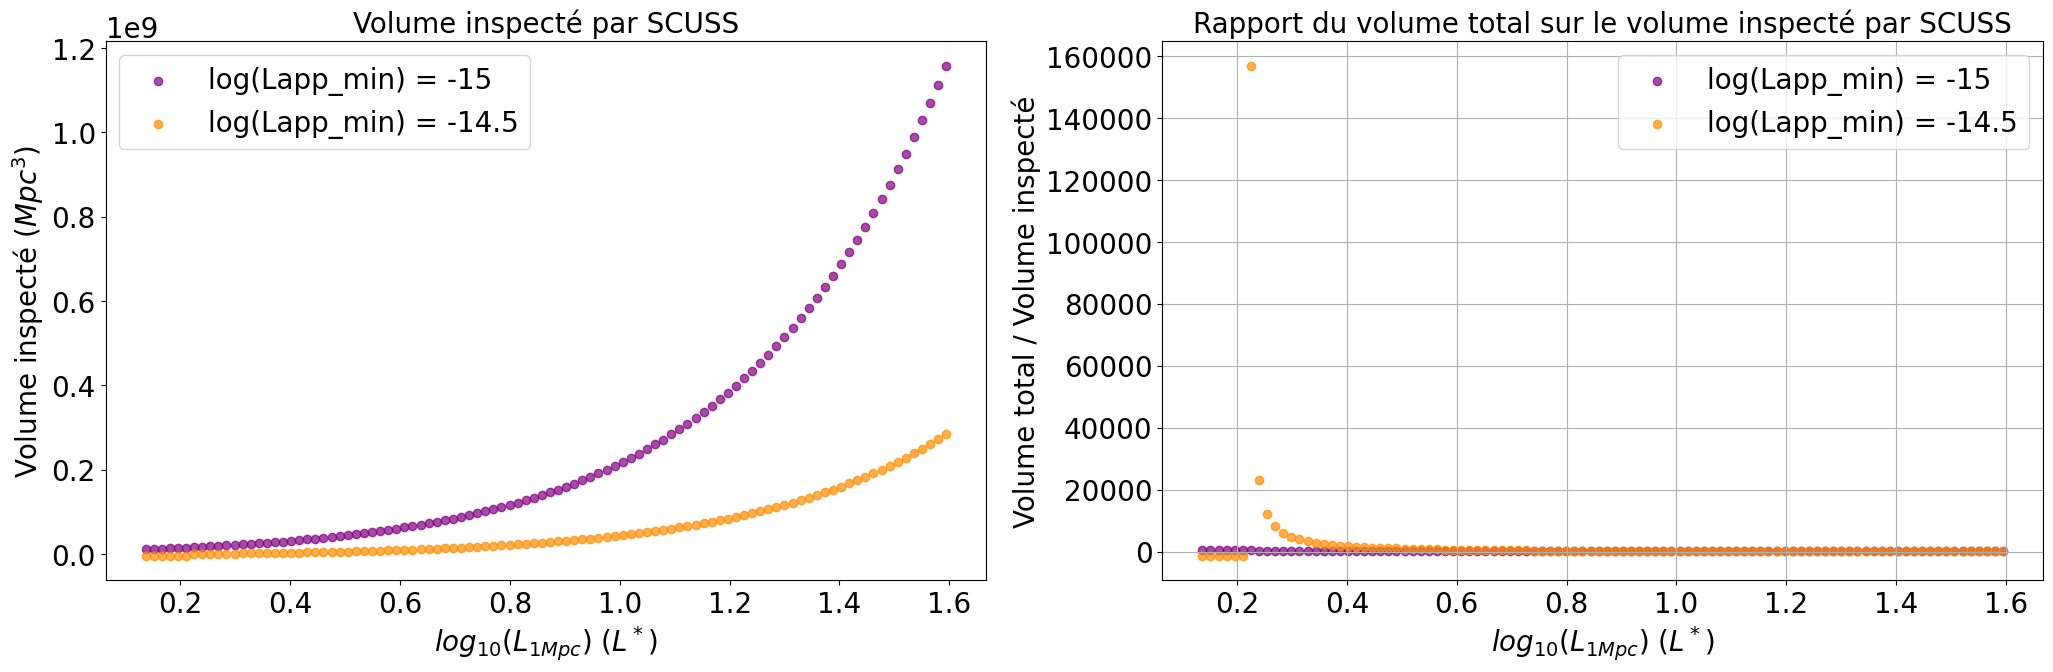

In [61]:
fig1 = plt.figure(figsize=(25, 7))

plt.subplot(121)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS_cut, color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}',alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS_cut_2, color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}',alpha=0.7)
if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'Volume inspecté $(Mpc^3)$')
plt.title(f'Volume inspecté par SCUSS')
plt.legend()

plt.subplot(122)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS/np.array(volume_SCUSS_cut), color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}',alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS/np.array(volume_SCUSS_cut_2), color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}',alpha=0.7)
if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'Volume total / Volume inspecté')
plt.title(f'Rapport du volume total sur le volume inspecté par SCUSS')

plt.grid(True)
plt.legend()

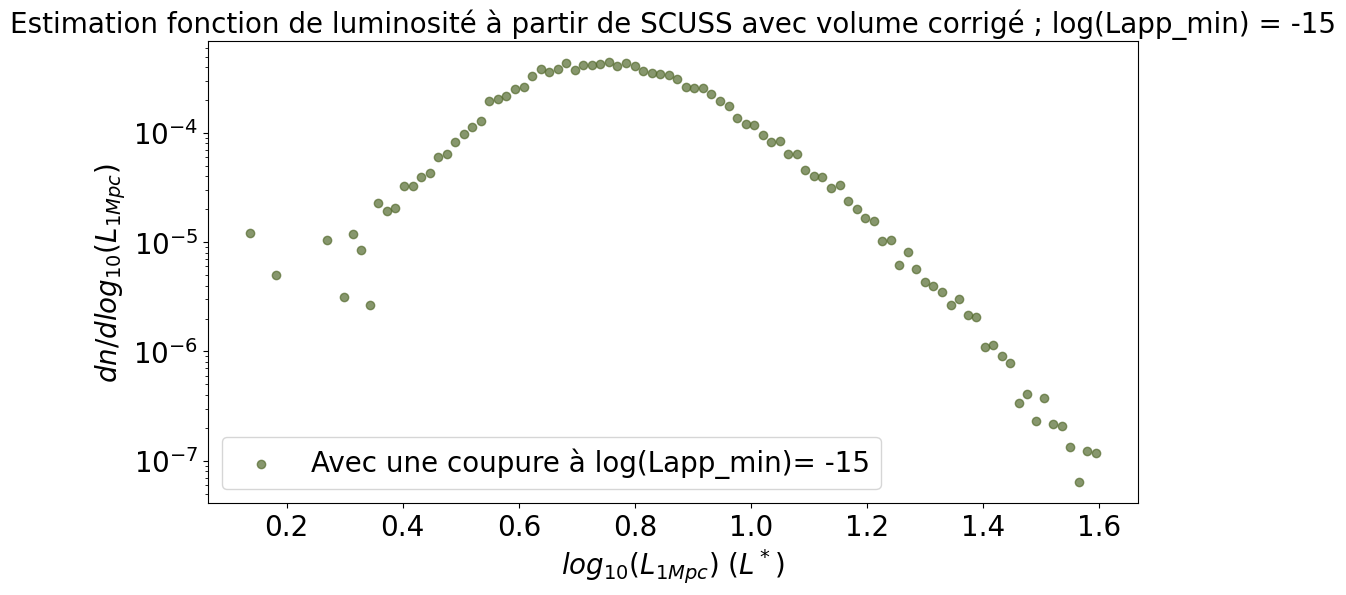

In [62]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label= f'Avec une coupure à log(Lapp_min)= {log10_Lapp_min}', alpha=0.7) 
#plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='red', label='Sans coupure')

if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()

rapport des aires sous les deux courbes (avec coupure / sans coupure) =  45.98715031191071


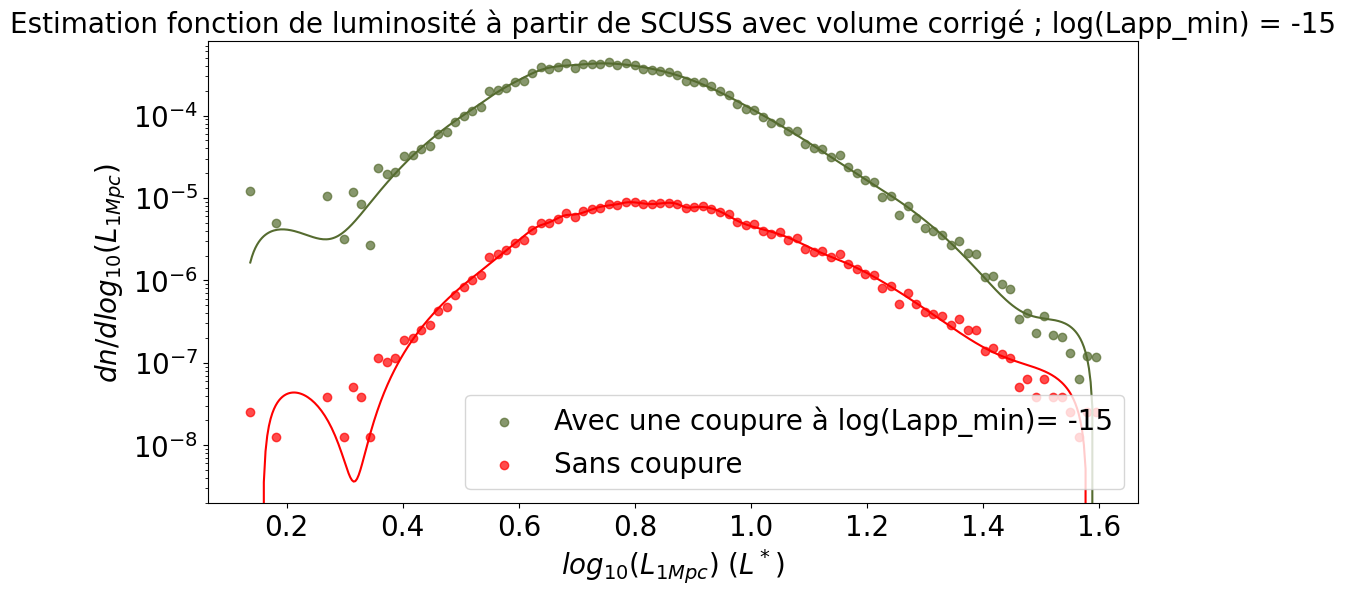

In [63]:
# Calcul du rapport des aires sous les deux courbes (non corrigée et corrigée)

# On obtient chacun des smoothong factor 's' par tatônnements
CLF_avec_coupure = UnivariateSpline(bin_centers_L1Mpc_log10,n_SCUSS_L1Mpc_log10_cut,s=9e-9)
CLF_sans_coupure = UnivariateSpline(bin_centers_L1Mpc_log10,n_SCUSS_L1Mpc_log10,s=2e-12)


range_log10_L1Mpc = np.linspace(bin_centers_L1Mpc_log10[0],bin_centers_L1Mpc_log10[-1],500)
n_SCUSS_L1Mpc_log10_cut_interp = CLF_avec_coupure(range_log10_L1Mpc)
n_SCUSS_L1Mpc_log10_interp = CLF_sans_coupure(range_log10_L1Mpc)


fig = plt.figure(figsize=(12,6))

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label= f'Avec une coupure à log(Lapp_min)= {log10_Lapp_min}', alpha=0.7) 
plt.plot(range_log10_L1Mpc, n_SCUSS_L1Mpc_log10_cut_interp, color='darkolivegreen')

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='red', label='Sans coupure', alpha=0.7)
plt.plot(range_log10_L1Mpc, n_SCUSS_L1Mpc_log10_interp, color='red')


if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()


integrale_cut = integrate.quad(CLF_avec_coupure, bin_centers_L1Mpc_log10[0], bin_centers_L1Mpc_log10[-1])
integrale_sans_cut = integrate.quad(CLF_sans_coupure, bin_centers_L1Mpc_log10[0], bin_centers_L1Mpc_log10[-1])
rapport_integrales = integrale_cut[0]/integrale_sans_cut[0]
print('rapport des aires sous les deux courbes (avec coupure / sans coupure) = ',rapport_integrales)
# On va utiliser ce rapport pour multiplier les données et vérifier ansi le "tilt" à basses luminosités dû à la coupure

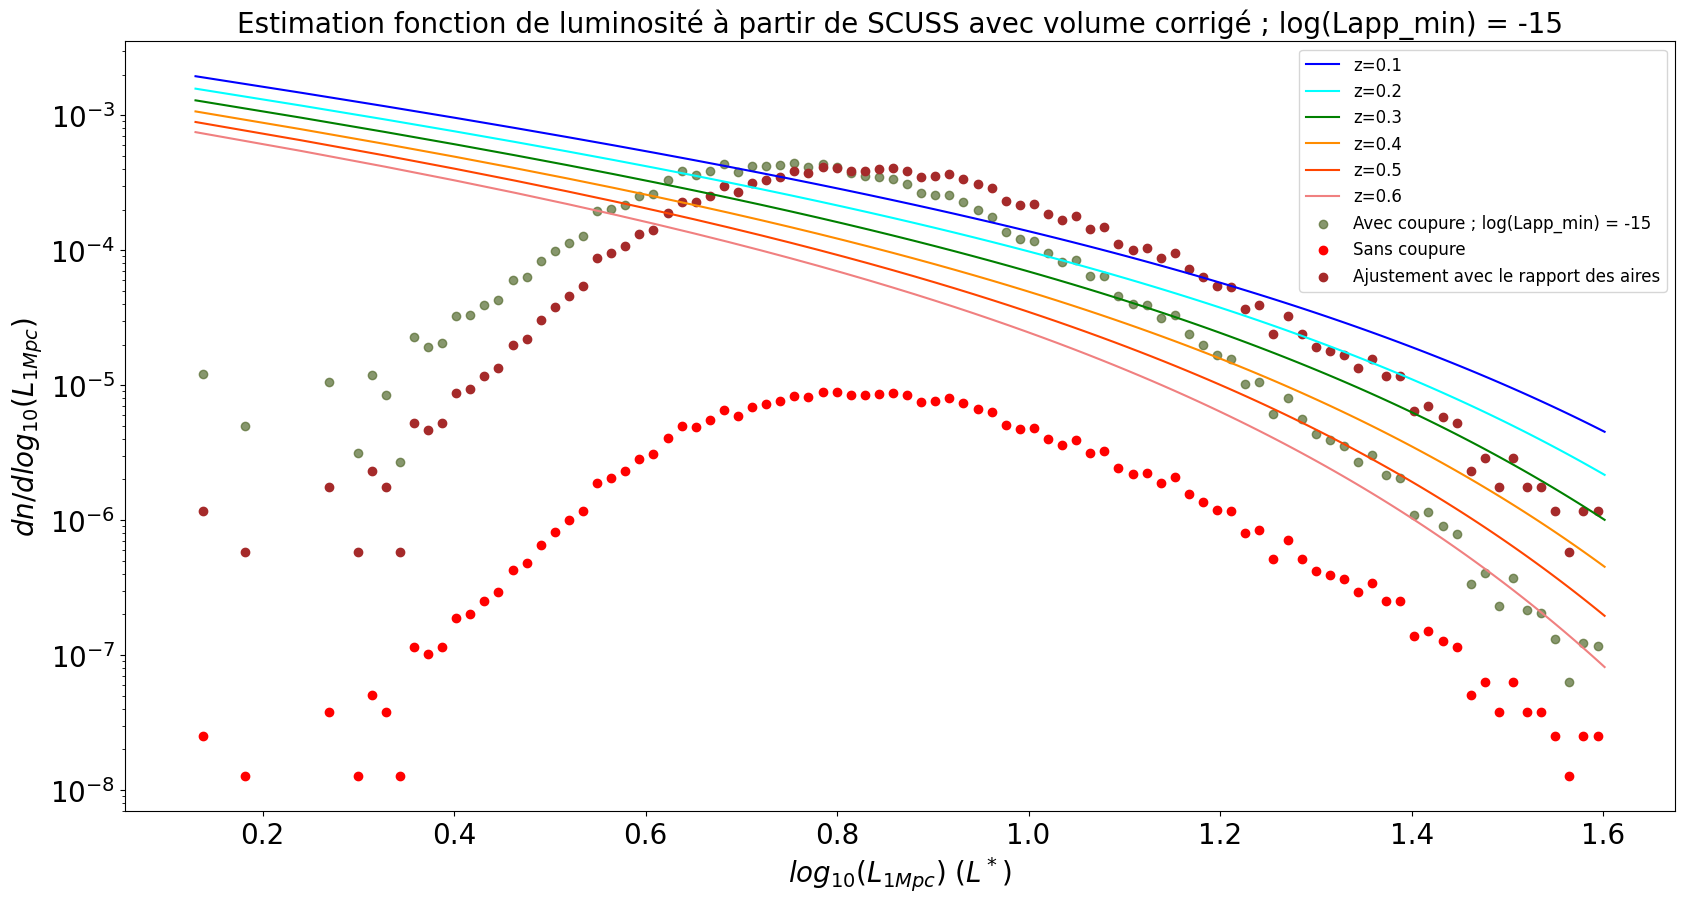

In [64]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(20,10))

#cmap = plt.get_cmap('tab10') # Matplotlib's collection of predefined colormaps
for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i/(len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label=f'Avec coupure ; log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='red', label='Sans coupure')
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10*rapport_integrales, color='brown', label='Ajustement avec le rapport des aires')



if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend(fontsize=12)

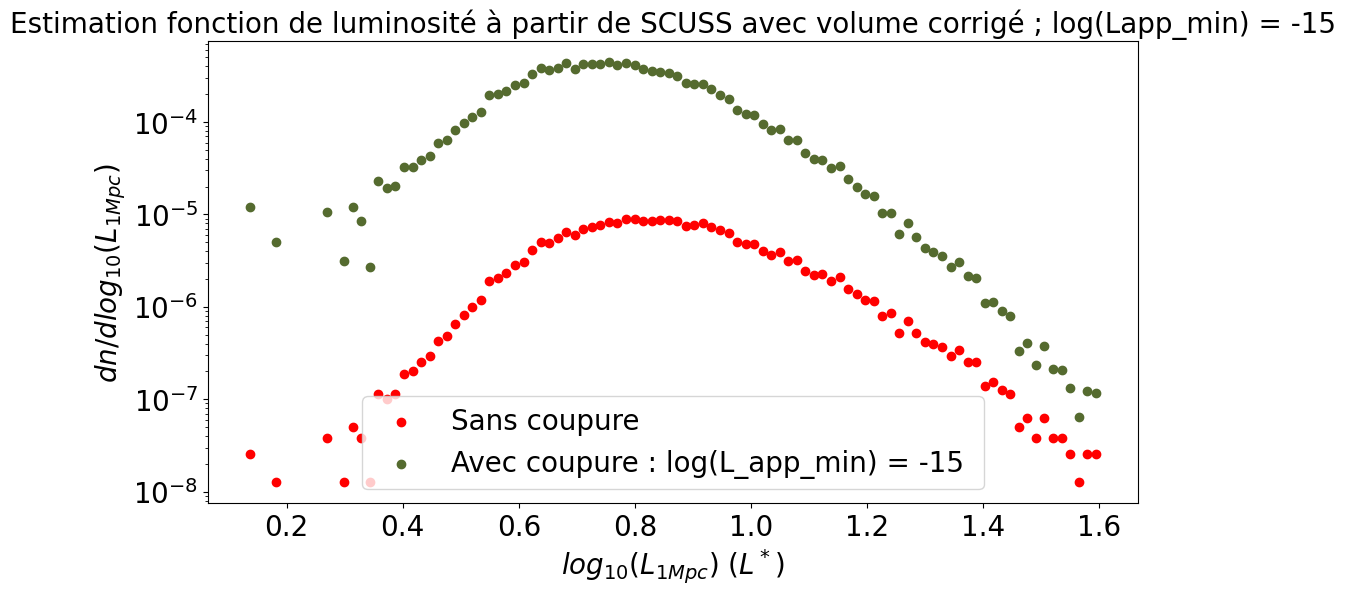

In [65]:
# Comparaison avec et sans coupure

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='red', label='Sans coupure')
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label=f'Avec coupure : log(L_app_min) = {round(log10_Lapp_min,3)} ')
if L == 'L*':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
elif L == 'Lsun':
    plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L_{\odot}$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()

## eRASS1

### Calculs prélims

In [66]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen

table_eRASS1 = uf.fits_to_dataframe(path_eRASS1)
print(volume_eRASS1)
nb_bins_z = 3 ; nb_bornes_z = nb_bins_z + 1 

range_M500 = (12.7, 15.5) # Range de M500 pour le calcul des histogrammes (rappel : les bornes de validité de la CMF MRP (en log10(M/Msun)) sont (12.7, 15.5))

93266525004.19017


In [67]:
# On crée plusieurs subsamples de la table eRASS1 en fonction des bornes de z

# Largeur en z identiques - nombre d'éléments différents

bornes_z_eRASS1 = np.linspace(0,np.max(table_eRASS1['zBest']),nb_bornes_z) # On va faire plusieurs tracés en fonction de plusieurs redshifts (n bins de z issus des n+1 bornes de z)
subtables_z_eRASS1 = []
for i in range(len(bornes_z_eRASS1)-1):
    subtable = table_eRASS1[(table_eRASS1['zBest'] >= bornes_z_eRASS1[i]) & (table_eRASS1['zBest'] <= bornes_z_eRASS1[i+1])]
    print(f'bin {i} : z allant de {round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}')
    subtables_z_eRASS1.append(subtable)

M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
M500_eRASS1 = M500_eRASS1[(M500_eRASS1 > 12.7) & (M500_eRASS1 < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

M500_eRASS1_sub_z = [] # shape : nb_bins_z * nb_elements_par_bin
Volume_eRASS1_sub_z = [] # shape : nb_bins_z
for i,subtable in enumerate(subtables_z_eRASS1):
    # conversion et filtrage de l'ensemble des masses de chaque bin de z
    M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
    M500_sub = M500_sub[(M500_sub > 12.7) & (M500_sub < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF
    M500_eRASS1_sub_z.append(M500_sub)
    volume_subtable = uf.Volume_survey(angular_area_eRASS1_deg2,[bornes_z_eRASS1[i],bornes_z_eRASS1[i+1]]) # On calcule le volume inspecté dans le bin de z actuel
    Volume_eRASS1_sub_z.append(volume_subtable)
    





# Largeur en z différentes - même nombre d'éléments

# Create quantile-based bins for 'zBest'
table_eRASS1['z_bin'], bornes_z_eRASS1_2 = pd.qcut(table_eRASS1['zBest'], q=nb_bins_z, retbins=True, labels=False)

# Create subtables for each bin
subtables_z_eRASS1_2 = []
for i in range(nb_bins_z):
    subtable = table_eRASS1[table_eRASS1['z_bin'] == i]
    volume_subtable = uf.Volume_survey(angular_area_eRASS1_deg2,[bornes_z_eRASS1_2[i],bornes_z_eRASS1_2[i+1]]) # On calcule le volume inspecté dans le bin de z actuel
    subtable['Volume'] = volume_subtable
    print(f'bin {i}: z from {round(bornes_z_eRASS1_2[i],3)} to {round(bornes_z_eRASS1_2[i+1],3)}, count={len(subtable)}')
    subtables_z_eRASS1_2.append(subtable)

M500_eRASS1_sub_z_2 = [] # shape : nb_bins_z * nb_elements_par_bin
Volume_eRASS1_sub_z_2 = [] # shape : nb_bins_z
for i,subtable in enumerate(subtables_z_eRASS1_2):
    M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
    M500_sub = M500_sub[(M500_sub > 12.7) & (M500_sub < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF
    M500_eRASS1_sub_z_2.append(M500_sub)

    volume_subtable = uf.Volume_survey(angular_area_eRASS1_deg2,[bornes_z_eRASS1_2[i],bornes_z_eRASS1_2[i+1]]) # On calcule le volume inspecté dans le bin de z actuel
    Volume_eRASS1_sub_z_2.append(volume_subtable)

bin 0 : z allant de 0.0 à 0.441
bin 1 : z allant de 0.441 à 0.881
bin 2 : z allant de 0.881 à 1.322
bin 0: z from 0.003 to 0.212, count=4083
bin 1: z from 0.212 to 0.425, count=4081
bin 2: z from 0.425 to 1.322, count=4083


C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\698088551.py:12: RuntimeWarning: divide by zero encountered in log10
  M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\698088551.py:19: RuntimeWarning: divide by zero encountered in log10
  M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\698088551.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtable['Volume'] = volume_subtable
C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\698088551.py:40: SettingWithCopyWarning: 
A value is trying to be set o

In [68]:
uf.Volume_survey(angular_area_eRASS1_deg2,[bornes_z_eRASS1_2[0],bornes_z_eRASS1_2[0+1]])

np.float64(938358224.7234741)

In [69]:
uf.Volume_survey(angular_area_eRASS1_deg2,[bornes_z_eRASS1_2[1],bornes_z_eRASS1_2[1+1]])

np.float64(5482570504.275869)

In [70]:
nb_bins_histos_ERASS1 = 40 #nb de bins de masse pour les prochains histogrammes

In [71]:
# Calcul estimation de la fonction de masse à partir de eRASS1 ; calculs des erreurs poissoniennes

bin_centers, counts_eRASS1, bin_width_eRASS1, n_eRASS1 = uf.compute_histogram_density(M500_eRASS1,
                                                                                    bins=nb_bins_histos_ERASS1,
                                                                                    range=range_M500,
                                                                                    volume=volume_eRASS1)

#Estimation des erreurs poissoniennes
total = np.sum(counts_eRASS1)
errors_poisson_eRASS1 = np.sqrt(counts_eRASS1)
norm_counts_eRASS1 = counts_eRASS1 / (total * bin_width_eRASS1) ; errors_poisson_eRASS1_normalized = np.sqrt(counts_eRASS1) / (total * bin_width_eRASS1)

In [72]:
len(M500_eRASS1_sub_z)

3

In [73]:
# Process histograms for each redshift bin
results = uf.process_subtables_histogram(
    subtables=M500_eRASS1_sub_z,  # List of mass arrays for each z bin
    column=None,  # Not needed since we're passing arrays directly
    bins=nb_bins_histos_ERASS1,
    range=range_M500,
    volume= Volume_eRASS1_sub_z,
    label_prefix='z=',
    color_map=lambda x: cmap_blue2red(x)
)

# Extract results into separate lists for compatibility with existing code
bin_centers_eRASS1_sub_z = [r['bin_centers'] for r in results]
counts_eRASS1_sub_z = [r['counts'] for r in results]
norm_counts_eRASS1_sub_z = [r['norm_counts'] for r in results]
n_eRASS1_sub_z = [r['density'] for r in results]
errors_poisson_eRASS1_sub_z = [r['errors'] for r in results]
errors_poisson_eRASS1_normalized_sub_z = [r['norm_errors'] for r in results]

# ATTENTION : On diminue fortement le nombre d'amas dans les bins de z plus grand, donc les stats sont moins fiables !



In [74]:
# Largeur en z différentes - même nombre d'éléments


# Utilisation de process_subtables_histogram pour calculer les mêmes quantités d'intérêt que précédemment

results_2 = uf.process_subtables_histogram(
    subtables=M500_eRASS1_sub_z_2,  # List of mass arrays for each z bin (largeur en z différentes)
    column=None,  # Not needed since we're passing arrays directly
    bins=nb_bins_histos_ERASS1,
    range=range_M500,
    volume=Volume_eRASS1_sub_z_2,
    label_prefix='z=',
    color_map=lambda x: cmap_blue2red(x)
)

# Extraction des résultats dans des listes séparées pour compatibilité avec le code existant
bin_centers_eRASS1_sub_z_2 = [r['bin_centers'] for r in results_2]
counts_eRASS1_sub_z_2 = [r['counts'] for r in results_2]
norm_counts_eRASS1_sub_z_2 = [r['norm_counts'] for r in results_2]
n_eRASS1_sub_z_2 = [r['density'] for r in results_2]
errors_poisson_eRASS1_sub_z_2 = [r['errors'] for r in results_2]
errors_poisson_eRASS1_normalized_sub_z_2 = [r['norm_errors'] for r in results_2]

# ATTENTION : On diminue fortement le nombre d'amas dans les bins de z plus grand, donc les stats sont moins fiables !

### Affichage histos masse (potentiellement à raccourcir)

In [75]:
nb_bins_histo = 40

Moyenne de la masse des amas est de  14.248  et l'écart type de  0.364  pour eRASS1
Moyenne de la masse des amas est de  14.18  et l'écart type de  0.391  pour eRASS1 pour des z allant de 0.0 à 0.441
Moyenne de la masse des amas est de  14.413  et l'écart type de  0.215  pour eRASS1 pour des z allant de 0.441 à 0.881
Moyenne de la masse des amas est de  14.403  et l'écart type de  0.159  pour eRASS1 pour des z allant de 0.881 à 1.322


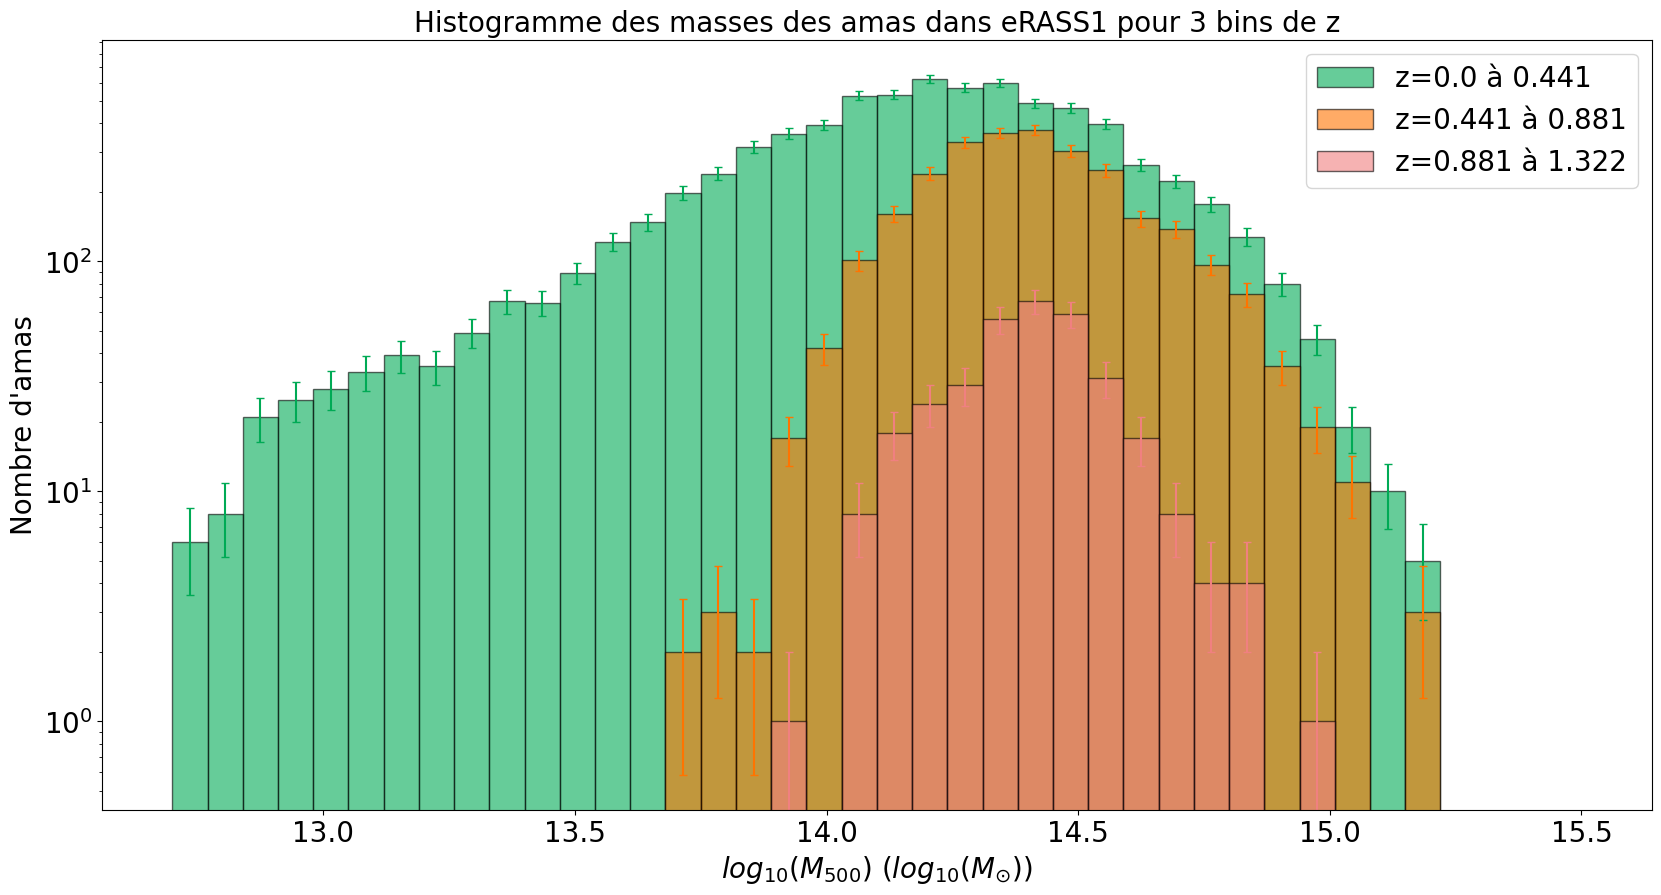

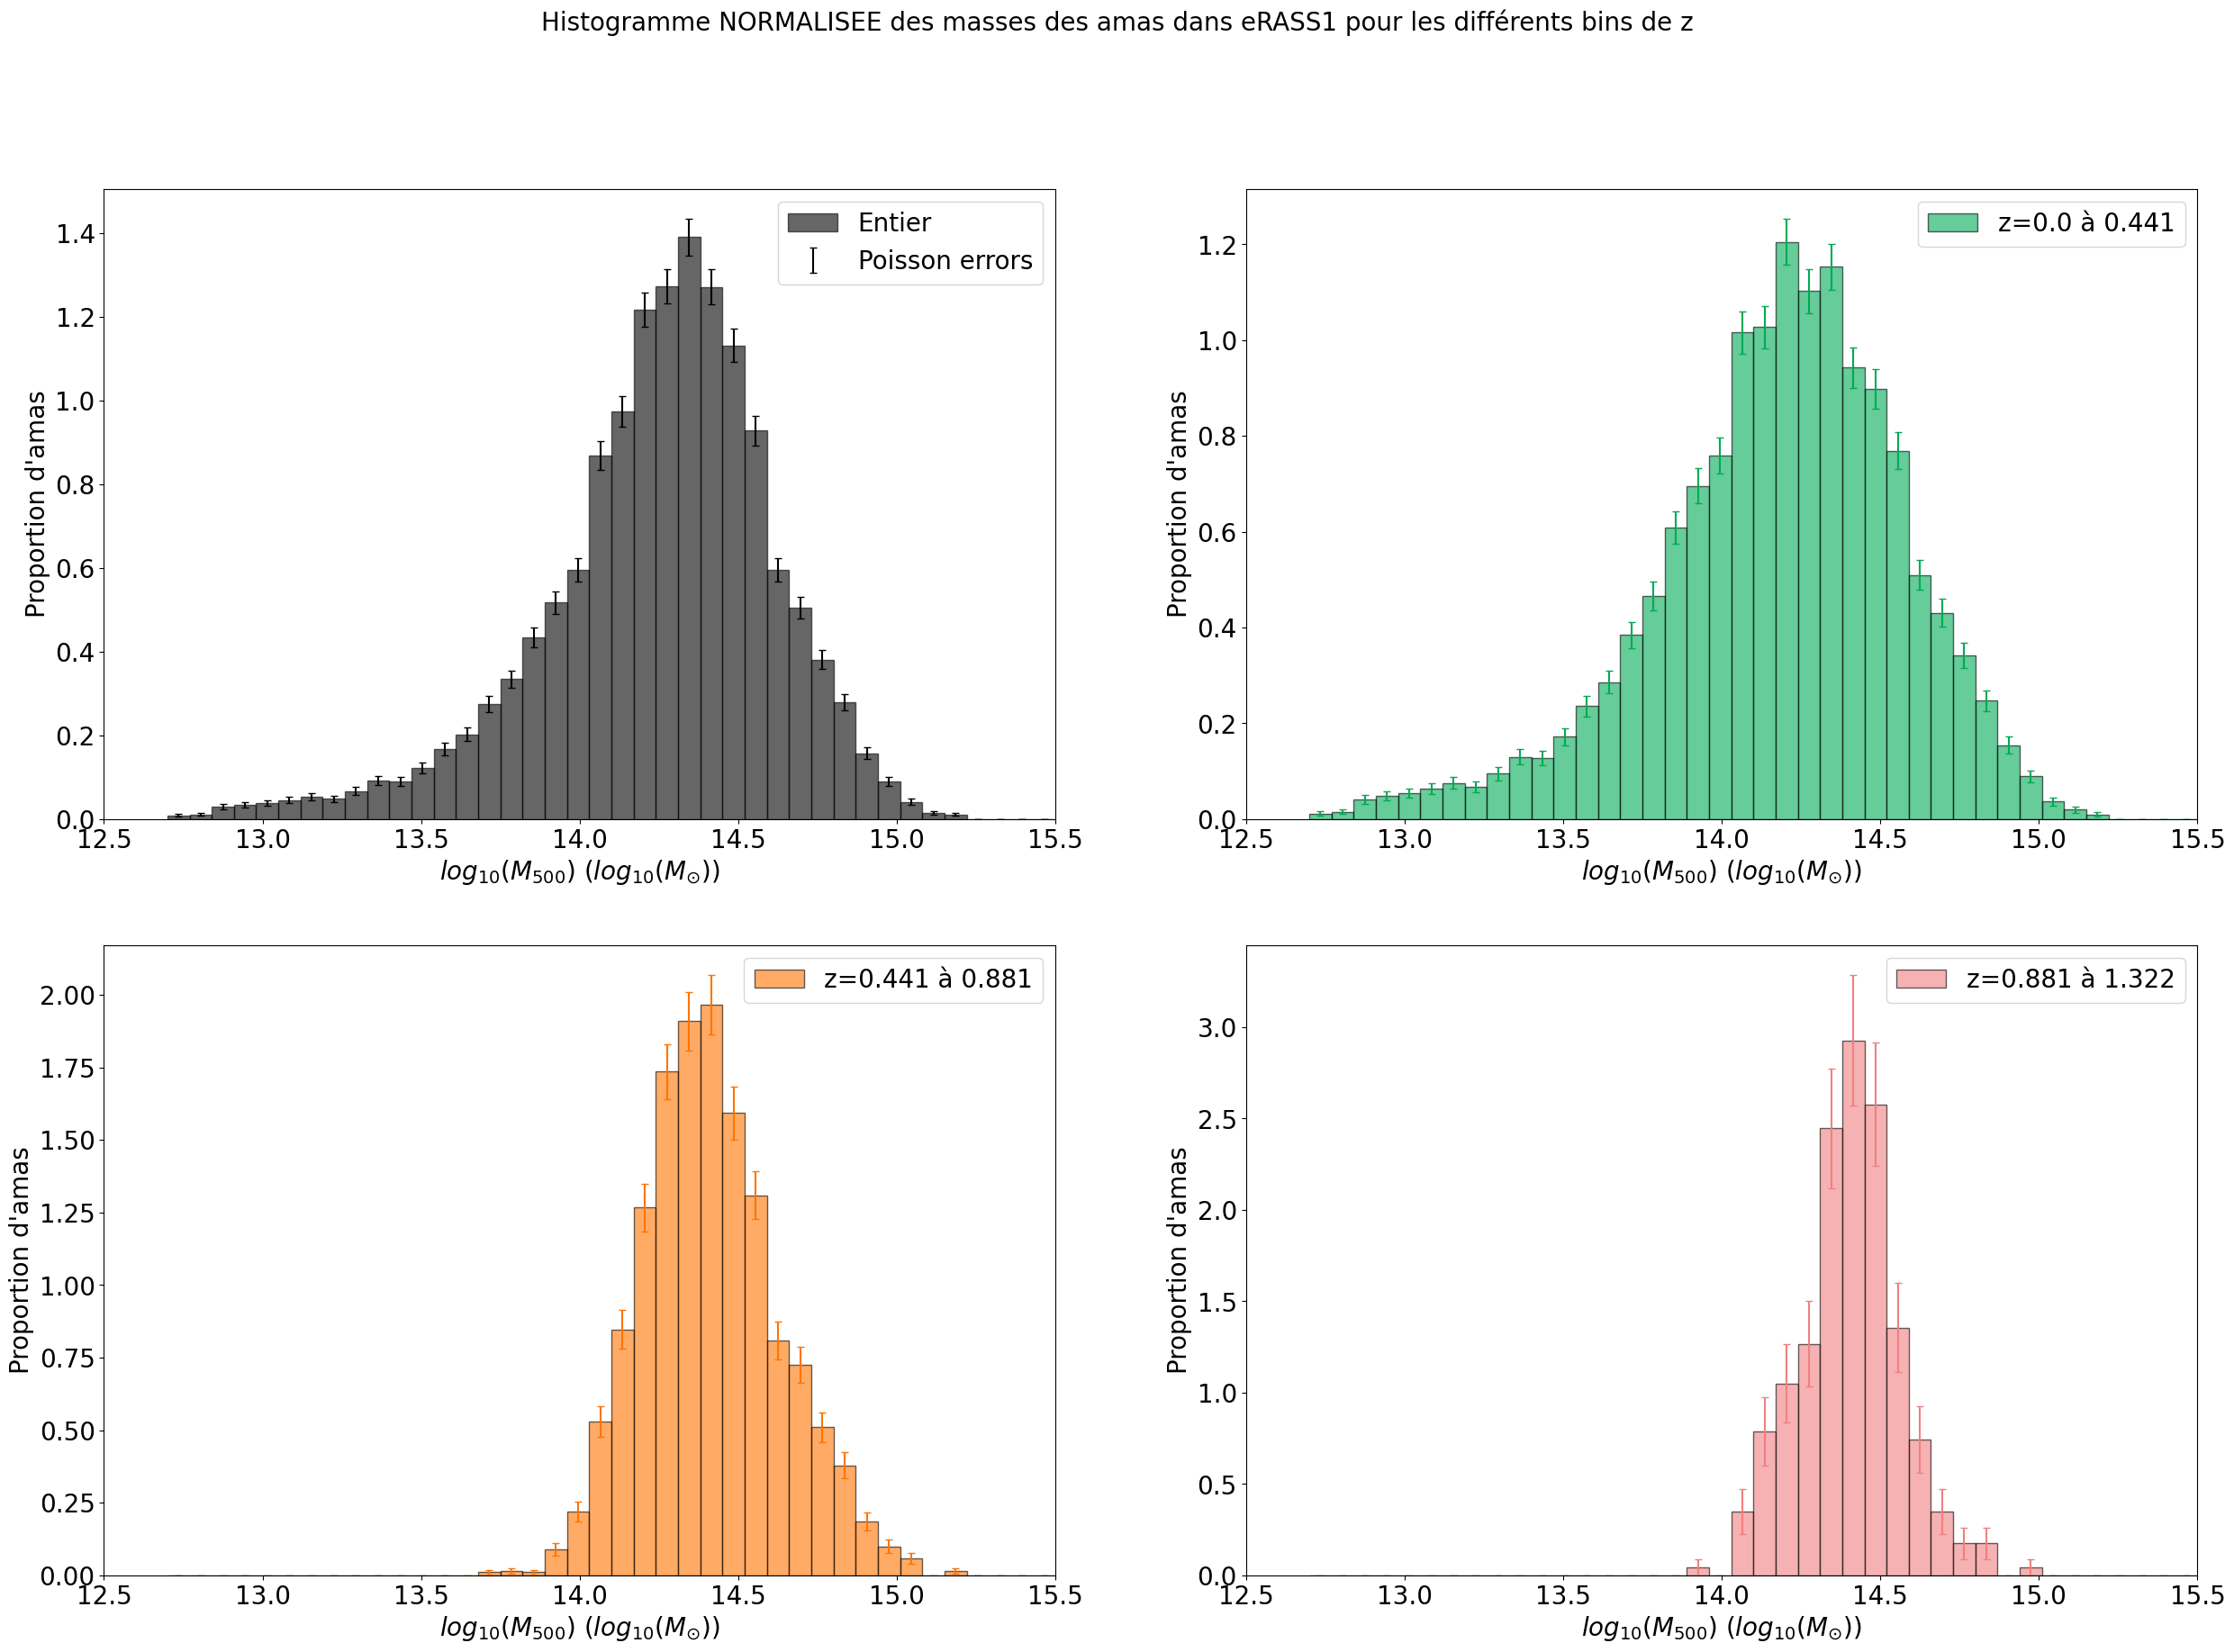

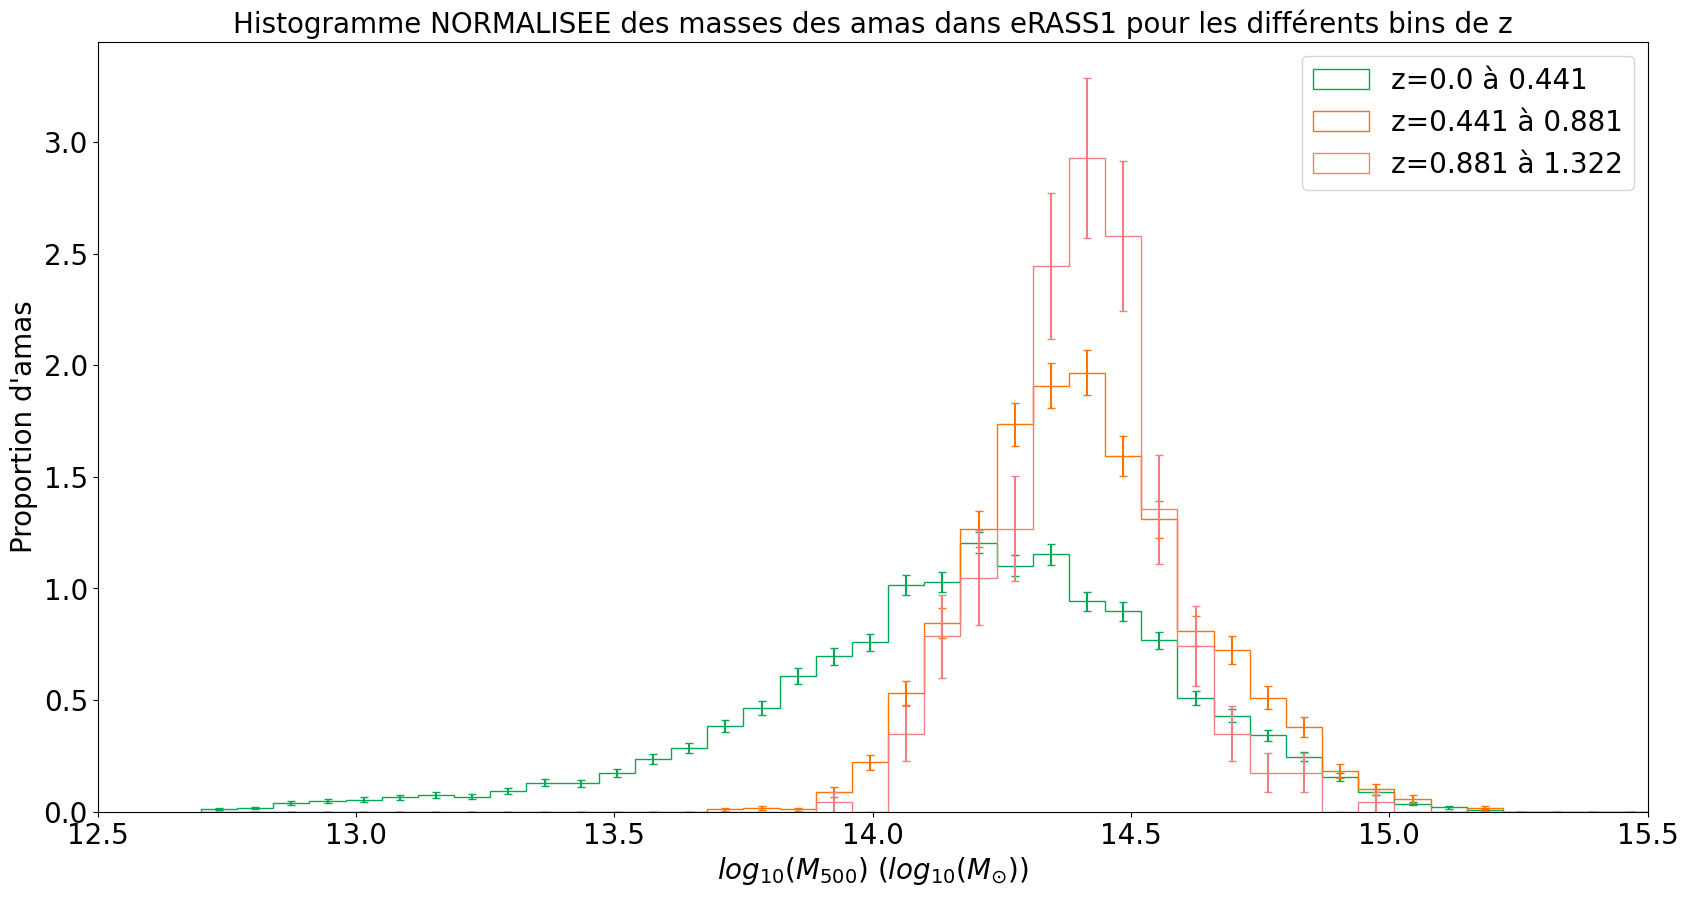

In [76]:
# Histo largeurs fixés - nb différents
# Note : Transformer tout ce code sous la forme de fonction pour éviter la répétition

# Histogramme des masses des amas dans eRASS1 sans normalisation
plt.figure(figsize=(20, 10))

plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans eRASS1')
print('Moyenne de la masse des amas est de ',round(np.mean(M500_eRASS1),3)," et l'écart type de ", round(np.std(M500_eRASS1),3), " pour eRASS1")

#cmap = plt.get_cmap('tab10') 
for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    print('Moyenne de la masse des amas est de ',round(np.mean(sub_mass),3),r" et l'écart type de ", round(np.std(sub_mass),3), f" pour eRASS1 pour des z allant de {round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}")

    
    plt.hist(
        sub_mass,
        bins=nb_bins_histo,
        range=range_M500,  # On fixe la plage de l'histogramme pour qu'il soit comparable avec les autres !
        color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),  # Normalisation de i pour le colormap
        alpha=0.6,
        edgecolor='black',
        label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}'
    )
    plt.errorbar(bin_centers, counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_sub_z[i], fmt='none', ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)') 
    plt.ylabel('Nombre d\'amas')
    plt.yscale('log')
    plt.title(f'Histogramme des masses des amas dans eRASS1 pour {nb_bins_z} bins de z')

plt.legend()

# Histogramme des masses des amas dans eRASS1 normalisé (chaqye nombre d'amas par bin est divisé par le nombre total d'amas dans eRASS1)
plt.figure(figsize=(30, 20))
plt.suptitle(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2 ,1)
plt.hist(M500_eRASS1, bins=nb_bins_histo, color='black',range=range_M500, alpha = 0.6, edgecolor='black',label = 'Entier', density=True) #l'opition density=True normalise l'histogramme ((nombre d'éléments dans le bin) ÷ (nombre total d'éléments × largeur du bin))
plt.errorbar(bin_centers, norm_counts_eRASS1, yerr=errors_poisson_eRASS1_normalized, fmt='none', ecolor='black', capsize=3, label='Poisson errors')
plt.xlim(12.5, 15.5)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
if nb_bins_histo == 100:
    plt.ylabel('Proportion d\'amas en %')
else:
    plt.ylabel('Proportion d\'amas')
plt.legend()

for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2  ,i+2)
    plt.hist(sub_mass, bins=nb_bins_histo, range=range_M500, 
             color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), edgecolor='black', alpha=0.6,
             label = f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}', density=True) #idem
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_normalized_sub_z[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')
    plt.legend()

#
plt.figure(figsize=(20, 10))
plt.title(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    plt.hist(sub_mass, bins=nb_bins_histo, color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),range=range_M500, label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}', density=True, histtype='step') # Only edges
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_normalized_sub_z[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')    
    plt.legend()


Moyenne de la masse des amas est de  14.248  et l'écart type de  0.364  pour eRASS1
Moyenne de la masse des amas est de  14.019  et l'écart type de  0.424  pour eRASS1 pour des z allant de 0.003 à 0.212
Moyenne de la masse des amas est de  14.327  et l'écart type de  0.285  pour eRASS1 pour des z allant de 0.212 à 0.425
Moyenne de la masse des amas est de  14.413  et l'écart type de  0.213  pour eRASS1 pour des z allant de 0.425 à 1.322


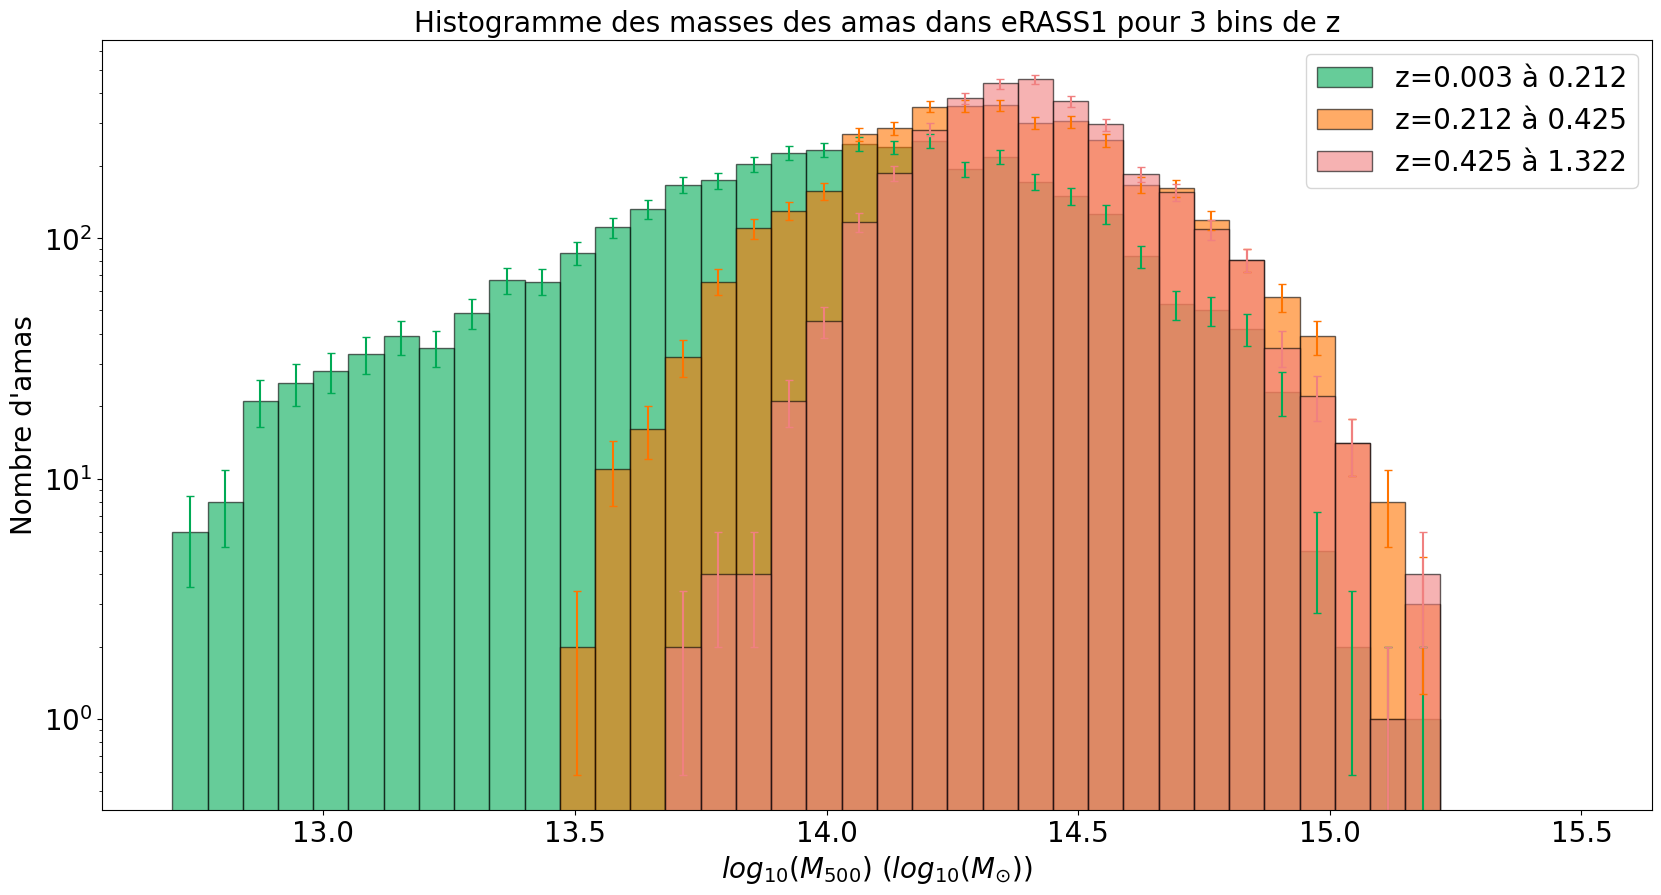

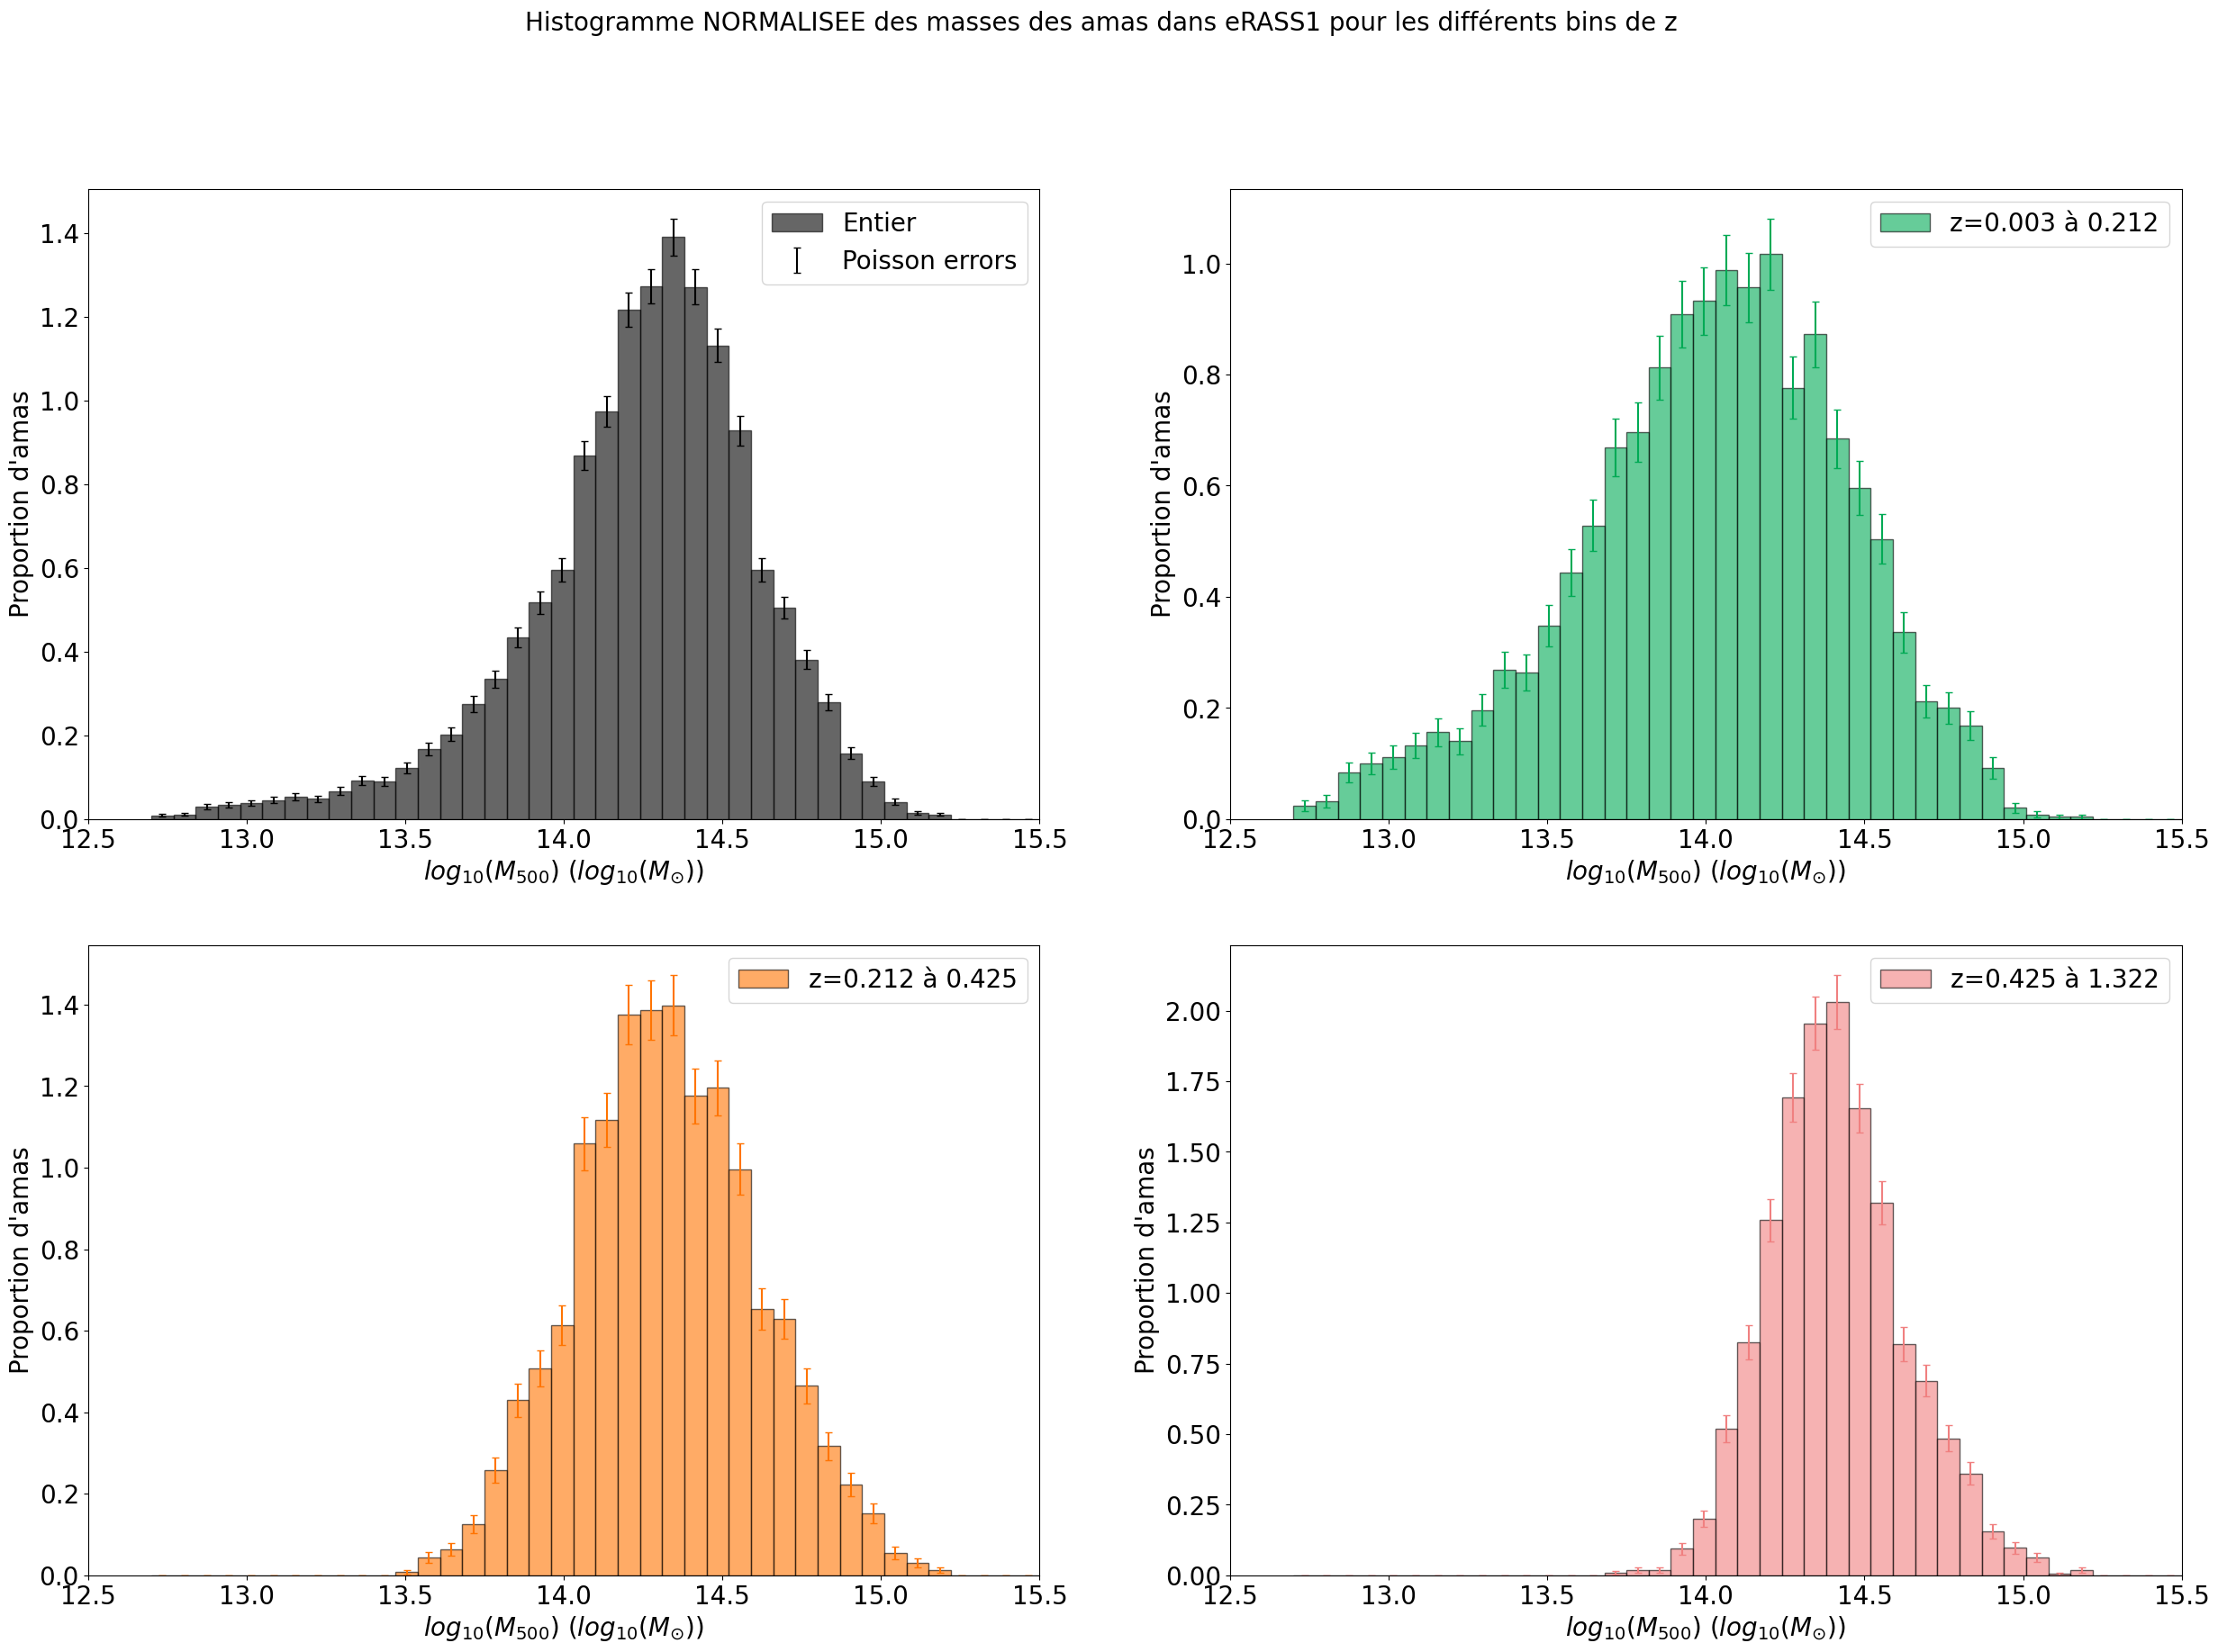

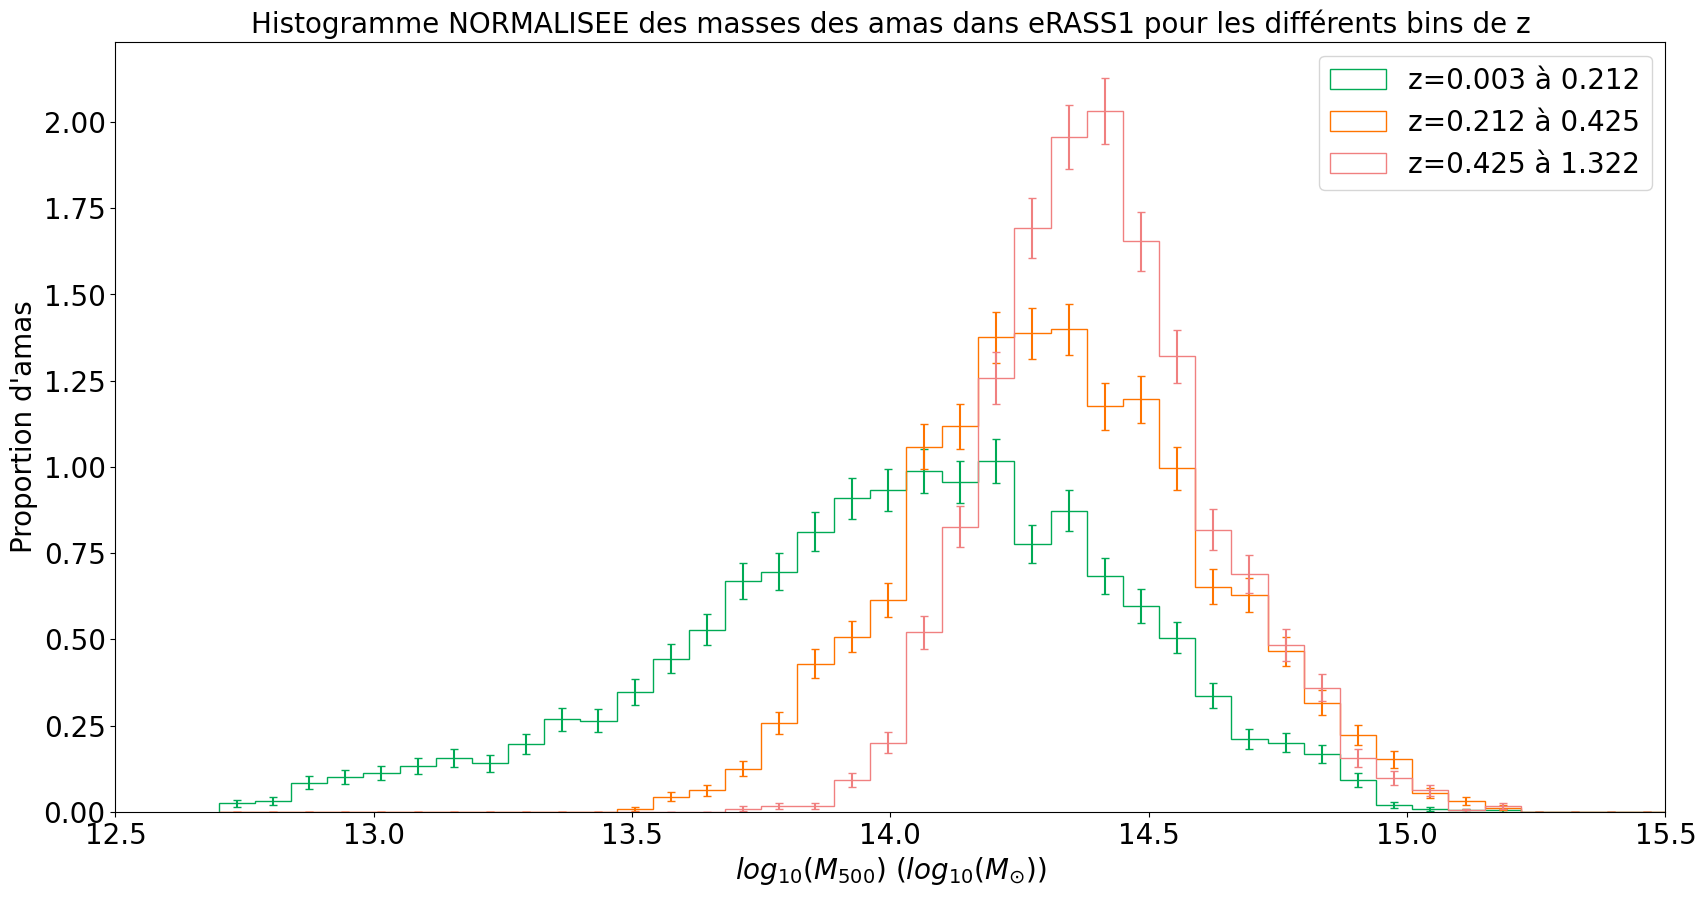

In [77]:
# Histo largeurs différentes - nb ~ fixées

# Histogramme des masses des amas dans eRASS1 sans normalisation
plt.figure(figsize=(20, 10))

plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans eRASS1')
print('Moyenne de la masse des amas est de ',round(np.mean(M500_eRASS1),3)," et l'écart type de ", round(np.std(M500_eRASS1),3), " pour eRASS1")

cmap = plt.get_cmap('tab10') 
for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    print('Moyenne de la masse des amas est de ',round(np.mean(sub_mass),3),r" et l'écart type de ", round(np.std(sub_mass),3), f" pour eRASS1 pour des z allant de {round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}")

    plt.hist(
        sub_mass,
        bins=nb_bins_histo,
        range=range_M500,  # On fixe la plage de l'histogramme pour qu'il soit comparable avec les autres !
        color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),  # Normalisation de i pour le colormap
        alpha=0.6,
        edgecolor='black',
        label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}'
    )
    plt.errorbar(bin_centers, counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_sub_z_2[i], fmt='none', ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)    
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)') 
    plt.ylabel('Nombre d\'amas')
    plt.yscale('log')
    plt.title(f'Histogramme des masses des amas dans eRASS1 pour {nb_bins_z} bins de z')

plt.legend()




# Histogramme des masses des amas dans eRASS1 normalisé (chaqye nombre d'amas par bin est divisé par le nombre total d'amas dans eRASS1)
plt.figure(figsize=(30, 20))
plt.suptitle(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2 ,1)
plt.hist(M500_eRASS1, bins=nb_bins_histo, color='black',range=range_M500, alpha = 0.6, edgecolor='black',label = 'Entier', density=True) #l'opition density=True normalise l'histogramme ((nombre d'éléments dans le bin) ÷ (nombre total d'éléments × largeur du bin))
plt.errorbar(bin_centers, norm_counts_eRASS1, yerr=errors_poisson_eRASS1_normalized, fmt='none', ecolor='black', capsize=3, label='Poisson errors')
plt.xlim(12.5, 15.5)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
if nb_bins_histo == 100:
    plt.ylabel('Proportion d\'amas en %')
else:
    plt.ylabel('Proportion d\'amas')
plt.legend()

for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2  ,i+2)
    plt.hist(sub_mass, bins=nb_bins_histo, range=range_M500, 
             color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), edgecolor='black', alpha=0.6,
             label = f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}', density=True) #idem
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_normalized_sub_z_2[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')
    plt.legend()

#M500_eRASS1_sub_z_2_partial = [M500_eRASS1_sub_z_2[0],M500_eRASS1_sub_z_2[2]]
plt.figure(figsize=(20, 10))
plt.title(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    plt.hist(sub_mass, bins=nb_bins_histo, color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))),range=range_M500, label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}', density=True, histtype='step') # Only edges
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_normalized_sub_z_2[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')    
    plt.legend()


### Fonction de masse

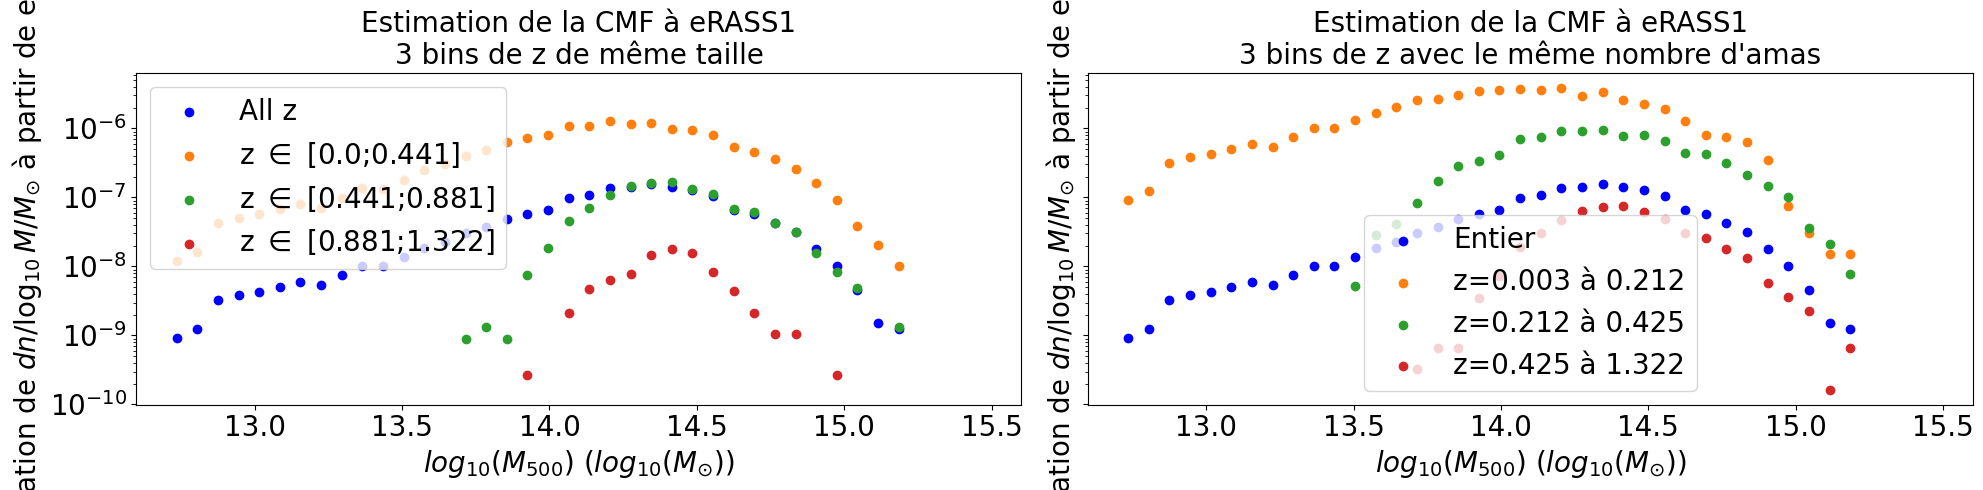

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

# First subplot: bins de z de même taille
ax = axes[0]
ax.scatter(bin_centers, n_eRASS1, color='blue', label='All z') 
cmap = plt.get_cmap('tab10') 
for i, sub_nrass in enumerate(n_eRASS1_sub_z):
    ax.scatter(bin_centers_eRASS1_sub_z[i], sub_nrass, color=cmap(i+1), label=fr'z $\in$ [{round(bornes_z_eRASS1[i],3)};{round(bornes_z_eRASS1[i+1],3)}]')
ax.set_xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
ax.set_ylabel(r'Estimation de $dn / \log_{10} M / M_{\odot}$ à partir de eRASS1')
ax.set_yscale('log')
ax.set_title(f'Estimation de la CMF à eRASS1\n{nb_bins_z} bins de z de même taille')
ax.legend()

# Second subplot: bins de z avec le même nombre d'amas
ax2 = axes[1]
ax2.scatter(bin_centers, n_eRASS1, color='blue', label='Entier') 
cmap = plt.get_cmap('tab10') 
for i, sub_nrass in enumerate(n_eRASS1_sub_z_2):
    ax2.scatter(bin_centers_eRASS1_sub_z_2[i], sub_nrass, color=cmap(i+1), label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}')
ax2.set_xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
ax2.set_ylabel(r'Estimation de $dn / \log_{10} M / M_{\odot}$ à partir de eRASS1')
ax2.set_yscale('log')
ax2.set_title(f'Estimation de la CMF à eRASS1\n{nb_bins_z} bins de z avec le même nombre d\'amas')
ax2.legend()

plt.tight_layout()


<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\1116536354.py:24: SyntaxWarning: invalid escape sequence '\o'
  '''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_eRASS1)


'plt.legend()'

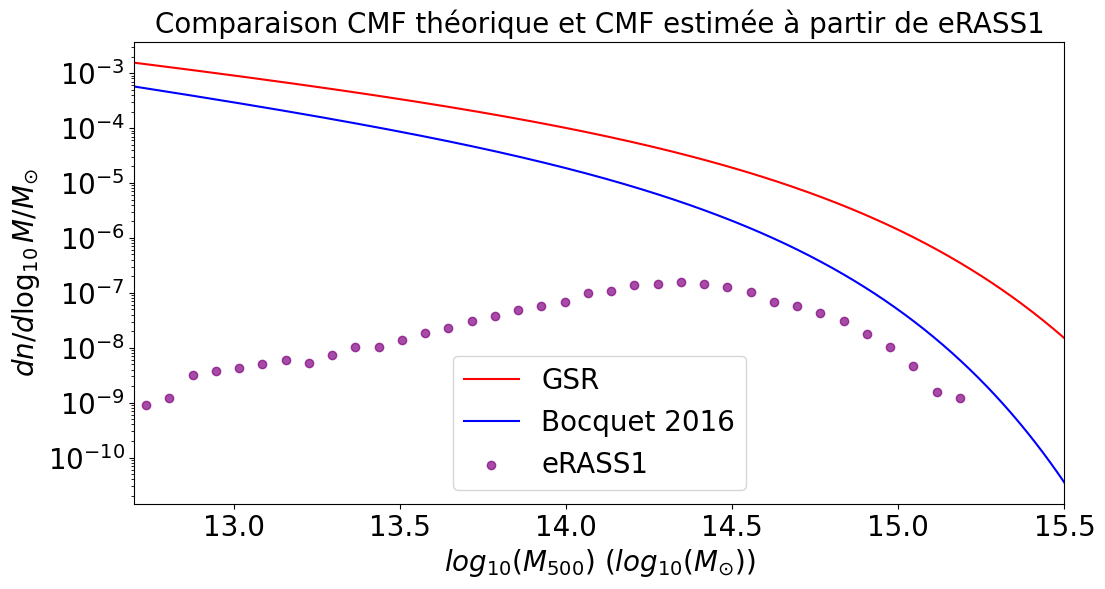

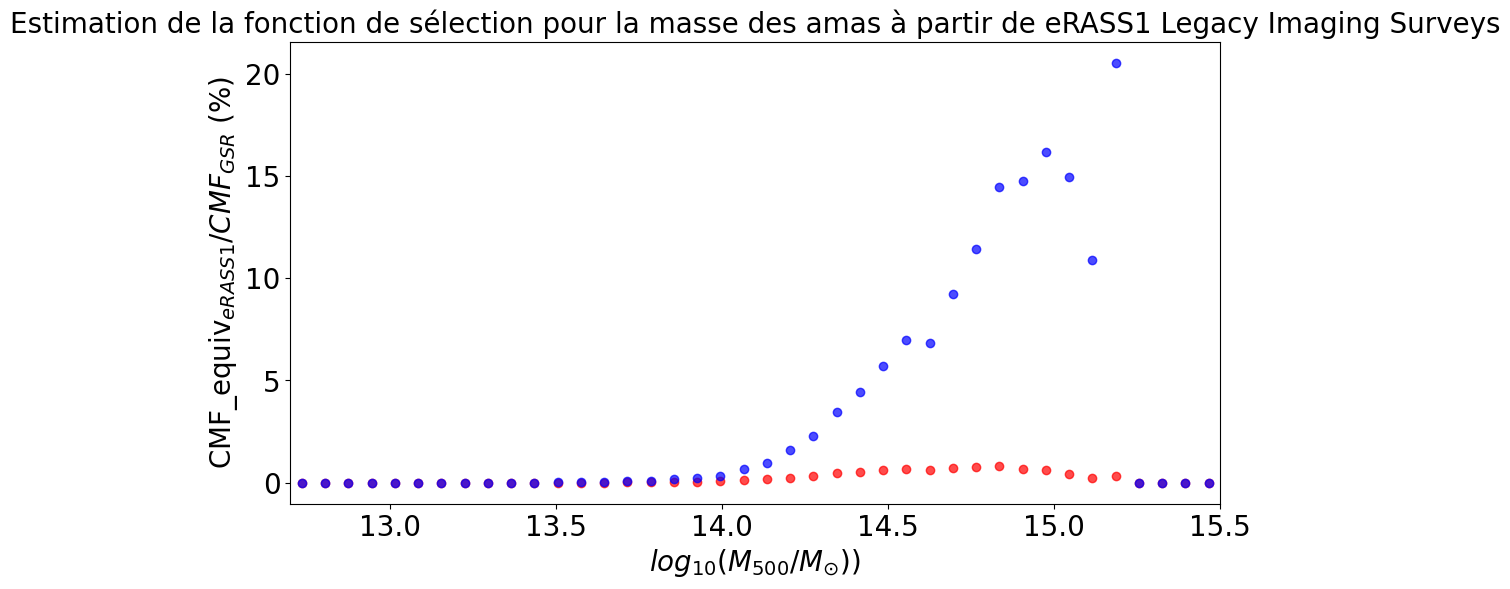

In [79]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
#plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
#plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
#plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.plot(log10_M_Msun,CMF_Bocquet2016,label='Bocquet 2016', color='blue')

plt.scatter(bin_centers, n_eRASS1, color='purple', label='eRASS1', alpha=0.7)
plt.xlim(12.7, 15.5)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')

plt.legend()

'''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_eRASS1)
residuals_SR = np.abs(CMF_SR_func(bin_centers) - n_eRASS1)
residuals_GR = np.abs(CMF_GR_func(bin_centers) - n_eRASS1)
residuals_GS = np.abs(CMF_GS_func(bin_centers) - n_eRASS1)


fig2 = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, residuals_GSR, color='red', label='GSR Residuals', alpha=0.7)-
plt.scatter(bin_centers, residuals_SR, color='blue', label='SR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GR, color='green', label='GR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GS, color='orange', label='GS Residuals', alpha=0.7)
plt.xlim(12.2, 15.7)
plt.yscale('log')

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')


plt.title('Résidus entre la CMF théorique et la CMF estimée à partir de eRASS1')
'''

# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_eRASS1/CMF_GSR_func(bin_centers)
#estimation_selection_function_masse_SR = n_eRASS1/CMF_SR_func(bin_centers)
#estimation_selection_function_masse_GR = n_eRASS1/CMF_GR_func(bin_centers)
#estimation_selection_function_masse_GS = n_eRASS1/CMF_GS_func(bin_centers)

estimation_selection_function_masse_Bocquet2016 = n_eRASS1/hcmf.CMF_Bocquet_2016(10**bin_centers,0.1)



plt.figure(figsize=(12, 6))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
#plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
#plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
#plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')

plt.scatter(bin_centers, estimation_selection_function_masse_Bocquet2016 * 100, color='blue', alpha=0.7,label='GSR')


'''plt.hlines(100, 12.7, 15.5, color='black', linestyle='dashed', label='100%')
plt.hlines(0, 12.7, 15.5, color='black', linestyle='dashed', label='0%')'''

plt.xlim(12.7, 15.5)

plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{eRASS1} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de eRASS1 Legacy Imaging Surveys')

'''plt.legend()'''

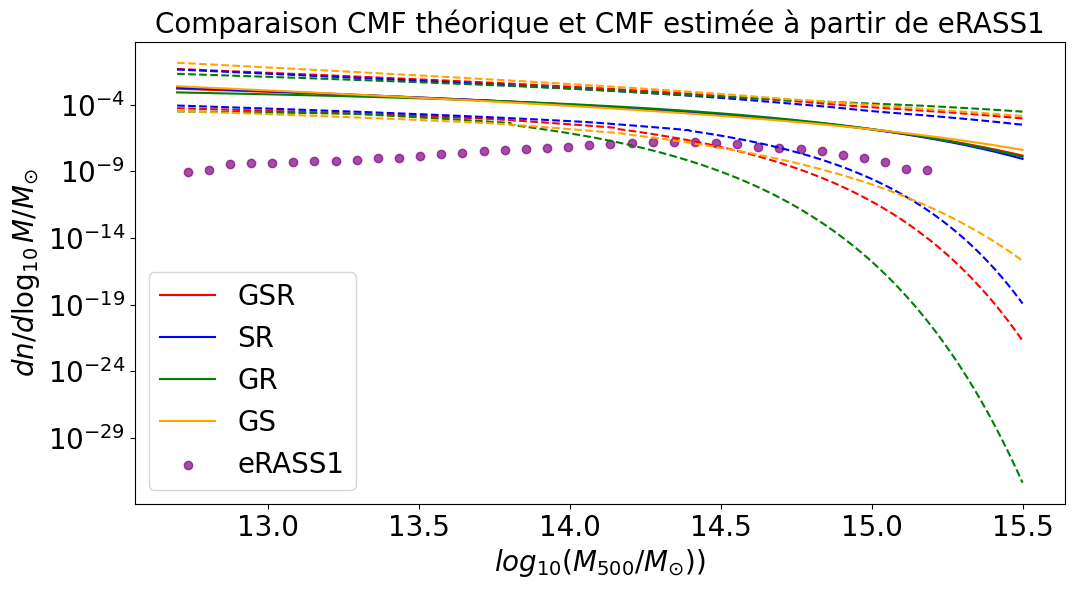

In [80]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_eRASS1, color='purple', label='eRASS1', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')
plt.legend()

### Fonction de luminosité

#### Luminosité absolue

##### Récupération / Calculs valeurs

In [81]:
# Données
LX_eRASS1 = np.array(table_eRASS1['L500']) # 0.2-2.3keV luminosity within R500 at zlambda (10^35 W → 10^42 erg.s^-1)
LX_eRASS1 = LX_eRASS1 * 1e42 # W → erg.s^-1
LX_eRASS1 = LX_eRASS1[(LX_eRASS1 > 0)] # On ne garde que les valeurs stritement positives de luminosité
log10_LX_eRASS1 = np.log10(LX_eRASS1) # log10(LX_eRASS1) in erg.s^-1
ln_LX_eRASS1 = np.log(LX_eRASS1)

# On va tracer la fonction de luminosité à partir de eRASS1
bin_centers_LX_eRASS1, counts_LX_eRASS1, bin_width_LX_eRASS1, n_LX_eRASS1 = uf.compute_histogram_density(LX_eRASS1,bins=100,range=[1e41,4e45],volume=volume_eRASS1)
print("Bin width for LX eRASS1:", bin_width_LX_eRASS1)

bin_centers_LX_eRASS1_log10, counts_LX_eRASS1_log10, bin_width_LX_eRASS_log10, n_LX_eRASS1_log10 = uf.compute_histogram_density(log10_LX_eRASS1,bins=100,volume=volume_eRASS1)
print("Bin width for log10(LX eRASS1):", bin_width_LX_eRASS_log10)

bin_centers_LX_eRASS1_ln, counts_LX_eRASS1_ln, bin_width_LX_eRASS_ln, n_LX_eRASS1_ln = uf.compute_histogram_density(ln_LX_eRASS1,bins=100,volume=volume_eRASS1)
print("Bin width for ln(LX eRASS1):", bin_width_LX_eRASS_ln)

Bin width for LX eRASS1: 3.9999e+43
Bin width for log10(LX eRASS1): 0.044988633799981415
Bin width for ln(LX eRASS1): 0.1035901575420013


In [82]:
importlib.reload(hcmf) ; importlib.reload(uf) 

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

In [83]:
#Théorie 
#range_Lx = np.linspace(1e-3 * 1e42,3600 * 1e42,10000) # 10^42 erg.s^-1
range_z = np.arange(0.1, 1.4, 0.3) 

ClxF_values_z = []
for z in range_z:
    ClxF_values_z.append(hcmf.CLxF_eRASS_Bocquet_2016(np.exp(bin_centers_LX_eRASS1_ln), z))
    

M500 =  [3.07405174e+12 3.30209558e+12 3.54705650e+12 3.81018948e+12
 4.09284257e+12 4.39646385e+12 4.72260882e+12 5.07294834e+12
 5.44927728e+12 5.85352360e+12 6.28775831e+12 6.75420607e+12
 7.25525654e+12 7.79347668e+12 8.37162386e+12 8.99266000e+12
 9.65976676e+12 1.03763618e+13 1.11461164e+13 1.19729740e+13
 1.28611708e+13 1.38152572e+13 1.48401209e+13 1.59410127e+13
 1.71235724e+13 1.83938585e+13 1.97583788e+13 2.12241240e+13
 2.27986032e+13 2.44898828e+13 2.63066274e+13 2.82581444e+13
 3.03544317e+13 3.26062289e+13 3.50250723e+13 3.76233538e+13
 4.04143849e+13 4.34124644e+13 4.66329519e+13 5.00923462e+13
 5.38083705e+13 5.78000624e+13 6.20878718e+13 6.66937658e+13
 7.16413411e+13 7.69559447e+13 8.26648040e+13 8.87971664e+13
 9.53844487e+13 1.02460398e+14 1.10061267e+14 1.18225994e+14
 1.26996409e+14 1.36417444e+14 1.46537364e+14 1.57408014e+14
 1.69085088e+14 1.81628407e+14 1.95102233e+14 2.09575595e+14
 2.25122640e+14 2.41823020e+14 2.59762292e+14 2.79032361e+14
 2.99731951e+14 

##### Tracés

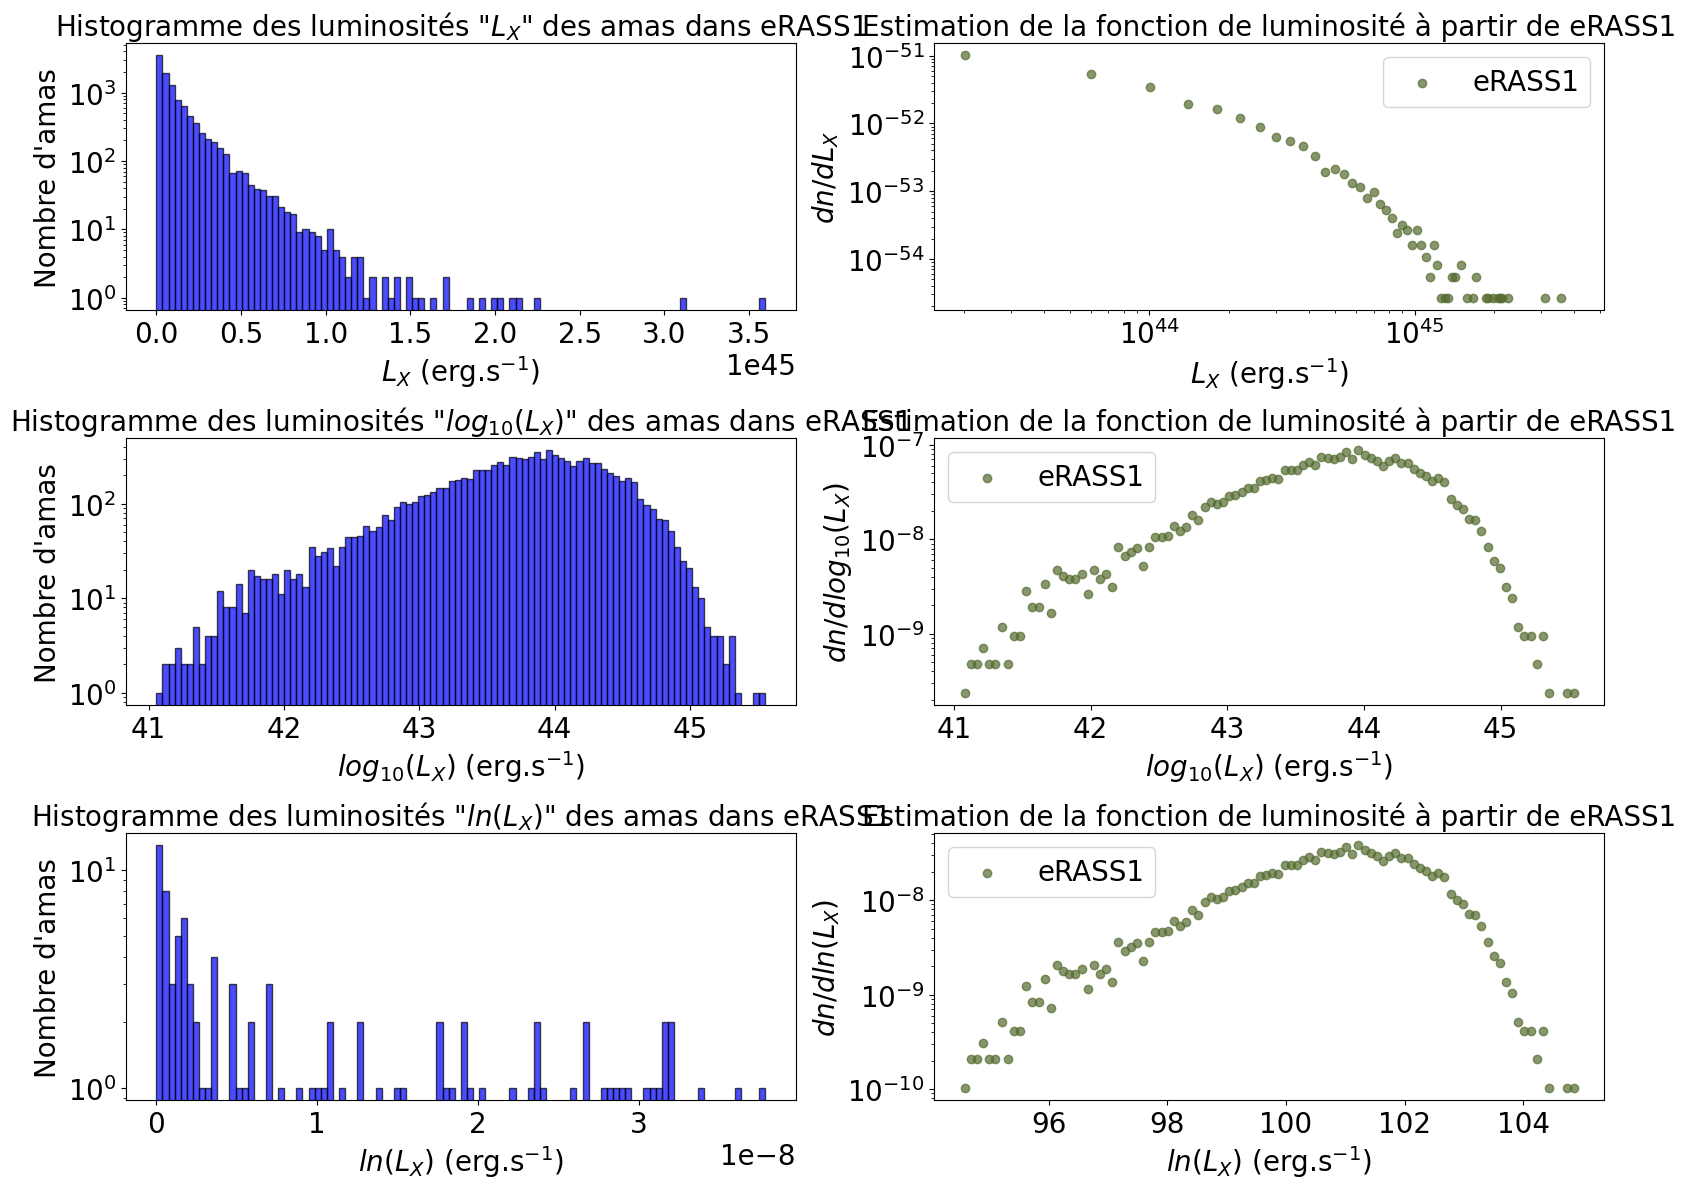

In [84]:
# LX and log10(LX) plots as 2x2 subplots

fig, axs = plt.subplots(3, 2, figsize=(16, 12))

# Top left: Histogram LX
axs[0, 0].hist(LX_eRASS1, bins=100, color='blue', edgecolor='black', alpha=0.7)
axs[0, 0].set_xlabel(r'$L_{X}$ (erg.s$^{-1}$)')
axs[0, 0].set_ylabel('Nombre d\'amas')
axs[0, 0].set_yscale('log')
axs[0, 0].set_title(r'Histogramme des luminosités "$L_{X}$" des amas dans eRASS1')

# Top right: dn/dLX scatter
axs[0, 1].scatter(bin_centers_LX_eRASS1, n_LX_eRASS1, color='darkolivegreen', label='eRASS1', alpha=0.7)
axs[0, 1].set_xlabel(r'$L_{X}$ (erg.s$^{-1}$)')
axs[0, 1].set_ylabel(r'$dn / dL_{X}$')
axs[0, 1].set_yscale('log')
axs[0, 1].set_xscale('log')
axs[0, 1].set_title(r'Estimation de la fonction de luminosité à partir de eRASS1')
axs[0, 1].legend()
# !!!! Why n_LX_eRASS1 is so small ?????

# Middle left: Histogram log10(LX)
axs[1, 0].hist(log10_LX_eRASS1, bins=100, color='blue', edgecolor='black', alpha=0.7)
axs[1, 0].set_xlabel(r'$log_{10}(L_{X})$ (erg.s$^{-1}$)')
axs[1, 0].set_ylabel('Nombre d\'amas')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title(r'Histogramme des luminosités "$log_{10}(L_{X})$" des amas dans eRASS1')

# Middle right: dn/dlog10(LX) scatter
axs[1, 1].scatter(bin_centers_LX_eRASS1_log10, n_LX_eRASS1_log10, color='darkolivegreen', label='eRASS1', alpha=0.7)
axs[1, 1].set_xlabel(r'$log_{10}(L_{X})$ (erg.s$^{-1}$)')
axs[1, 1].set_ylabel(r'$dn / dlog_{10}(L_{X})$')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title(r'Estimation de la fonction de luminosité à partir de eRASS1')
axs[1, 1].legend()

# Bottom left: Histogram ln(LX)
axs[2, 0].hist(n_LX_eRASS1_ln, bins=100, color='blue', edgecolor='black', alpha=0.7)
axs[2, 0].set_xlabel(r'$ln(L_{X})$ (erg.s$^{-1}$)')
axs[2, 0].set_ylabel('Nombre d\'amas')
axs[2, 0].set_yscale('log')
axs[2, 0].set_title(r'Histogramme des luminosités "$ln(L_{X})$" des amas dans eRASS1')

# Bottom right: dn/dln10(LX) scatter
axs[2, 1].scatter(bin_centers_LX_eRASS1_ln, n_LX_eRASS1_ln, color='darkolivegreen', label='eRASS1', alpha=0.7)
axs[2, 1].set_xlabel(r'$ln(L_{X})$ (erg.s$^{-1}$)')
axs[2, 1].set_ylabel(r'$dn / dln(L_{X})$')
axs[2, 1].set_yscale('log')
axs[2, 1].set_title(r'Estimation de la fonction de luminosité à partir de eRASS1')
axs[2, 1].legend()


plt.tight_layout()
plt.show()


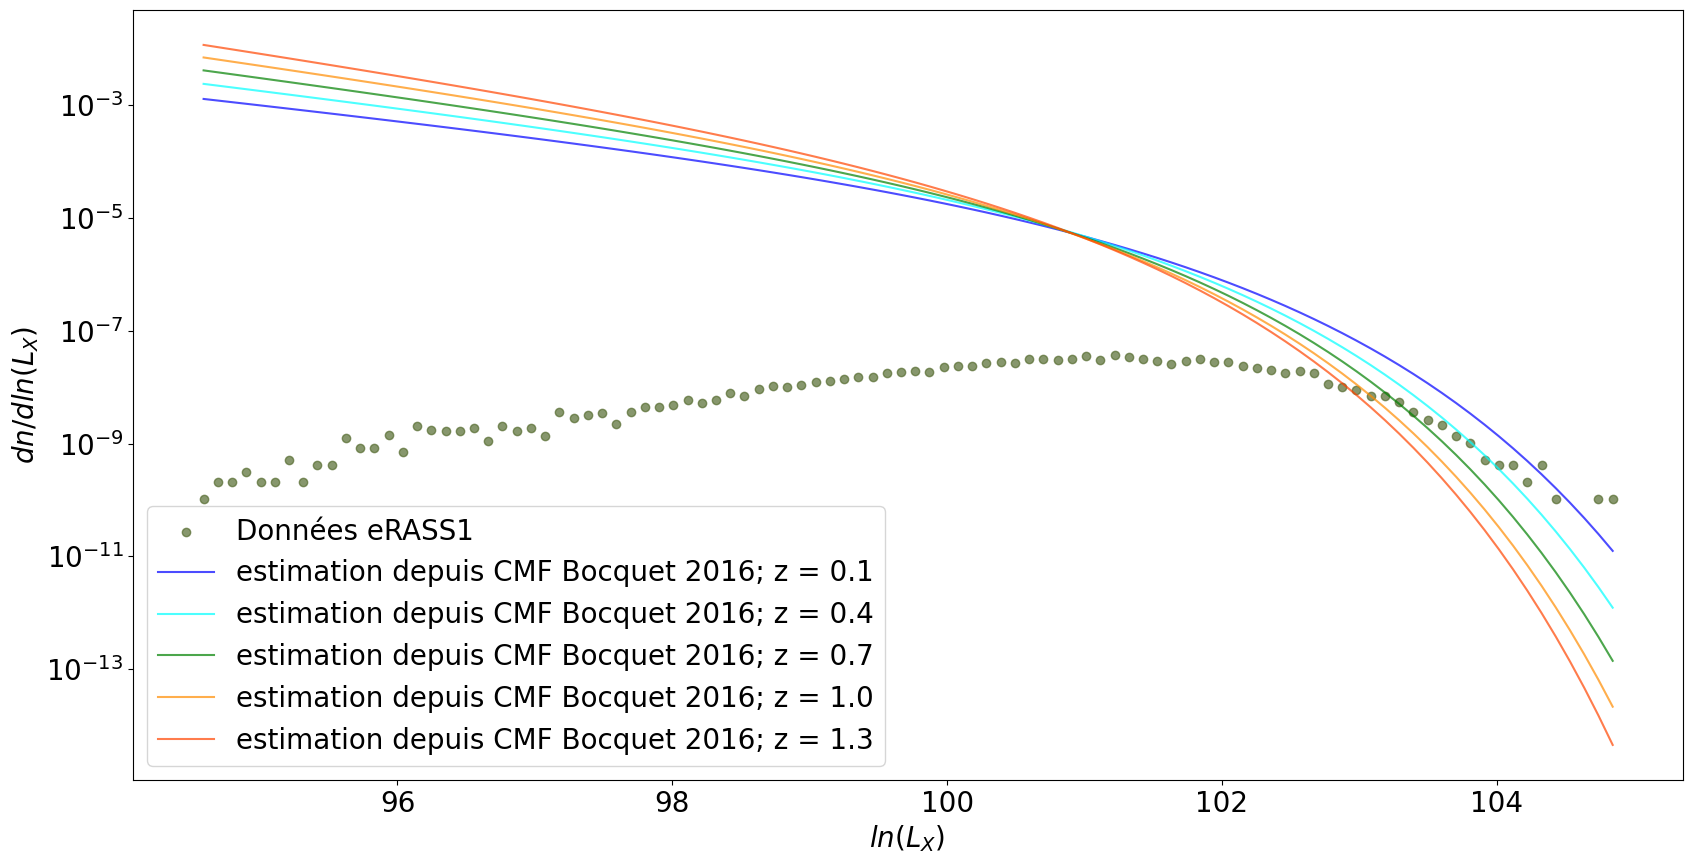

In [85]:
# A comparer avec la théorie de la fonction de luminosité ! → besoin d'une relation d'échelle adaptée à eRASS1
plt.figure(figsize=(20, 10))

plt.scatter(bin_centers_LX_eRASS1_ln, n_LX_eRASS1_ln, color='darkolivegreen', label='Données eRASS1', alpha=0.7)
plt.xlabel(r'$ln(L_{X})$ (erg.s$^{-1}$)')
plt.ylabel(r'$dn / dln(L_{X})$')
plt.yscale('log')

for i,ClxF_values in enumerate(ClxF_values_z):
    plt.plot(bin_centers_LX_eRASS1_ln, ClxF_values, color=colors[i], label=f'estimation depuis CMF Bocquet 2016; z = {np.round(range_z[i], 2)}', alpha=0.7)
    plt.xlabel(r'$ln(L_{X})$ ')
    plt.ylabel(r'$dn / dln(L_{X})$')

plt.legend()

plt.show()



#### Luminosité apparente

##### Calculs

In [86]:
table_eRASS1 = uf.add_apparent_luminosity(
    df=table_eRASS1,
    Labs_col='L500',
    z_col='zBest',
    cosmo=cosmo,
    new_col='L500_app'
)

Lapp_eRASS1 = table_eRASS1['L500_app'] ; Lapp_eRASS1 = Lapp_eRASS1[(Lapp_eRASS1 > 0)] # On ne garde que les valeurs stritement positives de luminosité apparente
log10_Lapp_eRASS1 = np.log10(Lapp_eRASS1)

bin_centers_Lapp_eRASS1_log10, counts_Lapp_eRASS1_log10, bin_width_Lapp_eRASS1_log10, n_Lapp_eRASS1_log10 = uf.compute_histogram_density(log10_Lapp_eRASS1, bins=100, volume=volume_eRASS1)

##### Tracés

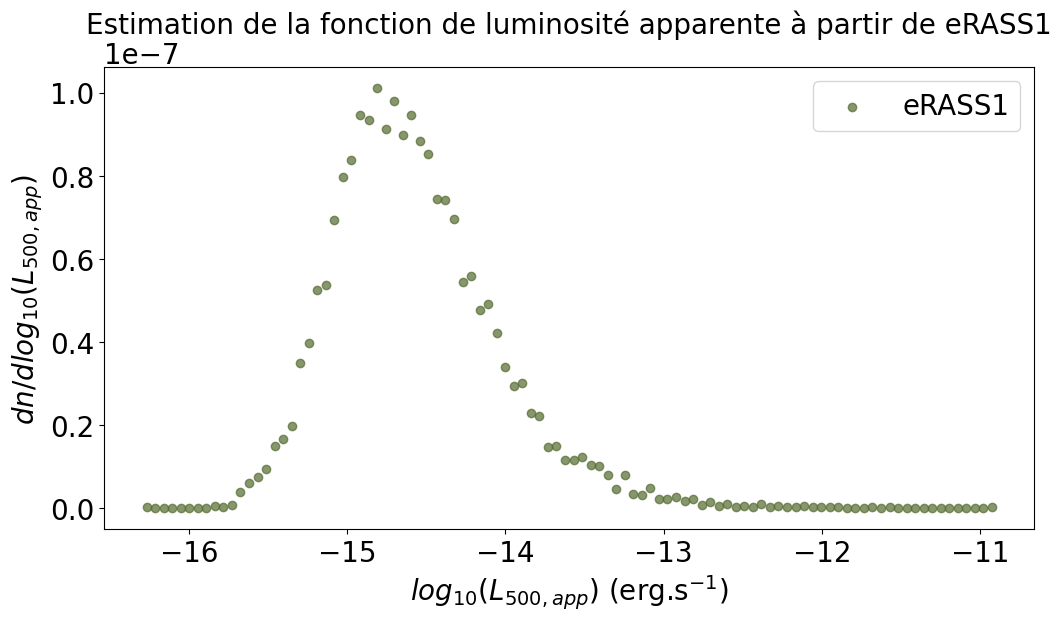

In [87]:
plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_Lapp_eRASS1_log10, n_Lapp_eRASS1_log10, color='darkolivegreen', label='eRASS1', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{500,app})$ (erg.s$^{-1}$)')
plt.ylabel(r'$dn / dlog_{10}(L_{500,app})$')
plt.title(r'Estimation de la fonction de luminosité apparente à partir de eRASS1')
plt.legend()

#### Coupure L_app

##### Récupération / Calculs valeurs

In [88]:
# A partir de dn/dlog10(Lapp) ci-dessus, on en déduit une coupure minimale de détection de cette survey en Lapp
log10_Lapp_min = -16.5 ; L_app_min = 10**log10_Lapp_min
log10_Lapp_min_2 = -16 ; L_app_min_2 = 10**log10_Lapp_min_2

# Maintenant on va calculer la coupure en redshift associée à celle en luminosité apparente pour chaque bin de log10(LX)
arg_inv_lum_dist = 10 * np.sqrt((10**bin_centers_LX_eRASS1_log10) / (L_app_min))  # Homogène à une distance lumineuse en pc
arg_inv_lum_dist_2 = 10 * np.sqrt((10**bin_centers_LX_eRASS1_log10) / (L_app_min_2))
inverse_DL = uf.inverse_luminosity_distance([0.005, 10, 200000])  # Fonction inverse de la distance lumineuse

# coupure en redshift associée à la coupure en luminosité apparente
z_max = inverse_DL(arg_inv_lum_dist)
z_max = np.where(z_max > 1.32, 1.32, z_max)
z_max_2 = inverse_DL(arg_inv_lum_dist_2)
z_max_2 = np.where(z_max_2 > 1.32, 1.32, z_max_2)

z_max_old = uf.inverse_luminosity_distance_old(arg_inv_lum_dist)
z_max_old = np.where(z_max_old > 1.32, 1.32, z_max_old)

bornes_z_cut_eRASS1 = [0.003, z_max]
volume_eRASS1_cut = uf.Volume_survey_array(angular_area_eRASS1_deg2, bornes_z_cut_eRASS1)

bornes_z_cut_eRASS1_2 = [0.003, z_max_2]
volume_eRASS1_cut_2 = uf.Volume_survey_array(angular_area_eRASS1_deg2, bornes_z_cut_eRASS1_2)

# On recalcule la densité maintenant par bin de LX maintenant qu'on dispose du volume d'observation pour chaque bin
n_eRASS1_LX_log10_cut = []
for i in range(len(bin_centers_LX_eRASS1_log10)):
    current_n = (counts_LX_eRASS1_log10[i] / bin_width_LX_eRASS_log10) / volume_eRASS1_cut[i]
    n_eRASS1_LX_log10_cut.append(current_n)

\\dapdc5\ED282972\My Documents\Stage\Content\caracterisation selection effects\useful_functions.py:185: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  z_solution = fsolve(func, z_initial_guess)


##### Tracés

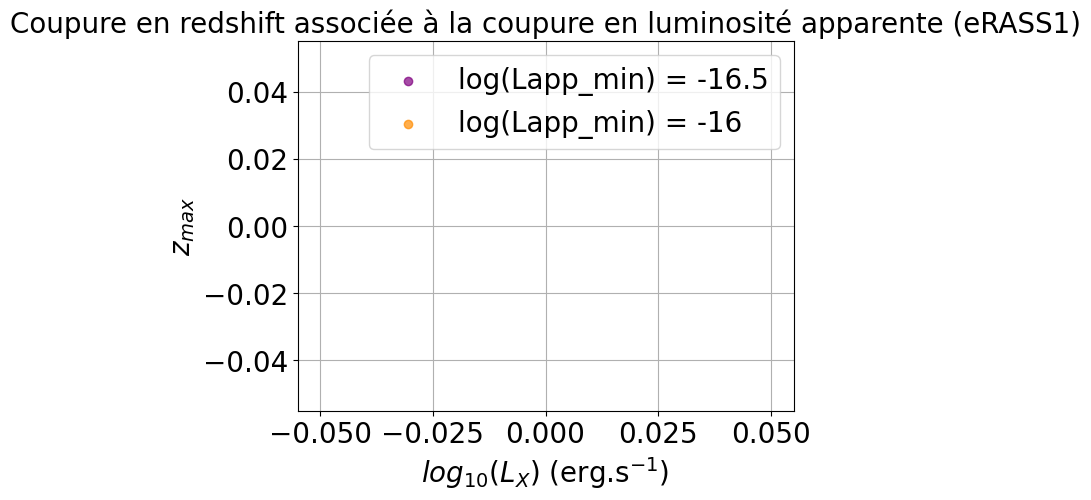

In [89]:
plt.scatter(bin_centers_LX_eRASS1_log10, z_max, color='purple', label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
#plt.scatter(bin_centers_LX_eRASS1_log10, z_max_old, color='brown', label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_LX_eRASS1_log10, z_max_2, color='darkorange', label=f'log(Lapp_min) = {log10_Lapp_min_2}', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{X})$ (erg.s$^{-1}$)')
plt.ylabel(r'$z_{max}$')
plt.title('Coupure en redshift associée à la coupure en luminosité apparente (eRASS1)')
plt.grid(True)
plt.legend()


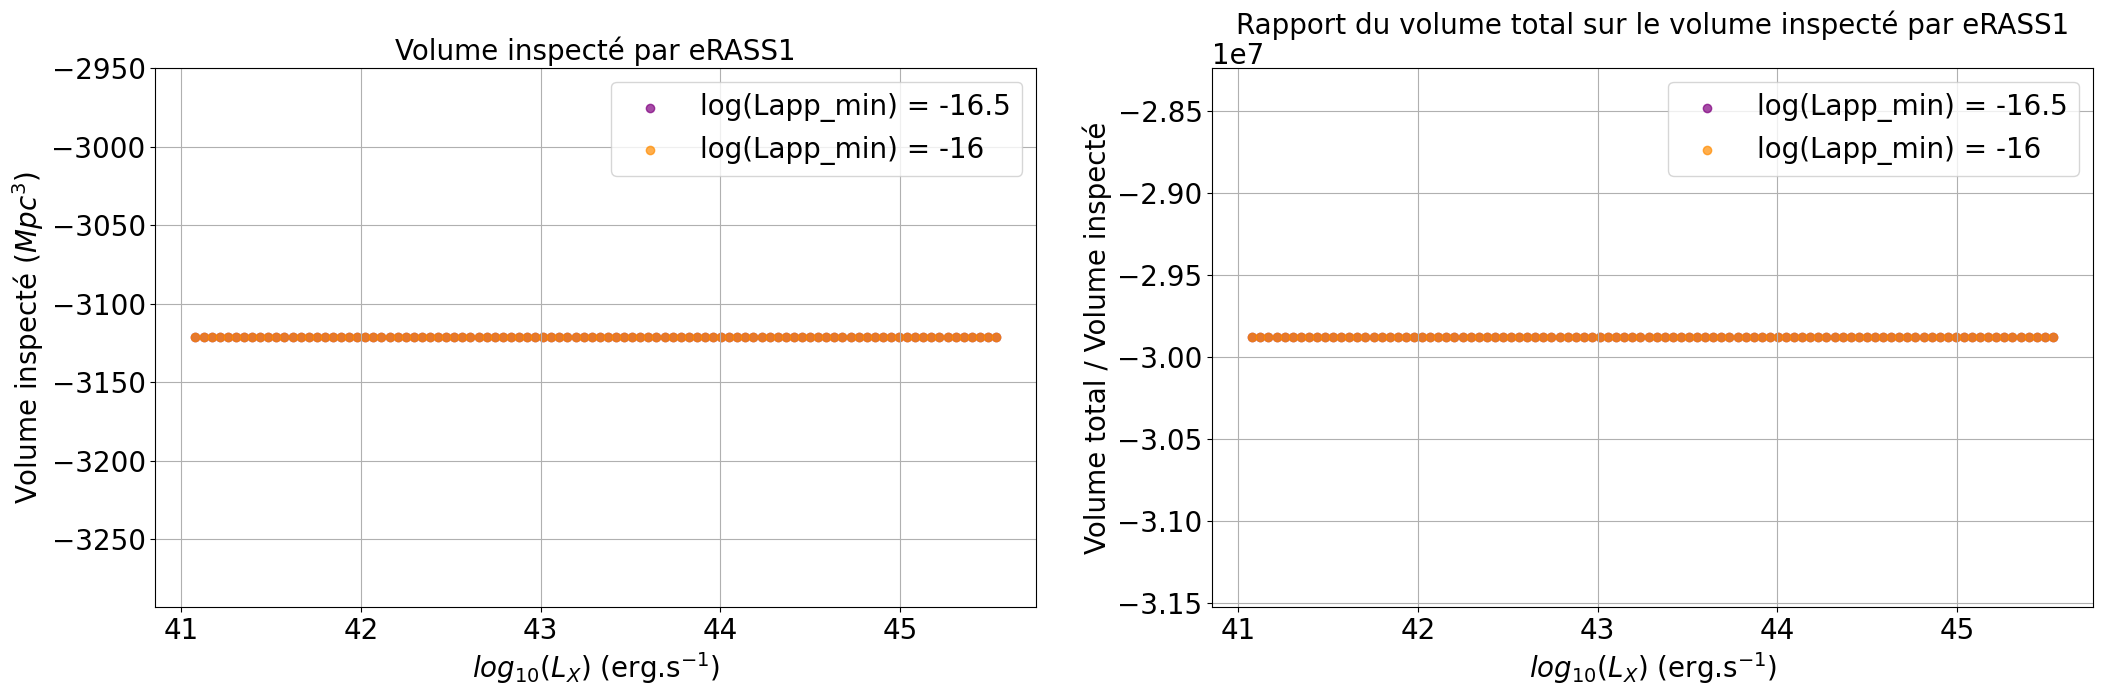

In [90]:
fig1 = plt.figure(figsize=(25, 7))

plt.subplot(121)
plt.scatter(bin_centers_LX_eRASS1_log10, volume_eRASS1_cut, color='purple', label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_LX_eRASS1_log10, volume_eRASS1_cut_2, color='darkorange', label=f'log(Lapp_min) = {log10_Lapp_min_2}', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{X})$ (erg.s$^{-1}$)')
plt.ylabel(r'Volume inspecté $(Mpc^3)$')
plt.title(f'Volume inspecté par eRASS1')
plt.grid(True)
plt.legend()

plt.subplot(122)
plt.scatter(bin_centers_LX_eRASS1_log10, volume_eRASS1 / np.array(volume_eRASS1_cut), color='purple', label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_LX_eRASS1_log10, volume_eRASS1 / np.array(volume_eRASS1_cut_2), color='darkorange', label=f'log(Lapp_min) = {log10_Lapp_min_2}', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{X})$ (erg.s$^{-1}$)')
plt.ylabel(r'Volume total / Volume inspecté')
plt.title(f'Rapport du volume total sur le volume inspecté par eRASS1')
plt.grid(True)
plt.legend()


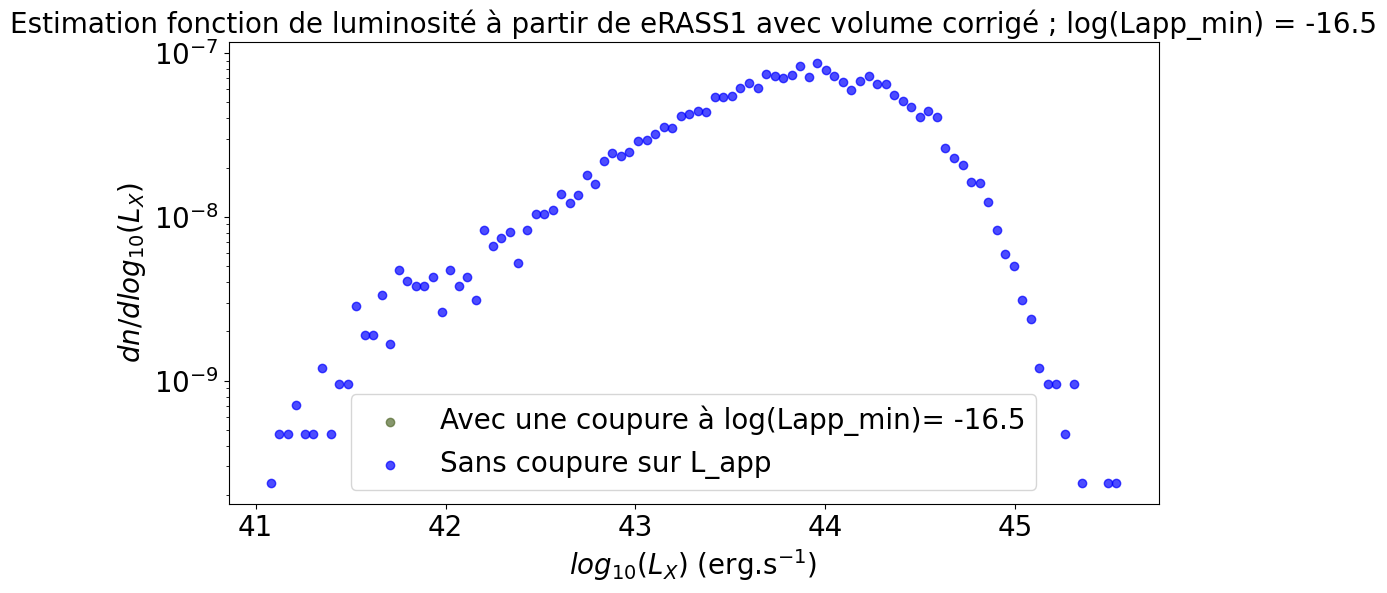

In [91]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_LX_eRASS1_log10, n_eRASS1_LX_log10_cut, color='darkolivegreen', label=f'Avec une coupure à log(Lapp_min)= {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_LX_eRASS1_log10, n_LX_eRASS1_log10, color='blue', label=f'Sans coupure sur L_app', alpha=0.7)

#plt.scatter(bin_centers_LX_eRASS1_log10, n_LX_eRASS1_log10, color='red', label='Sans coupure')

plt.xlabel(r'$log_{10}(L_{X})$ (erg.s$^{-1}$)')
plt.ylabel(r'$dn / dlog_{10}(L_{X})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de eRASS1 avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()


In [92]:
L500_eRASS1 = table_eRASS1['L500']  # Luminosité dans la bande 0.2-2.3 keV à R500 (erg.s^-1)

In [93]:
CR500_eRASS1 = table_eRASS1['CR500'] 

C:\Users\ED282972\AppData\Local\Temp\ipykernel_26324\4263698692.py:1: RuntimeWarning: divide by zero encountered in log10
  M500_eRASS1_2 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun # M500 masses in Msun


Text(0.5, 1.0, 'Relation entre la masse et la luminosité des amas dans eRASS1')

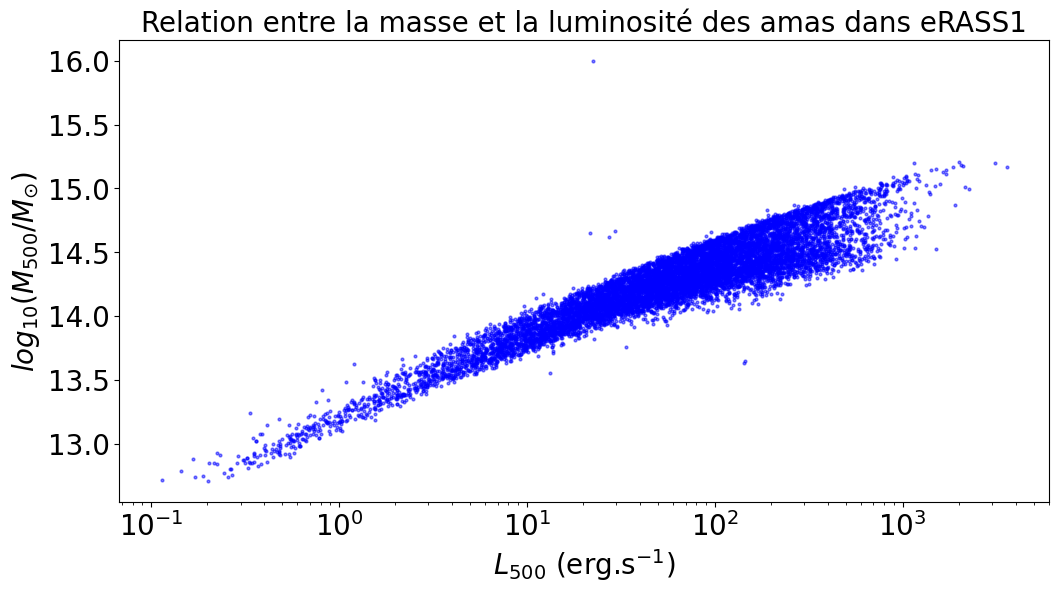

In [94]:
M500_eRASS1_2 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun # M500 masses in Msun


plt.figure(figsize=(12, 6))
plt.plot(L500_eRASS1, M500_eRASS1_2, 'o', markersize=2, alpha=0.5, color='blue')
plt.xscale('log')
plt.xlabel(r'$L_{500}$ (erg.s$^{-1}$)')
plt.ylabel(r'$log_{10}(M_{500}/M_{\odot}$)')
plt.title('Relation entre la masse et la luminosité des amas dans eRASS1')

Text(0.5, 1.0, 'Relation entre la masse et le Count-Rate des amas dans eRASS1')

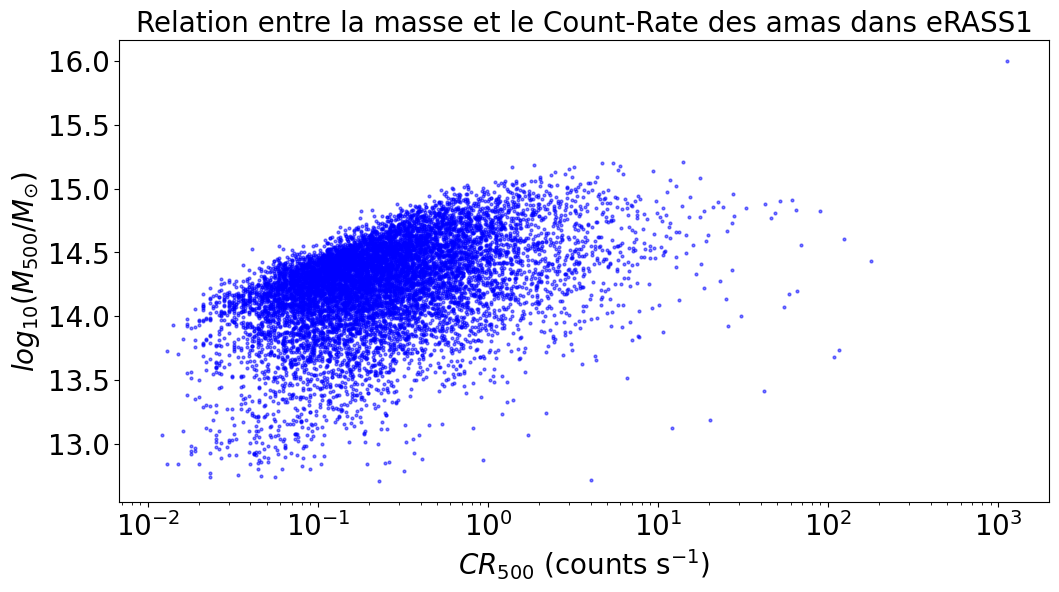

In [95]:
plt.figure(figsize=(12, 6))
plt.plot(CR500_eRASS1, M500_eRASS1_2, 'o', markersize=2, alpha=0.5, color='blue')
plt.xscale('log')
plt.xlabel(r'$CR_{500}$ (counts s$^{-1}$)')
plt.ylabel(r'$log_{10}(M_{500}/M_{\odot}$)')
plt.title('Relation entre la masse et le Count-Rate des amas dans eRASS1')

### Tentative calcul CLxF théorique pour eROSITA 
(section temporaire)

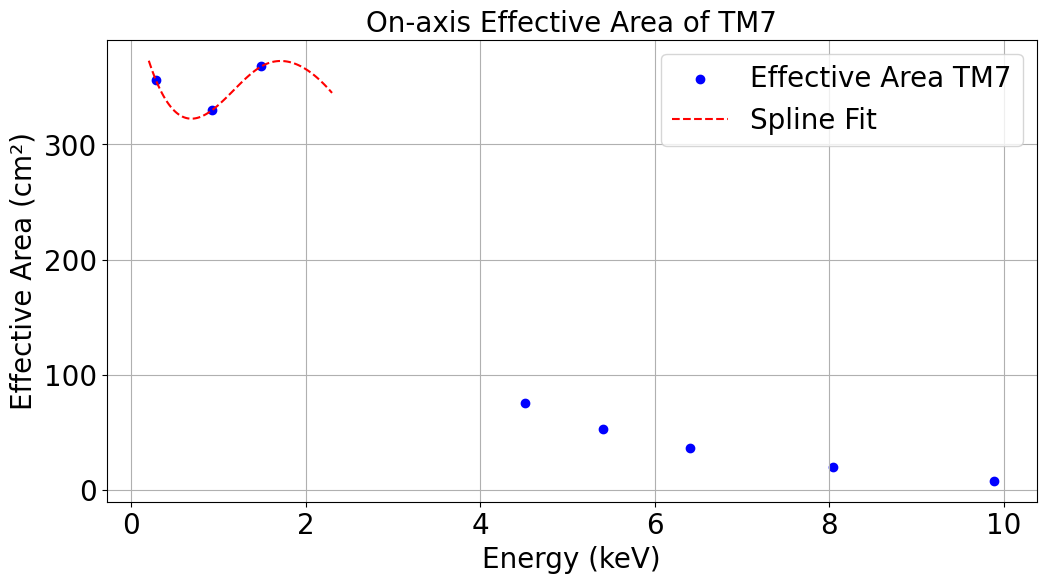

mean_eff_area_2 =  2451.0854099755675 cm²


In [96]:
# On-axis effective area of TM7 with 3σ errors (Table 5. Predehl et al. 2021)
energy_kev = [0.28,0.93,1.49,4.51,5.41,6.40,8.04,9.89]
eff_area_cm2 = [356.2,330.1, 367.9, 75.3, 52.8, 36.1, 19.41, 7.71]
func_eff_area = UnivariateSpline(energy_kev,eff_area_cm2,s=1e-3)
range_kev = np.linspace(0.2,2.3,100) # range of kev for values of Lx and CR studied in Bulbul et al. 2024
estimation_eff_area = func_eff_area(range_kev)

plt.figure(figsize=(12, 6))
plt.scatter(energy_kev, eff_area_cm2, color='blue', label='Effective Area TM7')
plt.plot(range_kev, estimation_eff_area, color='red', linestyle='--', label='Spline Fit')
plt.xlabel('Energy (keV)')
plt.ylabel('Effective Area (cm²)')
plt.title('On-axis Effective Area of TM7')
plt.legend()
plt.grid()
plt.show()

# Mean effective area over the range 0.2-2.3 keV
mean_eff_area = 7*(integrate.quad(func_eff_area, 0.2, 2.3)[0] / (2.3 - 0.2)) # On multiplie par 7 parce qu'il y a 7 capteurs  
print('mean_eff_area_2 = ',mean_eff_area, "cm²")

In [97]:
mean_KT = table_eRASS1['KT'].mean() #Température X moynenne des amas (en kev)
print('mean_KT =',mean_KT,'kev')
E_peak = np.round(2.821 * mean_KT, 3) # Loi de Wien : position du pic d'énergie maximale : on va considérer que c'est l'énergie de chaque photon détecté dans un premier temps (kev)
print('E_peak = ', E_peak, 'keV')

mean_KT = 0.5740034294112845 kev
E_peak =  1.619 keV


In [98]:
z_test = 0.1
print(cosmo.efunc(z_test))

1.0502392169622146


In [99]:
print(cosmo.H(z_test)/cosmo.H0)

1.0502392169622146


In [100]:
table_eRASS1

,_Glon,_Glat,_RAJ2000,_DEJ2000,Name,RAJ2000,DEJ2000,Exp,zBest,CR500,...,F500,L500,KT,Mgas500,YX500,M500,Fgas500,R500,z_bin,L500_app
0,342.749444,-74.271282,0.021730,-38.624903,1eRASS J000005.2-383729,0.021730,-38.624903,94.8,0.3153,0.509,...,47.110,140.172,1.90,279.16,553.19,36.07,0.075,971,1,4.866512e-15
1,304.840929,-34.106230,0.089191,-82.831715,1eRASS J000021.4-824954,0.089191,-82.831715,184.2,0.0891,1.029,...,98.355,24.747,0.00,111.92,0.00,16.99,0.065,819,0,1.397003e-14
2,322.452374,-65.003240,0.129422,-50.151013,1eRASS J000031.0-500903,0.129422,-50.151013,117.3,0.0681,0.258,...,23.991,2.862,1.79,1.92,9.34,3.63,0.009,493,0,2.846192e-15
3,312.522359,-53.144799,0.132712,-63.025286,1eRASS J000031.8-630131,0.132712,-63.025286,139.6,0.2448,0.356,...,33.228,57.877,0.00,171.95,0.00,22.04,0.076,846,1,3.585786e-15
4,327.067385,-68.286558,0.189080,-46.394874,1eRASS J000045.3-462341,0.189080,-46.394874,109.5,0.0925,0.190,...,16.818,3.996,0.96,6.40,11.17,3.78,0.019,495,0,2.083485e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12242,314.228004,-55.350261,359.741833,-60.612333,1eRASS J235858.0-603644,359.741833,-60.612333,142.5,0.1052,3.556,...,337.065,97.721,0.00,358.95,0.00,38.67,0.093,1071,0,3.873348e-14
12243,317.972764,-60.279761,359.799123,-55.296727,1eRASS J235911.7-551748,359.799123,-55.296727,130.8,0.2137,0.121,...,11.402,15.028,0.00,5.59,0.00,8.15,0.008,614,1,1.264587e-15
12244,357.004155,-76.739217,359.864701,-34.306012,1eRASS J235927.5-341821,359.864701,-34.306012,87.5,0.1138,0.713,...,62.778,22.350,0.00,81.23,0.00,14.11,0.054,763,0,7.485868e-15
12245,330.823687,-70.028240,359.980381,-44.205215,1eRASS J235955.2-441218,359.980381,-44.205215,98.1,0.5797,0.136,...,12.342,165.113,0.00,41.31,0.00,25.92,0.020,785,2,1.357368e-15
